# Small molecules

**What you'll learn.** The numbered tutorials introduce one idea at a time on a
handful of entities. This notebook is the small-molecule *deep dive*: every
runnable molecule model in embpy, compared with every metric embpy ships, and
then held against the public clinical record for the same 40 compounds.

Molecules are the modality where the two kinds of representation are furthest
apart, and where the gap is easiest to state precisely:

* **Structural fingerprints** are hand-specified bit vectors. A Morgan bit fires
  when a particular circular atom environment is present. Nothing about the
  vector was learned, and nothing in it knows what the molecule *does*.
* **Learned representations** are transformers trained on SMILES strings. They
  saw hundreds of millions of molecules and no pharmacology, so they know more
  chemistry than a bit vector and still nothing about mechanism.

Neither family was ever told what a drug is for. The public record was, and
comparing the two is the point of the second half.

It answers four questions in order:

| Section | Question |
| --- | --- |
| [Embed](#embed-every-molecule-model) | which molecule models exist, and what do they cost? |
| [Compare](#1-global-geometry) | do they encode the same structure? |
| [Interpret](#does-the-geometry-track-biology) | does that structure track the mechanism labels? |
| [Annotate](#the-clinical-record) | what does the public record say, and does any embedding recover it? |

Prerequisites: [Comparing embeddings](03_compare_embeddings.ipynb) for the metric
definitions and [Benchmarking models](04_benchmark_models.ipynb) for the
downstream protocol. Both are used here without re-deriving. There is no
attention section: the flag exists on the molecule transformers, the
[catalogue](#which-molecule-models-does-embpy-have) says why it is not used, and
residue-level reading belongs to [proteins](proteins.ipynb) and
[genes](genes.ipynb).

In [1]:
import json
import time
import warnings
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

import embpy
from embpy import BioEmbedder, pl, tl

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

# The notebook is executed from docs/notebooks, so a relative path keeps the
# artifact next to the sibling notebooks' outputs rather than in the repo root.
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# MoLFormer loads custom remote code and reports newly initialised head weights
# that mean pooling never touches. ChemBERTa already quiets transformers around
# its own from_pretrained call, MoLFormer does not, so the global switch is what
# keeps the sweep output in the next part readable.
from transformers import logging as hf_logging

hf_logging.set_verbosity_error()

# No organism argument. A molecule has no species, and the constructor's default
# only configures the gene and protein resolvers, which this notebook never uses.
embedder = BioEmbedder(device="auto")

print(f"embpy {embpy.__version__} on device {embedder.device}")

embpy 0.1.dev268+g5badd093f.d20260812 on device mps


## A panel where structure and mechanism disagree

Comparison metrics need enough entities to be meaningful, and interpretation
needs *labels that are not derived from the embeddings*. So the panel is 40
approved or once-approved drugs in five mechanism classes of eight -- a grouping
from pharmacology, not from any model.

A panel every model handles identically measures nothing. What makes this one
useful is that **structural similarity and mechanism similarity disagree across
it, and disagree by design**:

| Family | What it is | Prior expectation |
| --- | --- | --- |
| `statin` | HMG-CoA reductase inhibitors | easy: a congeneric series, though it splits into a fungal decalin subgroup (lovastatin, simvastatin, mevastatin, pravastatin) and a synthetic heptenoic-acid subgroup (atorvastatin, rosuvastatin, fluvastatin, pitavastatin) |
| `benzodiazepine` | GABA-A positive allosteric modulators | easiest: all eight are built on one 1,4-benzodiazepine ring, so any fingerprint should recover the family almost perfectly |
| `beta_blocker` | beta-adrenergic antagonists | mostly easy: six are aryloxypropanolamines, but labetalol is an arylethanolamine and carvedilol carries a carbazole, so both should sit further out |
| `kinase_inhibitor` | ATP-competitive protein kinase inhibitors | hard: one target family, unrelated scaffolds -- imatinib's phenylaminopyrimidine, sorafenib's diaryl urea, sunitinib's oxindole |
| `nsaid` | cyclooxygenase inhibitors | hardest: one mechanism spanning salicylate (aspirin), propionic acid (ibuprofen, naproxen), acetic acid (diclofenac, indomethacin), coxib (celecoxib, rofecoxib) and oxicam (meloxicam) chemistry |

The prediction that falls out of the table is specific enough to be wrong: a
structural method should rank the families roughly `benzodiazepine` >= `statin`
>= `beta_blocker` > `kinase_inhibitor` > `nsaid` on label purity, and a learned
representation has room to close some of that gap. If a fingerprint *cannot*
recover the benzodiazepines, that is a red flag about the model rather than
about the panel. That is a prediction, and the
[interpretation section](#does-the-geometry-track-biology) scores it rather than
assuming it.

In [2]:
PANEL: dict[str, list[str]] = {
    # tight congeneric series: shared scaffold as well as shared mechanism
    "statin": ["atorvastatin", "simvastatin", "lovastatin", "pravastatin",
               "rosuvastatin", "fluvastatin", "pitavastatin", "mevastatin"],
    "benzodiazepine": ["diazepam", "lorazepam", "alprazolam", "clonazepam",
                       "midazolam", "temazepam", "oxazepam", "chlordiazepoxide"],
    "beta_blocker": ["propranolol", "atenolol", "metoprolol", "bisoprolol",
                     "carvedilol", "nadolol", "timolol", "labetalol"],
    # mechanism-coherent, structurally diverse: shared target class only
    "kinase_inhibitor": ["imatinib", "dasatinib", "nilotinib", "erlotinib",
                         "gefitinib", "sorafenib", "sunitinib", "lapatinib"],
    "nsaid": ["aspirin", "ibuprofen", "naproxen", "diclofenac", "celecoxib",
              "rofecoxib", "indomethacin", "meloxicam"],
}

COMPOUNDS = [name for members in PANEL.values() for name in members]
FAMILY = {name: fam for fam, members in PANEL.items() for name in members}

# The categorical is ordered, and ordered in PANEL order rather than
# alphabetically, so every later table and legend reads easy families first and
# hard families last without re-sorting at each call site.
mol_space = ad.AnnData(
    X=np.zeros((len(COMPOUNDS), 1), dtype=np.float32),
    obs=pd.DataFrame(
        {
            "compound": COMPOUNDS,
            "family": pd.Categorical(
                [FAMILY[name] for name in COMPOUNDS],
                categories=list(PANEL), ordered=True,
            ),
        },
        index=pd.Index(COMPOUNDS, name="compound"),
    ),
    var=pd.DataFrame(index=["placeholder"]),
)

# A repeated name would silently shrink the panel and quietly bias every purity
# score, so the count is printed rather than assumed.
print(f"{mol_space.n_obs} compounds in {len(PANEL)} families")
print(f"unique names: {len(set(COMPOUNDS))}/{len(COMPOUNDS)}")
print(mol_space.obs["family"].value_counts().sort_index().to_string())

40 compounds in 5 families
unique names: 40/40
family
statin              8
benzodiazepine      8
beta_blocker        8
kinase_inhibitor    8
nsaid               8


### Two compounds are in the panel for what they will expose later

Most of the 40 are here to fill out a family. Two are here for a specific reason,
and it is worth naming them now so their appearance later is not a surprise.

* **rofecoxib** is withdrawn. It was pulled worldwide in 2004 over
  cardiovascular risk, and it is the compound that makes
  [the safety record](#the-safety-record) show something rather than print eight
  rows of `None`. It also pairs with celecoxib -- same COX-2 mechanism,
  different scaffold -- for the
  [scaffold-hopping test](#molecule-only-scaffold-hopping).
* **imatinib** is the compound whose mechanism of action embpy used to report as
  empty. ChEMBL registers drug-level rows against the *parent* molecule, so a
  query filtered on `molecule_chembl_id` returns nothing for a drug curated
  against a salt.
  [Mechanism, and the parent-molecule trap](#mechanism-and-the-parent-molecule-trap)
  shows the count both ways.

> **Structural, not causal.** Every distance in this notebook is a distance
> between representations of a structure. A model putting two compounds close
> together is a statement about their SMILES strings, not evidence that they
> share a target, a dose, or a safety profile. The annotation sections exist
> precisely because that inference does not come for free.

## Which molecule models does embpy have?

`model_catalog` is the inventory. Molecules are served by one family, and unlike
DNA there are few enough keys to print the whole thing.

In [3]:
molecule_catalog = embedder.model_catalog("molecule")
print(f"molecule keys: {len(molecule_catalog)}")
display(molecule_catalog)

molecule keys: 14


,model,family
0,atom_pair_count_fp,molecule
1,atom_pair_fp,molecule
2,chemberta2MLM,molecule
3,chemberta2MTR,molecule
4,maccs_fp,molecule
5,mhg_gnn,molecule
6,minimol,molecule
7,mole,molecule
8,molformer_base,molecule
9,morgan_count_fp,molecule


Fourteen keys overstates the choice in two different ways, and they need separating
before anything is embedded.

Eight of the fourteen are `RDKitWrapper` in different clothes: the registry maps
the key to a `fingerprint_type` string and the wrapper dispatches on it, so
`morgan_fp` and `morgan_count_fp` are one algorithm read two ways. Three of the
remaining six need a backend that is not installed here. That leaves nine keys
worth running: five fingerprint algorithms and two transformer architectures,
plus one binary-versus-count contrast and one pre-training contrast.

| Key | Wrapper | Width | Why it earns a slot |
| --- | --- | --- | --- |
| `maccs_fp` | `RDKitWrapper` | 167 | 166 hand-written substructure keys -- the only space here a chemist can read bit by bit |
| `morgan_fp` | `RDKitWrapper` | 2048 | ECFP4 bits, what a cheminformatics baseline means by "fingerprint" |
| `morgan_count_fp` | `RDKitWrapper` | 2048 | the same bits weighted by how often each environment occurs |
| `rdkit_fp` | `RDKitWrapper` | 2048 | hashed topological paths, a Daylight-style alternative to circular environments |
| `atom_pair_fp` | `RDKitWrapper` | 2048 | atom pairs with their topological distance -- a global descriptor rather than a local one |
| `torsion_fp` | `RDKitWrapper` | 2048 | four-atom torsions; registry key `torsion_fp`, internal type `topological_torsion` |
| `chemberta2MTR` | `ChembertaWrapper` | 384 | RoBERTa over SMILES, pre-trained with multi-task regression on computed properties |
| `chemberta2MLM` | `ChembertaWrapper` | 384 | same architecture and tokeniser, masked-language pre-training only -- the supervision contrast |
| `molformer_base` | `MolformerWrapper` | 768 | linear-attention transformer from a different group and corpus, loaded with `trust_remote_code=True` |

The widths for the three transformers are what the checkpoints declare. The
[sweep](#embed-every-molecule-model) reports the width it actually got, which is
the only number worth trusting.

Skipped on purpose: `atom_pair_count_fp` and `torsion_count_fp`, because the
binary-versus-count contrast is made once with Morgan and two more pairs add cost
rather than insight; `minimol`, because it needs `embpy[minimol]`, whose
`torch-sparse` and `torch-scatter` wheels only build with torch already present;
`mhg_gnn`, because it installs from a git URL and has no `pyproject` extra;
`mole`, because the pre-trained weights have never been released publicly.

`get_model(..., load=False)` reads a wrapper's declared capabilities without
downloading weights, which is how the table below can mention all twelve keys
cheaply.

In [4]:
ROSTER = ["maccs_fp", "morgan_fp", "morgan_count_fp", "rdkit_fp", "atom_pair_fp",
          "torsion_fp", "chemberta2MTR", "chemberta2MLM", "molformer_base"]

rows = []
for key in ROSTER + ["minimol", "mhg_gnn", "mole"]:
    try:
        w = embedder.get_model(key, load=False)
        rows.append({"model": key, "wrapper": type(w).__name__,
                     "has_attention": w.has_attention, "status": "available"})
    except Exception as exc:
        rows.append({"model": key, "wrapper": "-", "has_attention": None,
                     "status": f"{type(exc).__name__}"})

display(pd.DataFrame(rows).set_index("model"))

,wrapper,has_attention,status
model,,,
maccs_fp,RDKitWrapper,False,available
morgan_fp,RDKitWrapper,False,available
morgan_count_fp,RDKitWrapper,False,available
rdkit_fp,RDKitWrapper,False,available
atom_pair_fp,RDKitWrapper,False,available
torsion_fp,RDKitWrapper,False,available
chemberta2MTR,ChembertaWrapper,True,available
chemberta2MLM,ChembertaWrapper,True,available
molformer_base,MolformerWrapper,True,available


### Available, but not runnable

Read that table carefully, because it is more optimistic than the truth. All
twelve keys report `available`, including the three the roster excludes.

`load=False` constructs the wrapper and stops. Every molecule wrapper defers its
backend import to `load()`, so construction cannot fail for a missing dependency
and `available` here means *the class exists and the registry knows the key*. It
is not a claim that the model runs. The `status` column earns its name only when
something is actually loaded, which is what the next cell does.

The `has_attention` column needs the same care. `False` on the six fingerprints
is **declared**: a Morgan bit vector is hand-computed, so there is nothing to
attend with. `True` on ChemBERTa, MoLFormer and MolE is **inherited** -- the
default is `has_attention: bool = True` at `src/embpy/models/base.py:88`, and none
of the three molecule transformers overrides it. That makes the flag a statement
about the base class rather than a verified capability, which is one reason this
notebook reports it and never calls `extract_attention` on a molecule model.

In [5]:
# Loading the three excluded keys is cheap and safe: each fails at its backend
# import, before any weight download, so this cell measures the failure mode
# rather than the model. The typed error is the point -- DependencyError names an
# install line, ModelLoadError means the backend was found and still refused.
from embpy.errors import DependencyError, ModelLoadError

loaded_anyway = []
for key in ["minimol", "mhg_gnn", "mole"]:
    try:
        embedder.get_model(key, load=True)
        loaded_anyway.append(key)
        print(f"{key:10s} loads on this machine -- the backend is installed here")
    except (DependencyError, ModelLoadError) as exc:
        detail = str(exc).splitlines()[0]
        pkg = getattr(exc, "package", None)
        print(f"{key:10s} {type(exc).__name__}(package={pkg!r})")
        print(f"{'':10s}   {detail}")
    except Exception as exc:      # anything else is a genuine surprise, so name it
        print(f"{key:10s} unexpected {type(exc).__name__}: {exc}")

# A key that did load is now cached, and the sweep should embed the roster and
# nothing else, so the cache goes back to empty before part two touches it.
if loaded_anyway:
    print(f"clearing {len(loaded_anyway)} wrapper(s) loaded only to test the "
          f"failure mode")
    embedder.clear_model_cache(which="other")

ERROR:root:Failed to load model 'minimol': missing dependency 'embpy[minimol]'.


ERROR:root:Failed to load model 'mhg_gnn': missing dependency 'unknown'.


ERROR:root:Failed to load model 'mole': missing dependency 'unknown'.


minimol    DependencyError(package='embpy[minimol]')
             'embpy[minimol]' is required for model 'minimol' but not installed. Install with: pip install embpy[minimol]
mhg_gnn    DependencyError(package='unknown')
             'unknown' is required for model 'mhg_gnn' but not installed. Install with: pip install unknown
mole       DependencyError(package='unknown')
             'unknown' is required for model 'mole' but not installed. Install with: pip install unknown


Two of those three are ordinary missing dependencies, and the messages say what to
install. `mhg_gnn` is the noisier one: it has no entry in `WRAPPER_EXTRAS`, so
embpy cannot name an extra and falls back to `DependencyError(package="unknown")`
-- honest, but not advice you can paste into a shell.

`mole` is the interesting case, because installing the backend would not help.
`_get_model` constructs `MolEWrapper(model_path_or_name="mole")` and passes no
`checkpoint_path`, and `MolEWrapper.load` raises
`ValueError("MolE requires a pretrained checkpoint path")` at
`src/embpy/models/molecule_models.py:943` when that argument is `None`. There is
no way to supply it through `BioEmbedder`. On this machine the import fails first,
so the printed error names the missing package rather than the missing checkpoint,
but both roads end in the same place.

> **Listed is not runnable.** `mole` appears in
> `list_available_models("molecule")` and in `model_catalog("molecule")`, and
> cannot be embedded with anything embpy exposes. A catalogue that quietly
> included it in a "9 of 14 models" count would be flattering itself; the roster
> above is nine because nine is what runs.

In [6]:
# The fingerprint geometry is knowable without loading anything, and two claims
# in the roster table are worth checking rather than repeating: that MACCS is
# 167 wide whatever n_bits says, and that the Morgan radius is fixed at 2 because
# the registry passes no radius at all.
fp_rows = []
for key in ROSTER[:6]:
    w = embedder.get_model(key, load=False)
    fp_rows.append({
        "model": key,
        "fingerprint_type": w.fingerprint_type,
        "width": w.n_bits,
        "radius": w.radius,
        "values": "binary bits" if w.is_binary_fingerprint else "integer counts",
        "pooling": ", ".join(w.available_pooling_strategies),
    })

fingerprints = pd.DataFrame(fp_rows).set_index("model")
display(fingerprints.round(3))

,fingerprint_type,width,radius,values,pooling
model,,,,,
maccs_fp,maccs,167,2,binary bits,flat
morgan_fp,morgan,2048,2,binary bits,flat
morgan_count_fp,morgan_count,2048,2,integer counts,flat
rdkit_fp,rdkit,2048,2,binary bits,flat
atom_pair_fp,atom_pair,2048,2,binary bits,flat
torsion_fp,topological_torsion,2048,2,binary bits,flat


Three things in that table shape the rest of the notebook.

**`radius` is 2 everywhere, and means something in exactly two rows.** It is a
constructor default the registry never overrides, and `_compute_fingerprint`
only reads it in the two Morgan branches. MACCS, RDKit, atom-pair and torsion
fingerprints ignore it, and MACCS ignores `n_bits` too -- its 167 slots are 166
hand-curated keys plus an unused bit 0.

**`pooling` is `flat` and the value is inert.** `RDKitWrapper.embed` accepts a
`pooling_strategy` argument and never looks at it. Passing one is legal and
changes nothing, which is worth knowing before you spend an afternoon tuning it.

**The widths do not match.** 167, 2048, 384 and 768 in one comparison is not a
detail to smooth over: most similarity measures are sensitive to dimensionality,
and a naive one would rank `maccs_fp` differently for having 167 columns rather
than for encoding anything differently. [Global geometry](#1-global-geometry)
handles that explicitly, and says which of its four metrics is dimension-agnostic
and which is not.

Nothing has been embedded yet, and nothing can be until the 40 names become
structures. That is the next part's job, and it starts by measuring the
resolution rather than trusting it.

## Resolve the compounds, and measure them before trusting anything

The panel is forty *names*. Every model in this notebook consumes a SMILES
string, so something has to turn "atorvastatin" into a structure -- and that
step is where a molecule notebook quietly goes wrong. A name that resolves to
the wrong tautomer, a salt where you expected the free base, or a compound that
silently fails to resolve at all will all produce a plausible embedding matrix
with a plausible shape.

So resolve first, record where each answer came from, and measure the results
before any of them reaches a model.

In [7]:
from embpy.resources import DrugResolver

resolver = DrugResolver(use_rdkit=True, sleep_sec=0.1)

# name_to_smiles_resolved rather than name_to_smiles: the DrugResolution it
# returns records WHICH service answered, and that is the difference between a
# reproducible panel and forty strings of unknown provenance.
rows = []
for name in COMPOUNDS:
    res = resolver.name_to_smiles_resolved(name)
    rows.append({
        "compound": name,
        "family": FAMILY[name],
        "smiles": res.smiles,
        "source": res.source or "unresolved",
    })

RESOLUTION = pd.DataFrame(rows).set_index("compound")
n_resolved = int(RESOLUTION["smiles"].notna().sum())
print(f"resolved {n_resolved}/{len(COMPOUNDS)} compounds")
display(RESOLUTION.groupby("source").size().to_frame("n_compounds"))

resolved 40/40 compounds


,n_compounds
source,
pubchem_name,40


`source` is worth reading rather than skipping. `pubchem_name` means the name
matched directly; `pubchem_cid` means it took a second lookup; `cactus` means
PubChem did not know the name at all and the NCI resolver did. A panel answered
entirely by one service is easier to reproduce than one stitched from three.

In [8]:
# Fail loudly here rather than embedding a shorter panel than the one described
# in the section above. A missing compound changes every per-family number
# downstream, and a 39-compound "family of eight" is not a thing.
unresolved = RESOLUTION.index[RESOLUTION["smiles"].isna()].tolist()
if unresolved:
    print(f"UNRESOLVED ({len(unresolved)}): {unresolved}")
    print("Re-run when the resolver services are reachable; the rest of the "
          "notebook assumes all forty.")
else:
    print("all forty compounds resolved")

all forty compounds resolved


### Canonical is the identity, and it is not the string you were given

embpy keys molecules by canonical SMILES, and canonicalisation is not cosmetic:
it strips isotope labels, normalises, removes salts and solvents, keeps the
largest fragment and neutralises charges. Two panels that name the same drug
differently land on the same row only after that pass.

Because the identity is the canonical string, the AnnData is re-indexed by it
below. This is the single most breakable step in the notebook: `embed()`
resolves the SMILES you give it to canonical form and then re-indexes the result
against `obs_names`, so if `obs_names` held compound *names* the join would
match nothing and every row would come back NaN.

In [9]:
canonical = [resolver.canonicalize_smiles(s) for s in RESOLUTION["smiles"]]
changed = sum(1 for raw, can in zip(RESOLUTION["smiles"], canonical) if raw != can)
print(f"canonicalisation rewrote {changed}/{len(canonical)} strings")

# One row per distinct molecule. A duplicate here would mean two panel names
# that are the same compound, which would break the family design.
assert len(set(canonical)) == len(canonical), "duplicate molecule in the panel"

mol_space.obs["smiles"] = canonical
mol_space.obs_names = pd.Index(canonical, name="canonical_smiles")

display(pd.DataFrame({
    "compound": mol_space.obs["compound"].values,
    "canonical_smiles": [s[:52] + ("..." if len(s) > 52 else "") for s in canonical],
}).head(6))

canonicalisation rewrote 0/40 strings


,compound,canonical_smiles
0,atorvastatin,CC(C)c1c(C(=O)Nc2ccccc2)c(-c2ccccc2)c(-c2ccc(F...
1,simvastatin,CCC(C)(C)C(=O)O[C@H]1C[C@@H](C)C=C2C=C[C@H](C)...
2,lovastatin,CC[C@H](C)C(=O)O[C@H]1C[C@@H](C)C=C2C=C[C@H](C...
3,pravastatin,CC[C@H](C)C(=O)O[C@H]1C[C@H](O)C=C2C=C[C@H](C)...
4,rosuvastatin,CC(C)c1nc(N(C)S(C)(=O)=O)nc(-c2ccc(F)cc2)c1/C=...
5,fluvastatin,CC(C)n1c(/C=C/[C@H](O)C[C@H](O)CC(=O)O)c(-c2cc...


### What the panel actually looks like, physically

Before comparing models, know the range they have to cover. A panel where every
compound has the same mass and the same ring count cannot separate models, and
one with a 10x spread in heavy-atom count will stress the transformers'
context windows.

In [10]:
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors

phys = []
for name, smi in zip(mol_space.obs["compound"], mol_space.obs["smiles"]):
    mol = Chem.MolFromSmiles(smi)
    phys.append({
        "compound": name,
        "family": FAMILY[name],
        "mw": Descriptors.MolWt(mol),
        "heavy_atoms": mol.GetNumHeavyAtoms(),
        "rings": rdMolDescriptors.CalcNumRings(mol),
        "rotatable": rdMolDescriptors.CalcNumRotatableBonds(mol),
        "smiles_chars": len(smi),
    })
PHYS = pd.DataFrame(phys).set_index("compound")

display(PHYS.groupby("family")[
    ["mw", "heavy_atoms", "rings", "rotatable", "smiles_chars"]
].mean().round(1))

,mw,heavy_atoms,rings,rotatable,smiles_chars
family,,,,,
benzodiazepine,305.4,21.2,3.2,1.1,37.1
beta_blocker,309.9,22.1,1.9,8.0,34.8
kinase_inhibitor,474.5,33.8,4.0,7.6,56.5
nsaid,289.7,20.0,2.2,3.1,36.2
statin,438.9,31.5,3.0,8.2,77.9


The families are physically distinguishable before any model runs, which is the
point: a fingerprint that fails to separate them is not being defeated by a
subtle panel.

### The tokeniser audit, or how a compound disappears

`ChembertaWrapper.embed_batch` **skips** any SMILES longer than its `max_len`
and returns `None` in that slot, which `_aligned_matrix` then drops -- so a
compound that is too long vanishes from the matrix without raising anything.
That is the molecule analogue of a protein exceeding an ESM window, and it is
worth measuring *before* the sweep rather than discovering it as a shape
mismatch afterwards.

The two ChemBERTa checkpoints tokenise differently, so the same molecule has two
different lengths. Measure both.

In [11]:
TOKEN_LIMIT = 512      # ChembertaWrapper clamps max_position_embeddings to this

tok_rows = []
for key in ("chemberta2MTR", "chemberta2MLM"):
    try:
        w = embedder.get_model(key)
    except Exception as exc:
        print(f"{key}: unavailable ({type(exc).__name__})")
        continue
    lengths = [len(w.tokenizer.tokenize(s)) for s in mol_space.obs["smiles"]]
    tok_rows.append({
        "model": key,
        "min_tokens": int(np.min(lengths)),
        "median_tokens": float(np.median(lengths)),
        "max_tokens": int(np.max(lengths)),
        "limit": TOKEN_LIMIT,
        "would_be_dropped": int(np.sum(np.array(lengths) > TOKEN_LIMIT)),
    })

TOKENS = pd.DataFrame(tok_rows).set_index("model")
display(TOKENS)

,min_tokens,median_tokens,max_tokens,limit,would_be_dropped
model,,,,,
chemberta2MTR,21,41.0,71,512,0
chemberta2MLM,13,27.5,75,512,0


Nothing is near the limit -- drug-like molecules tokenise to tens of characters,
not hundreds -- so no compound is dropped here. That is the answer for *this*
panel, and it is only knowable because it was measured. A peptide-like or
polymeric input would give a different one, and `would_be_dropped` is the
column that would tell you.

Note the gap between the two checkpoints' token counts. They are both called
ChemBERTa and they cut a SMILES string differently; the
[attention section](#reading-chembertas-attention) returns to that.

## Embed every molecule model

One `embed` call per model, same call shape every time, one `.obsm` key each.
The only thing that varies is `model=`.

Three practical points:

* **`missing="nan"`, not the default.** A model that fails on one compound
  should cost you that row, not the whole sweep. The NaN rows are then counted
  rather than ignored -- see [two views](#one-molecule-space-two-views).
* **Every failure is caught and reported.** `molformer_base` is in the registry
  and cannot load in this environment; the sweep records that rather than
  dying on it.
* **`SWEEP` is derived from what worked**, never from the roster. Everything
  downstream iterates `SWEEP`.

In [12]:
import time

SWEEP = []
TIMINGS = []
FAILED = {}

for key in ROSTER:
    t0 = time.time()
    try:
        mol_space = embedder.embed(
            mol_space,
            entity_type="molecule",
            id_type="smiles",
            obs_column="smiles",
            model=key,
            output="anndata",
            attach_to="obs",
            key=f"X_{key}",
            missing="nan",       # one bad compound must not cost the sweep
        )
        matrix = np.asarray(mol_space.obsm[f"X_{key}"], dtype=float)
        n_ok = int(np.isfinite(matrix).all(axis=1).sum())
        SWEEP.append(key)
        TIMINGS.append({
            "model": key,
            "dim": matrix.shape[1],
            "rows_filled": n_ok,
            "seconds": round(time.time() - t0, 1),
        })
    except Exception as exc:
        FAILED[key] = f"{type(exc).__name__}: {str(exc)[:90]}"
        embedder.clear_model_cache()

TIMINGS = pd.DataFrame(TIMINGS).set_index("model")
display(TIMINGS)
for key, err in FAILED.items():
    print(f"skipped {key}: {err}")

ERROR:root:MolFormer load error: No module named 'transformers.masking_utils'


ERROR:root:Failed to load model 'molformer_base' using wrapper MolformerWrapper and path 'ibm/MoLFormer-XL-both-10pct': Could not load MolFormer 'ibm/MoLFormer-XL-both-10pct'


,dim,rows_filled,seconds
model,,,
maccs_fp,167,40,0.5
morgan_fp,2048,40,0.4
morgan_count_fp,2048,40,0.3
rdkit_fp,2048,40,0.5
atom_pair_fp,2048,40,0.3
torsion_fp,2048,40,0.3
chemberta2MTR,384,40,0.8
chemberta2MLM,768,40,1.1


skipped molformer_base: ModelLoadError: Failed to load model 'molformer_base': RuntimeError: Could not load MolFormer 'ibm/MoLForm


### Why MoLFormer is not in the sweep

`molformer_base` is listed by `list_available_models("molecule")` and it does
not load. The reason is two layers below the message you get, and it is a
dependency problem rather than a bug: MoLFormer ships its modelling code on the
Hub and is loaded with `trust_remote_code=True`, so it runs against whatever
`transformers` the environment happens to have. That code imports
`transformers.masking_utils`, which arrived in a later release than the one
pinned here for ESM compatibility.

`MolformerWrapper.load` catches the `ModuleNotFoundError` and raises
`RuntimeError("Could not load MolFormer ...")` at
`src/embpy/models/molecule_models.py:287`; `_get_model` then wraps that in
`ModelLoadError`. Both re-wraps keep `__cause__`, so the root cause is
recoverable -- if you know to walk the chain.

In [13]:
# Walk __cause__ rather than reading the top-level message, which names neither
# the missing module nor the version constraint.
try:
    embedder.get_model("molformer_base")
    print("molformer_base loaded in this environment after all")
except Exception as exc:
    depth, cursor = 0, exc
    while cursor is not None:
        print(f"{'  ' * depth}{type(cursor).__name__}: {str(cursor)[:78]}")
        cursor, depth = cursor.__cause__, depth + 1

ERROR:root:MolFormer load error: No module named 'transformers.masking_utils'


ERROR:root:Failed to load model 'molformer_base' using wrapper MolformerWrapper and path 'ibm/MoLFormer-XL-both-10pct': Could not load MolFormer 'ibm/MoLFormer-XL-both-10pct'


ModelLoadError: Failed to load model 'molformer_base': RuntimeError: Could not load MolFormer 
  RuntimeError: Could not load MolFormer 'ibm/MoLFormer-XL-both-10pct'
    ModuleNotFoundError: No module named 'transformers.masking_utils'


> **Remote code is a dependency your lockfile does not cover.** A model loaded
> with `trust_remote_code=True` pins nothing. It worked when it was added and
> stopped working when the environment moved, and no version constraint in this
> project mentions it.

### The fingerprints: bit vectors, several algorithms

Six of the spaces above are RDKit fingerprints. They are not learned: each is a
deterministic hash of substructures into a fixed-width bit vector, so they have
no training distribution to be out of, and no parameters to be wrong. That makes
them the right baseline, and it also bounds what they can do -- two molecules
with no shared substructure are simply far apart, however similar their biology.

`maccs_fp` is the odd one out: 167 bits of *curated* structural keys rather than
2048 bits of hashed neighbourhoods.

In [14]:
fp_rows = []
for key in SWEEP:
    matrix = np.asarray(mol_space.obsm[f"X_{key}"], dtype=float)
    finite = matrix[np.isfinite(matrix).all(axis=1)]
    fp_rows.append({
        "model": key,
        "dim": matrix.shape[1],
        # A fingerprint is binary or count-valued; a learned embedding is dense
        # and real-valued. This separates them without hardcoding a list.
        "distinct_values": int(min(len(np.unique(finite)), 999)),
        "mean_nonzero_per_row": round(float((finite != 0).sum(axis=1).mean()), 1),
        "occupancy": round(float((finite != 0).mean()), 3),
    })

display(pd.DataFrame(fp_rows).set_index("model"))

,dim,distinct_values,mean_nonzero_per_row,occupancy
model,,,,
maccs_fp,167,2,47.8,0.286
morgan_fp,2048,2,46.6,0.023
morgan_count_fp,2048,14,46.6,0.023
rdkit_fp,2048,2,781.1,0.381
atom_pair_fp,2048,2,247.7,0.121
torsion_fp,2048,2,43.1,0.021
chemberta2MTR,384,999,384.0,1.000
chemberta2MLM,768,999,768.0,1.000


`distinct_values` of 2 marks a binary fingerprint, a small integer count marks a
count fingerprint, and several hundred marks a learned representation. Read
`occupancy` alongside it: a 2048-bit vector with 40 bits set is 98% zeros, so
most of its dimensions carry no signal for this panel at all -- which is exactly
why the [effective width](#nominal-width-is-not-effective-width) discussion in
the next section matters.

### Binary or count: the same bits, weighted differently

`morgan_fp` and `morgan_count_fp` hash the same substructures into the same
2048 positions. The only difference is whether a repeated substructure sets a
bit once or increments a counter. If that changes the geometry, then how many
times a fragment appears carries information beyond whether it appears -- which
is a real, testable claim rather than a design preference.

In [15]:
if "morgan_fp" in SWEEP and "morgan_count_fp" in SWEEP:
    a = np.asarray(mol_space.obsm["X_morgan_fp"], dtype=float)
    b = np.asarray(mol_space.obsm["X_morgan_count_fp"], dtype=float)
    keep = np.isfinite(a).all(axis=1) & np.isfinite(b).all(axis=1)
    a, b = a[keep], b[keep]
    print(f"positions where the count exceeds 1: "
          f"{int((b > 1).sum())} of {int((b != 0).sum())} set positions")
    print(f"identical as bit patterns: {bool(np.array_equal(a != 0, b != 0))}")
    print(f"TSI(binary, count) = {tl.tsi(a, b):.3f}   (0.5 is the null)")
else:
    print("morgan pair unavailable; skipping the binary/count contrast")

positions where the count exceeds 1: 442 of 1864 set positions
identical as bit patterns: True
TSI(binary, count) = 0.772   (0.5 is the null)


The bit *patterns* are identical by construction -- the two only differ in the
weights on those positions -- so any TSI below 1.0 is entirely attributable to
counting. Whether that is worth a second 2048-dim space is what the
[purity ranking](#does-the-geometry-track-biology) decides.

## One molecule space, two views

`missing="nan"` means `mol_space` can carry rows that some models embedded and
others did not. That is honest but awkward: a metric computed over a NaN row is
NaN, and a metric silently computed over a *different subset* per model is
worse -- it compares models on different data and reports the difference as
model behaviour.

So the notebook keeps two objects, and every later section says which it used:

| Object | Rows | Use it for |
| --- | --- | --- |
| `mol_space` | all 40, NaN where a model failed | per-model coverage, annotation, saving |
| `dense_space` | only rows every model embedded | anything that compares models |

In [16]:
complete = np.ones(mol_space.n_obs, dtype=bool)
for key in SWEEP:
    matrix = np.asarray(mol_space.obsm[f"X_{key}"], dtype=float)
    # .all, not .any: a single non-finite cell breaks a metric, so the test is
    # the strict one.
    complete &= np.isfinite(matrix).all(axis=1)

dense_space = mol_space[complete].copy()

print(f"mol_space  : {mol_space.n_obs} compounds, {len(SWEEP)} spaces")
print(f"dense_space: {dense_space.n_obs} compounds "
      f"({int((~complete).sum())} dropped for incomplete coverage)")

if int((~complete).sum()):
    print("dropped:", list(mol_space.obs["compound"][~complete]))

display(dense_space.obs["family"].value_counts().to_frame("n_compounds"))

mol_space  : 40 compounds, 8 spaces
dense_space: 40 compounds (0 dropped for incomplete coverage)


,n_compounds
family,
statin,8
benzodiazepine,8
beta_blocker,8
kinase_inhibitor,8
nsaid,8


If `dense_space` still has all forty rows and eight balanced families, every
comparison below is over the same compounds for every model, and the family
sizes are equal -- which keeps the purity numbers in
[does the geometry track biology](#does-the-geometry-track-biology)
interpretable without reweighting.

## 1. Global geometry

Everything below runs on `dense_space` -- the gap-free subset from
[part 2](#one-molecule-space-two-views) -- because every metric here is a
distance computation, and a single NaN row does not cost you one cell of a
distance matrix, it costs that molecule's whole row and column of it.

The spaces fall into two families, and that split is the whole point of the
section:

* **fingerprints** -- six hand-written substructure enumerations. They see the
  molecular graph and nothing else. No training, no corpus, no objective.
* **learned representations** -- two ChemBERTa checkpoints and MoLFormer, all
  three trained on SMILES strings. They see a *tokenised text* of the molecule
  and whatever their pre-training objective rewarded.

So every pairwise number below belongs to one of three buckets: *within
fingerprint*, *within learned*, or *cross-family*. If the two families really do
encode different things, cross-family pairs should score **below both**
within-family blocks. That is a prediction, and the grouped table at the end of
this section is where it gets a number rather than an assertion.

One honest caveat before any of it. Four of the six fingerprints are the same
recipe with a different substructure enumerator: walk the graph, hash what you
find into 2048 buckets, set the bit. A high within-fingerprint block therefore
measures shared *hashing convention* at least as much as it measures shared
chemistry, and it is not evidence that fingerprints are right.

In [17]:
# Derived from dense_space.obsm and SWEEP rather than from a hand-written list, so
# a model that failed in part 2 simply never appears here.
usable, dropped_keys = [], {}
for key in SWEEP:
    obsm_key = f"X_{key}"
    if obsm_key not in dense_space.obsm:
        dropped_keys[key] = "no matrix on dense_space"
        continue
    matrix = np.asarray(dense_space.obsm[obsm_key], dtype=float)
    # alignment_matrix refuses non-finite input outright, so filter here where the
    # reason can be named instead of letting a metric cell raise on row 17.
    if not np.isfinite(matrix).all():
        dropped_keys[key] = "non-finite cells survived the dense mask"
        continue
    usable.append(key)

# Every RDKitWrapper entry in the registry is named with an "_fp" suffix and no
# learned key carries one, so the suffix is the family split. Checked against the
# registry rather than trusted, because the split decides every bucket below.
from embpy.embedder_registry.molecule import MOLECULE_MODELS
from embpy.models.molecule_models import RDKitWrapper

rdkit_keys = {k for k, (wrapper, _) in MOLECULE_MODELS.items()
              if wrapper is RDKitWrapper}
suffix_holds = all(k.endswith("_fp") for k in rdkit_keys) and not any(
    k.endswith("_fp") for k in set(MOLECULE_MODELS) - rdkit_keys
)
print(f"'_fp' suffix identifies the RDKit fingerprints exactly: {suffix_holds}")

FINGERPRINT_KEYS = [k for k in usable if k.endswith("_fp")]
LEARNED_KEYS = [k for k in usable if not k.endswith("_fp")]
MODEL_FAMILY = {**{k: "fingerprint" for k in FINGERPRINT_KEYS},
                **{k: "learned" for k in LEARNED_KEYS}}

# Order fingerprints first everywhere, so block structure -- if there is any --
# lands on the diagonal instead of being interleaved away.
ORDERED_KEYS = FINGERPRINT_KEYS + LEARNED_KEYS
ORDERED_OBSM = [f"X_{k}" for k in ORDERED_KEYS]
dense_matrices = {k: np.asarray(dense_space.obsm[f"X_{k}"], dtype=float)
                  for k in ORDERED_KEYS}

print(f"{dense_space.n_obs} molecules x {len(ORDERED_KEYS)} spaces, all gap-free")
print(f"fingerprints : {FINGERPRINT_KEYS}")
print(f"learned      : {LEARNED_KEYS}")
for key, why in dropped_keys.items():
    print(f"excluded     : {key} -- {why}")
if len(ORDERED_KEYS) < 2:
    print("\nWARNING: fewer than two usable spaces. Every pairwise cell below "
          "reports an empty table and continues; part 2's sweep table is where "
          "the reason lives.")

'_fp' suffix identifies the RDKit fingerprints exactly: True
40 molecules x 8 spaces, all gap-free
fingerprints : ['maccs_fp', 'morgan_fp', 'morgan_count_fp', 'rdkit_fp', 'atom_pair_fp', 'torsion_fp']
learned      : ['chemberta2MTR', 'chemberta2MLM']


### Nominal width is not effective width

The widths in play span an order of magnitude: 167 for MACCS, 2048 for the
hashed fingerprints, 384 for the two ChemBERTa checkpoints, 768 for MoLFormer.
That spread is why TSI leads the section -- it compares only the *ordering* of
distances, never a distance in one space against a distance in the other, so its
null is a fixed 0.5 whatever the width of either side. CKA has no such fixed
reference.

But the nominal widths overstate the difference, and the cell below measures by
how much. A 2048-bit Morgan fingerprint is 2048 columns of which forty drug-like
molecules touch a few hundred; the rest are hash buckets no substructure in this
panel lands in. `active_dims` is the honest width. Two things to read off it:

* `active_dims` for `maccs_fp` can be at most **166**. The key set defines 166
  public keys and RDKit returns a 167-long vector with bit 0 unused, so a 167
  that came back as 167 active columns would mean the panel had set a bit that
  is documented not to exist.
* `distinct_values` separates the families more sharply than width does. A
  binary fingerprint has two, a count fingerprint a handful, and a learned
  vector has as many distinct values as it has cells.

In [18]:
occupancy = []
for key in ORDERED_KEYS:
    matrix = dense_matrices[key]
    nonzero = np.abs(matrix) > 0
    occupancy.append({
        "model": key,
        "family": MODEL_FAMILY[key],
        "nominal_dim": matrix.shape[1],
        "active_dims": int(nonzero.any(axis=0).sum()),
        "nonzero_per_mol": float(nonzero.sum(axis=1).mean()),
        "distinct_values": int(np.unique(matrix).size),
        "mean_l2": float(np.linalg.norm(matrix, axis=1).mean()),
    })

OCCUPANCY = pd.DataFrame(occupancy).set_index("model")
display(OCCUPANCY.round(3))

,family,nominal_dim,active_dims,nonzero_per_mol,distinct_values,mean_l2
model,,,,,,
maccs_fp,fingerprint,167,132,47.80,2,6.836
morgan_fp,fingerprint,2048,624,46.60,2,6.770
morgan_count_fp,fingerprint,2048,624,46.60,14,13.974
rdkit_fp,fingerprint,2048,2048,781.15,2,27.286
atom_pair_fp,fingerprint,2048,1190,247.65,2,15.330
torsion_fp,fingerprint,2048,435,43.10,2,6.491
chemberta2MTR,learned,384,384,384.00,15356,10.909
chemberta2MLM,learned,768,768,768.00,30711,16.873


**TSI first**, for the reason just measured. TSI takes triplets `(i, j, k)` and
asks how often two spaces agree on whether `j` or `k` is closer to `i`. Rows and
columns come out fingerprints-first, so a real family split shows up as two warm
blocks on the diagonal with a cool rectangle between them.

One property matters more here than it does for continuous data. Binary
fingerprints produce *tied* distances in bulk -- two pairs of molecules sharing
the same number of bits are exactly equidistant -- and a naive triplet count
would have to decide whether a tie counts as agreement. embpy sidesteps the
question: TSI is recovered from `scipy.stats.kendalltau` (tau-b) together with
the tie counts, so ties are handled exactly rather than approximately
(`src/embpy/tl/alignment.py`). On a 40-molecule panel of sparse bit vectors that
is not a technicality.

In [19]:
if len(ORDERED_KEYS) >= 2:
    tsi_matrix = tl.alignment_matrix(dense_matrices, metric="tsi", keys=ORDERED_KEYS)
    display(tsi_matrix.round(3))
else:
    print("fewer than two spaces -- no TSI matrix to compute")

,maccs_fp,morgan_fp,morgan_count_fp,rdkit_fp,atom_pair_fp,torsion_fp,chemberta2MTR,chemberta2MLM
maccs_fp,1.000,0.625,0.640,0.672,0.644,0.620,0.563,0.588
morgan_fp,0.625,1.000,0.772,0.636,0.801,0.813,0.603,0.568
morgan_count_fp,0.640,0.772,1.000,0.606,0.807,0.768,0.573,0.630
rdkit_fp,0.672,0.636,0.606,1.000,0.652,0.646,0.573,0.587
atom_pair_fp,0.644,0.801,0.807,0.652,1.000,0.779,0.596,0.633
torsion_fp,0.620,0.813,0.768,0.646,0.779,1.000,0.600,0.590
chemberta2MTR,0.563,0.603,0.573,0.573,0.596,0.600,1.000,0.571
chemberta2MLM,0.588,0.568,0.630,0.587,0.633,0.590,0.571,1.000


One metric is one opinion. The four run below probe different things, and where
they disagree is the diagnostic:

| Metric | What it compares | Null |
| --- | --- | --- |
| `tsi` | triplet distance orderings, anchored on `i` -- local structure | 0.5 |
| `qsi` | quadruplet orderings, `d(i,j)` vs `d(k,l)`, no shared anchor -- global structure | 0.5 |
| `cka` | linear CKA on inner products, not on distances at all | not fixed |
| `mutual_knn` | neighbour *sets* only, ignoring order within them | ~ k/(n-1) |

Three caveats, all of which bound how far this table can be pushed:

* `cka` has no fixed null, so read it as a ranking inside this table and not as
  an absolute agreement. It is also a ratio of Frobenius norms, so a few
  large-norm rows can move it while the ordinal metrics barely notice -- and
  `mean_l2` above says which spaces have rows of unequal magnitude.
* `cka` on a binary fingerprint has an unusually literal reading. The Gram
  matrix of a bit vector *is* the count of substructures two molecules share, so
  here CKA asks whether two spaces agree about shared-substructure counts. That
  is closer to a chemist's intuition than CKA usually gets.
* `mutual_knn` called through `alignment_matrix` uses its own default `k=10`.
  [Section 2](#2-local-neighbourhoods) repeats it at `k=5` alongside the other
  neighbourhood measures, so the two numbers are not meant to match.

In [20]:
METRICS = ["tsi", "qsi", "cka", "mutual_knn"]
pairs = [(ORDERED_KEYS[i], ORDERED_KEYS[j])
         for i in range(len(ORDERED_KEYS)) for j in range(i + 1, len(ORDERED_KEYS))]


# Capitalised because later parts read it: PAIR_TYPE is part of the notebook's
# fixed vocabulary, not a local helper. It buckets a pair of model keys, so any
# later pairwise table can be grouped the same way this one is.
def PAIR_TYPE(a: str, b: str) -> str:
    fam_a, fam_b = MODEL_FAMILY.get(a), MODEL_FAMILY.get(b)
    if fam_a != fam_b:
        return "cross-family"
    return f"within {fam_a}" if fam_a else "unclassified"


if pairs:
    counts = pd.Series([PAIR_TYPE(a, b) for a, b in pairs]).value_counts()
    print(f"{len(pairs)} pairs: " + ", ".join(f"{n} {t}" for t, n in counts.items()))
else:
    print("no pairs to compare")

# One matrix per metric, then read off the upper triangle by name -- indexing
# explicitly keeps each pair exactly once, with no half-empty mirror rows.
matrices = ({m: tl.alignment_matrix(dense_matrices, metric=m, keys=ORDERED_KEYS)
             for m in METRICS} if len(ORDERED_KEYS) >= 2 else {})

# Named columns so a degenerate sweep still produces a table rather than a KeyError.
summary = pd.DataFrame(
    [{"pair": f"{a} / {b}", "pair_type": PAIR_TYPE(a, b),
      **{m: matrices[m].loc[a, b] for m in METRICS}}
     for a, b in pairs],
    columns=["pair", "pair_type", *METRICS],
).set_index("pair")

display(summary.round(3).sort_values("tsi", ascending=False))

28 pairs: 15 within fingerprint, 12 cross-family, 1 within learned


,pair_type,tsi,qsi,cka,mutual_knn
pair,,,,,
morgan_fp / torsion_fp,within fingerprint,0.813,0.826,0.925,0.747
morgan_count_fp / atom_pair_fp,within fingerprint,0.807,0.821,0.768,0.708
morgan_fp / atom_pair_fp,within fingerprint,0.801,0.814,0.877,0.670
atom_pair_fp / torsion_fp,within fingerprint,0.779,0.786,0.855,0.668
morgan_fp / morgan_count_fp,within fingerprint,0.772,0.783,0.760,0.633
morgan_count_fp / torsion_fp,within fingerprint,0.768,0.790,0.773,0.633
maccs_fp / rdkit_fp,within fingerprint,0.672,0.667,0.797,0.575
rdkit_fp / atom_pair_fp,within fingerprint,0.652,0.643,0.794,0.522
rdkit_fp / torsion_fp,within fingerprint,0.646,0.640,0.818,0.597


That table is long enough to lose the argument in. Collapsing it by bucket is the
headline of this section.

The cell also scores one internal control, and it is the more informative half of
the output. `morgan_fp` and `morgan_count_fp` come from the *same* RDKit
generator at the same radius and the same 2048 buckets -- one calls
`GetFingerprintAsNumPy`, the other `GetCountFingerprintAsNumPy`
(`src/embpy/models/molecule_models.py:546`). They enumerate identical
substructures and differ only in whether a bit records presence or multiplicity.
If any pair in the table is going to top it, that one is the obvious candidate.
Naming the expectation first is the point: it is not obviously true, and the
[Tanimoto cell](#1-global-geometry) below is where the discrepancy gets
explained rather than excused.

In [21]:
if not summary.empty:
    headline = summary.groupby("pair_type", observed=True)[METRICS].mean()
    headline.insert(0, "n_pairs", summary["pair_type"].value_counts())
    display(headline.round(3))

    if "cross-family" in headline.index and len(headline) > 1:
        cross = headline.loc["cross-family", "tsi"]
        within_floor = headline.drop(index="cross-family")["tsi"].min()
        print(f"mean cross-family TSI : {cross:.3f}")
        print(f"weakest within-family : {within_floor:.3f}")
        if cross < within_floor:
            print("Prediction holds on TSI: each family agrees with itself more "
                  "than it agrees with the other.")
        else:
            print("Prediction does NOT hold on TSI: cross-family agreement is at "
                  "least as high as within one of the families, so the "
                  "fingerprint / learned split is not the dominant axis here.")
    else:
        print("Only one bucket is populated -- too few surviving spaces to split.")

    CONTROL_PAIR = ("morgan_fp", "morgan_count_fp")
    label = " / ".join(CONTROL_PAIR)
    if label in summary.index:
        ranked = summary["tsi"].sort_values(ascending=False)
        place = list(ranked.index).index(label) + 1
        print(f"\nsame-bits control ({label}): TSI {ranked[label]:.3f}, "
              f"rank {place} of {len(ranked)}")
        if place > 1:
            print("  The binary/count pair is not the closest pair in the table. "
                  "Euclidean distance on a count vector is dominated by the "
                  "high-multiplicity bits, so the two spaces order molecules "
                  "differently despite enumerating the same substructures.")
    else:
        print(f"\n{label} not both present -- the same-bits control is unavailable")
else:
    print("no pairwise numbers to summarise")

,n_pairs,tsi,qsi,cka,mutual_knn
pair_type,,,,,
cross-family,12,0.592,0.573,0.448,0.435
within fingerprint,15,0.699,0.699,0.787,0.602
within learned,1,0.571,0.555,0.216,0.375


mean cross-family TSI : 0.592
weakest within-family : 0.571
Prediction does NOT hold on TSI: cross-family agreement is at least as high as within one of the families, so the fingerprint / learned split is not the dominant axis here.

same-bits control (morgan_fp / morgan_count_fp): TSI 0.772, rank 5 of 28
  The binary/count pair is not the closest pair in the table. Euclidean distance on a count vector is dominated by the high-multiplicity bits, so the two spaces order molecules differently despite enumerating the same substructures.


Read the buckets against the 0.5 null and not only against each other. A
within-family mean near 0.5 says the members of that family share almost no
distance ordering, and that is a live possibility for the learned block: the two
ChemBERTa checkpoints differ in training objective (multi-task regression versus
masked language modelling) and MoLFormer is a different architecture on a
different corpus. "Learned representation" is not one thing, exactly as "prior
knowledge" is not one thing in [genes](genes.ipynb).

### The distance a chemist would have used

Every number above rests on a choice nothing has justified yet. `alignment_matrix`
defaults to Euclidean distance, and on a binary fingerprint Euclidean distance is
the square root of the Hamming distance -- the count of bits where the two
molecules disagree, with no reference to how many bits either one sets. A
molecule with 60 bits set is far from everything under that metric, large
molecules included.

Cheminformatics does not rank that way. It ranks by **Tanimoto**, which divides
the shared bits by the union, and scipy's `jaccard` metric is exactly `1 -
Tanimoto` for binary input. So the question is whether the section's verdict
survives changing the distance, and that is measurable.

Two things to know before reading the cell:

* scipy's `jaccard` decides membership by **non-zero-ness**, not by value
  (`unequal = bitwise_xor(u != 0, v != 0)`). On a count fingerprint it therefore
  discards the counts. Since `morgan_count_fp` is non-zero in exactly the bits
  `morgan_fp` sets, under Tanimoto the two collapse onto the *same* distance
  matrix, and their TSI must read exactly **1.000**. If it does not, the metric
  is not doing what this paragraph claims.
* Tanimoto is meaningless on a dense learned vector, where every column is
  non-zero and the "union" is the whole width. So this check is
  fingerprint-only, and the cross-family numbers stay on Euclidean.

In [22]:
if len(FINGERPRINT_KEYS) >= 2:
    tsi_tanimoto = tl.alignment_matrix({k: dense_matrices[k] for k in FINGERPRINT_KEYS},
                                       metric="tsi", distance="jaccard",
                                       keys=FINGERPRINT_KEYS)
    display(tsi_tanimoto.round(3))

    fp_pairs = [(a, b) for a, b in pairs
                if MODEL_FAMILY[a] == MODEL_FAMILY[b] == "fingerprint"]
    shift = pd.DataFrame(
        [{"pair": f"{a} / {b}",
          "tsi_euclidean": matrices["tsi"].loc[a, b],
          "tsi_tanimoto": tsi_tanimoto.loc[a, b]} for a, b in fp_pairs]
    ).set_index("pair")
    shift["difference"] = shift["tsi_tanimoto"] - shift["tsi_euclidean"]
    display(shift.round(3).sort_values("difference"))
    print(f"largest shift from changing the distance: "
          f"{shift['difference'].abs().max():.3f}")
else:
    print("fewer than two fingerprint spaces -- the Tanimoto check needs two")

# similarity_correlation works on the pairwise cosine similarities themselves
# rather than on sampled triplets: build both similarity matrices, take the upper
# triangle of each, and correlate. Same question, a different estimator -- and a
# third distance, since it defaults to cosine, which on a binary vector is the
# Ochiai coefficient rather than Tanimoto.
if pairs:
    corr = pd.concat(
        [tl.similarity_correlation(dense_matrices[a], matrix_b=dense_matrices[b],
                                   label_a=a, target=b)
         for a, b in pairs],
        ignore_index=True,
    )
    corr["pair_type"] = [PAIR_TYPE(a, b) for a, b in pairs]
    display(corr.round(3).sort_values("spearman", ascending=False))
else:
    print("no pairs -- nothing to correlate")

,maccs_fp,morgan_fp,morgan_count_fp,rdkit_fp,atom_pair_fp,torsion_fp
maccs_fp,1.000,0.707,0.707,0.701,0.713,0.641
morgan_fp,0.707,1.000,1.000,0.640,0.691,0.688
morgan_count_fp,0.707,1.000,1.000,0.640,0.691,0.688
rdkit_fp,0.701,0.640,0.640,1.000,0.671,0.673
atom_pair_fp,0.713,0.691,0.691,0.671,1.000,0.681
torsion_fp,0.641,0.688,0.688,0.673,0.681,1.000


,tsi_euclidean,tsi_tanimoto,difference
pair,,,
morgan_fp / torsion_fp,0.813,0.688,-0.126
morgan_count_fp / atom_pair_fp,0.807,0.691,-0.116
morgan_fp / atom_pair_fp,0.801,0.691,-0.110
atom_pair_fp / torsion_fp,0.779,0.681,-0.098
morgan_count_fp / torsion_fp,0.768,0.688,-0.080
morgan_fp / rdkit_fp,0.636,0.640,0.004
rdkit_fp / atom_pair_fp,0.652,0.671,0.019
maccs_fp / torsion_fp,0.620,0.641,0.021
rdkit_fp / torsion_fp,0.646,0.673,0.028


largest shift from changing the distance: 0.228


,embedding,target,metric,pearson,pearson_pvalue,spearman,spearman_pvalue,n_pairs,pair_type
15,morgan_count_fp,torsion_fp,cosine,0.783,0.000,0.822,0.0,780,within fingerprint
2,maccs_fp,rdkit_fp,cosine,0.666,0.000,0.641,0.0,780,within fingerprint
3,maccs_fp,atom_pair_fp,cosine,0.677,0.000,0.629,0.0,780,within fingerprint
7,morgan_fp,morgan_count_fp,cosine,0.573,0.000,0.618,0.0,780,within fingerprint
18,rdkit_fp,atom_pair_fp,cosine,0.695,0.000,0.609,0.0,780,within fingerprint
14,morgan_count_fp,atom_pair_fp,cosine,0.625,0.000,0.598,0.0,780,within fingerprint
22,atom_pair_fp,torsion_fp,cosine,0.734,0.000,0.588,0.0,780,within fingerprint
0,maccs_fp,morgan_fp,cosine,0.657,0.000,0.565,0.0,780,within fingerprint
10,morgan_fp,torsion_fp,cosine,0.743,0.000,0.562,0.0,780,within fingerprint
19,rdkit_fp,torsion_fp,cosine,0.677,0.000,0.544,0.0,780,within fingerprint


Prefer the `spearman` column. Cosine similarities inside one fingerprint space
are piled into a narrow band near zero with a long tail, because most drug pairs
share almost no substructures, and Pearson on that distribution is driven by the
tail -- a handful of congeneric pairs such as the statins can carry the whole
coefficient. Spearman only sees the ranking, which is the same robustness
argument that made TSI the opening metric.

`n_pairs` is identical on every row: it is the number of molecule pairs
(`n*(n-1)/2`), not a count of anything model-specific.

## 2. Local neighbourhoods

Global agreement can hide local disagreement. These ask whether each molecule
keeps the *same neighbours*, which is what you actually act on when you use an
embedding to find "compounds like this one" -- a similarity search, a nearest-
neighbour read-across, the shortlist you hand a chemist.

In [23]:
# Guarded rather than hard-coded: k must be smaller than the panel, and part 2's
# intersection is allowed to have thinned it.
KNN_K = min(5, max(dense_space.n_obs - 1, 1))
chance = KNN_K / (dense_space.n_obs - 1)
print(f"k = {KNN_K}, chance level = k/(n-1) = {chance:.3f}\n")

local = []
for a, b in pairs:
    # compute_knn_overlap is the AnnData-facing wrapper around knn_jaccard: same
    # number, but it also writes a per-molecule column into dense_space.obs
    # ("knn_jaccard_X_a_X_b"), so you can see *which* molecules move rather than
    # only the mean. One column per pair, so later cells that show .obs should
    # select their columns explicitly.
    _, overlap = tl.compute_knn_overlap(dense_space, f"X_{a}", f"X_{b}", k=KNN_K)
    _, jac = tl.knn_jaccard(dense_matrices[a], dense_matrices[b], k=KNN_K)
    local.append({"pair": f"{a} / {b}", "pair_type": PAIR_TYPE(a, b),
                  "knn_overlap": overlap, "jaccard": jac,
                  "mutual_knn": tl.mutual_knn(dense_matrices[a], dense_matrices[b],
                                              k=KNN_K)})

local_df = pd.DataFrame(local, columns=["pair", "pair_type", "knn_overlap",
                                        "jaccard", "mutual_knn"]).set_index("pair")
display(local_df.round(3).sort_values("mutual_knn", ascending=False))

k = 5, chance level = k/(n-1) = 0.128



,pair_type,knn_overlap,jaccard,mutual_knn
pair,,,,
morgan_fp / torsion_fp,within fingerprint,0.467,0.467,0.725
morgan_count_fp / atom_pair_fp,within fingerprint,0.447,0.447,0.615
morgan_fp / atom_pair_fp,within fingerprint,0.489,0.489,0.615
morgan_fp / morgan_count_fp,within fingerprint,0.480,0.480,0.605
morgan_fp / rdkit_fp,within fingerprint,0.376,0.376,0.585
morgan_count_fp / torsion_fp,within fingerprint,0.447,0.447,0.580
atom_pair_fp / torsion_fp,within fingerprint,0.450,0.450,0.560
rdkit_fp / torsion_fp,within fingerprint,0.348,0.348,0.560
maccs_fp / morgan_fp,within fingerprint,0.448,0.448,0.545


`knn_overlap` and `jaccard` are the same quantity by construction -- the first
call is the AnnData wrapper around the second, at the same `k` and the same
default cosine metric -- so their agreement is a sanity check, not evidence.
`mutual_knn` should sit above both: it divides the intersection by `k` rather
than by the union, which can only push the number up, and it defaults to
Euclidean where the Jaccard pair defaults to cosine. On binary fingerprints that
default difference is the Hamming-versus-Ochiai contrast from section 1 again,
now decided over neighbour sets instead of orderings.

`compare_embedding_matrices` runs the standard battery over every pair in one
call -- the fastest route to a full picture once you know what the columns mean.
It bundles `similarity_correlation` and `knn_jaccard`, so its numbers should
match the two tables above rather than adding anything.

In [24]:
if not local_df.empty:
    neighbour_cols = ["knn_overlap", "jaccard", "mutual_knn"]
    grouped_local = local_df.groupby("pair_type", observed=True)[neighbour_cols].mean()
    grouped_local.insert(0, "n_pairs", local_df["pair_type"].value_counts())
    display(grouped_local.round(3))
    print(f"chance for mutual_knn is ~ k/(n-1) = {chance:.3f}; the two Jaccard "
          "columns divide by the union rather than by k, so their null sits "
          "lower still and the three columns are not comparable in absolute terms.")

if len(ORDERED_KEYS) >= 2:
    # Passed in family order so the row set and its ordering match the tables above.
    battery = tl.compare_embedding_matrices(
        {key: dense_matrices[key] for key in ORDERED_KEYS}, k=KNN_K)
    display(battery.round(3))

,n_pairs,knn_overlap,jaccard,mutual_knn
pair_type,,,,
cross-family,12,0.306,0.306,0.417
within fingerprint,15,0.408,0.408,0.558
within learned,1,0.219,0.219,0.315


chance for mutual_knn is ~ k/(n-1) = 0.128; the two Jaccard columns divide by the union rather than by k, so their null sits lower still and the three columns are not comparable in absolute terms.


,embedding_a,embedding_b,metric,similarity_pearson,similarity_spearman,knn_jaccard
0,maccs_fp,morgan_fp,cosine,0.657,0.565,0.448
1,maccs_fp,morgan_count_fp,cosine,0.434,0.412,0.339
2,maccs_fp,rdkit_fp,cosine,0.666,0.641,0.417
3,maccs_fp,atom_pair_fp,cosine,0.677,0.629,0.436
4,maccs_fp,torsion_fp,cosine,0.547,0.441,0.350
5,maccs_fp,chemberta2MTR,cosine,0.090,0.184,0.355
6,maccs_fp,chemberta2MLM,cosine,0.382,0.335,0.236
7,morgan_fp,morgan_count_fp,cosine,0.573,0.618,0.480
8,morgan_fp,rdkit_fp,cosine,0.600,0.374,0.376
9,morgan_fp,atom_pair_fp,cosine,0.715,0.516,0.489


### Two compounds, every space

The tables above are aggregates. This is the structure-versus-mechanism question
made concrete, and it is the cell to read if you only read one. Two probes, each
with a named partner that the space either finds or does not:

| Probe | Partner | What a hit would mean |
| --- | --- | --- |
| **nilotinib** | imatinib | it recognises a scaffold. Nilotinib was designed from imatinib's phenylaminopyrimidine core, so the two share substructures outright |
| **celecoxib** | rofecoxib | it recognises a *mechanism*. Both are selective COX-2 inhibitors; celecoxib is a pyrazole sulfonamide and rofecoxib a furanone |

The prediction is that the fingerprints ace nilotinib and miss celecoxib, since
the first pair shares a graph and the second shares only a target. If a learned
model finds the coxib pair where the fingerprints do not, that is the first
evidence in this notebook of mechanism-level structure.

The celecoxib probe is not a clean test, and pretending otherwise would be the
easy way to a nice result. Both coxibs carry a para-substituted phenyl bearing a
sulfur(VI) group -- a sulfonamide on celecoxib, a methylsulfonyl on rofecoxib --
so a radius-2 fingerprint has *some* shared signal to work with. The question is
whether it is enough to beat the propionic acids, which share far more of the
graph and nothing of the selectivity.

`partner_rank` is the partner's position over the whole panel rather than only
the top 5, so a near miss is distinguishable from total ignorance. `hits` counts
how many of the top 5 are members of the probe's own hand-built family. Either
probe can be absent if part 2's dense mask dropped it; the cell then substitutes
another member of the same family and says so.

In [25]:
# (probe, family, partner)
PROBE_SPEC = [("nilotinib", "kinase_inhibitor", "imatinib"),
              ("celecoxib", "nsaid", "rofecoxib")]

# Compound names, not obs_names: part 2 embeds against the canonical SMILES column,
# so the index is not guaranteed to be the human-readable name.
PANEL_IDS = list(dense_space.obs["compound"].astype(str))

resolved_probes = []
for probe, fam, partner in PROBE_SPEC:
    if probe not in PANEL_IDS:
        alt = next((c for c in PANEL[fam] if c in PANEL_IDS), None)
        if alt is None:
            print(f"no {fam} member survived the dense mask -- probe dropped")
            continue
        print(f"{probe} was dropped by the dense mask; probing {alt} instead")
        probe = alt
    if partner not in PANEL_IDS:
        print(f"{partner} is outside the dense subset -- partner_rank will be blank "
              f"for the {probe} probe")
        partner = None
    resolved_probes.append((probe, fam, partner))

for probe, fam, partner in resolved_probes:
    classmates = [c for c in PANEL[fam] if c in PANEL_IDS and c != probe]
    rows = []
    for key in ORDERED_KEYS:
        # k = n-1 asks for the full ranking, so the partner's position is readable
        # even when it is nowhere near the top of the list.
        nn = tl.nearest_neighbors_table(dense_matrices[key], ids=PANEL_IDS,
                                        query=probe, k=len(PANEL_IDS) - 1)
        order = list(nn["neighbor_id"])
        hit = nn[nn["neighbor_id"] == partner] if partner else nn.iloc[0:0]
        rows.append({
            "model": key,
            "family": MODEL_FAMILY[key],
            "hits": sum(1 for n in order[:5] if n in classmates),
            "partner_rank": int(hit["rank"].iloc[0]) if len(hit) else None,
            "partner_cos": float(hit["similarity"].iloc[0]) if len(hit) else None,
            **{f"nn{i + 1}": n for i, n in enumerate(order[:5])},
        })

    print(f"\n=== {probe} ({fam}), partner {partner or 'unavailable'} ===")
    display(pd.DataFrame(rows).set_index("model")
            .sort_values(["hits", "partner_rank"], ascending=[False, True]).round(3))
    print(f"family members present: {', '.join(classmates)}")
    print(f"expected hits by chance in a top-5 list: "
          f"{5 * len(classmates) / (len(PANEL_IDS) - 1):.2f} of 5")


=== nilotinib (kinase_inhibitor), partner imatinib ===


,family,hits,partner_rank,partner_cos,nn1,nn2,nn3,nn4,nn5
model,,,,,,,,,
torsion_fp,fingerprint,4,1,0.700,imatinib,lapatinib,sorafenib,clonazepam,gefitinib
atom_pair_fp,fingerprint,4,2,0.614,sorafenib,imatinib,lapatinib,dasatinib,atorvastatin
maccs_fp,fingerprint,3,1,0.790,imatinib,dasatinib,sorafenib,atorvastatin,midazolam
morgan_fp,fingerprint,3,1,0.682,imatinib,sorafenib,dasatinib,celecoxib,meloxicam
morgan_count_fp,fingerprint,3,1,0.847,imatinib,sorafenib,lapatinib,midazolam,alprazolam
rdkit_fp,fingerprint,3,1,0.774,imatinib,atorvastatin,rosuvastatin,sunitinib,dasatinib
chemberta2MLM,learned,3,11,0.652,atorvastatin,rosuvastatin,lapatinib,sorafenib,dasatinib
chemberta2MTR,learned,1,1,0.950,imatinib,propranolol,fluvastatin,celecoxib,atorvastatin


family members present: imatinib, dasatinib, erlotinib, gefitinib, sorafenib, sunitinib, lapatinib
expected hits by chance in a top-5 list: 0.90 of 5

=== celecoxib (nsaid), partner rofecoxib ===


,family,hits,partner_rank,partner_cos,nn1,nn2,nn3,nn4,nn5
model,,,,,,,,,
torsion_fp,fingerprint,3,4,0.308,indomethacin,fluvastatin,sorafenib,rofecoxib,naproxen
atom_pair_fp,fingerprint,2,1,0.537,rofecoxib,midazolam,alprazolam,clonazepam,meloxicam
maccs_fp,fingerprint,2,5,0.610,rosuvastatin,meloxicam,nilotinib,lapatinib,rofecoxib
morgan_fp,fingerprint,1,1,0.307,rofecoxib,nilotinib,sorafenib,diazepam,rosuvastatin
morgan_count_fp,fingerprint,1,1,0.803,rofecoxib,sorafenib,lapatinib,nilotinib,imatinib
chemberta2MTR,learned,1,17,0.920,imatinib,metoprolol,rosuvastatin,nilotinib,naproxen
rdkit_fp,fingerprint,1,19,0.433,atorvastatin,meloxicam,rosuvastatin,nilotinib,midazolam
chemberta2MLM,learned,0,29,0.545,imatinib,midazolam,alprazolam,pitavastatin,chlordiazepoxide


family members present: aspirin, ibuprofen, naproxen, diclofenac, rofecoxib, indomethacin, meloxicam
expected hits by chance in a top-5 list: 0.90 of 5


Three things to check in those tables, in order of how easy they are to fool
yourself about.

**The `family` split on `hits`.** Whether the fingerprints win on nilotinib and
lose on celecoxib, and by how much against the chance figure printed under each
table. A `hits` value at or below chance is a space that has told you nothing.

**`partner_rank` against 39.** A rank of 2 is a find. A rank of 20 is the
midpoint of the panel, which is what "no information about this pair" looks like,
and it is not visibly different from a rank of 8 unless you go looking.

**The identity of the misses.** A neighbour list always comes back full and
ranked whether or not the space knows anything about the query, so a fingerprint
asked for celecoxib's neighbours returns five confident-looking drugs either way,
and nothing in the output marks them as arbitrary. The `hits` and `partner_rank`
columns are the only things separating a real neighbourhood from a well-formatted
one.

> **A hit here is structural until proven otherwise.** If a space does put
> celecoxib next to rofecoxib, the shared sulfonyl-phenyl fragment is a sufficient
> explanation and no mechanism needs to be invoked.
> [Scaffold hopping](#molecule-only-scaffold-hopping) in part 6 pushes on this
> harder, and the [purity section](#does-the-geometry-track-biology) scores it
> across the whole panel rather than on one pair.

## 3. Visual comparison

The heatmaps are the tables above in a form you can scan. If the family split is
real, both should show two blocks on the diagonal and a cold rectangle off it.

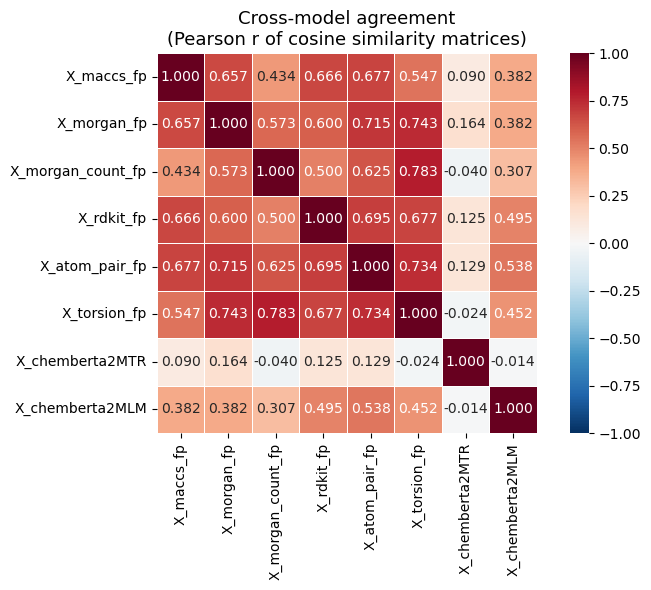

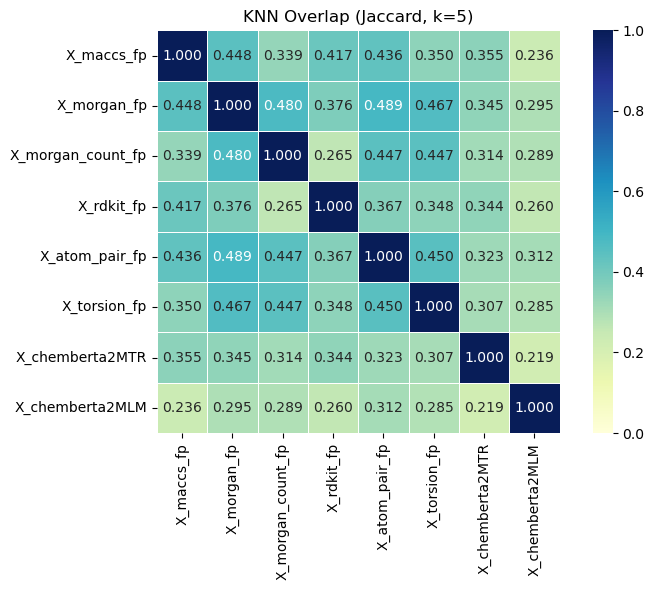

In [26]:
if len(ORDERED_KEYS) >= 2:
    pl.cross_model_similarity(dense_space, obsm_keys=ORDERED_OBSM)
    pl.knn_overlap(dense_space, obsm_keys=ORDERED_OBSM, k=KNN_K)

Scale is worth seeing before you ever concatenate, average, or feed these spaces
to a distance-based method. A binary fingerprint row has L2 norm equal to the
square root of the number of bits it sets -- roughly 5 to 8 for a drug-sized
molecule, whatever the nominal width -- while a pooled transformer vector lands
wherever its training left it. The `mean_l2` column measured that in section 1;
this is the distribution behind the mean. Wherever the magnitudes differ, a naive
concatenation is silently a weighted one, and the larger-norm block dominates
every Euclidean distance downstream. Standardise per block first, or use a metric
that does not care.

The dimension violins need a warning to be worth anything. The first six columns
of a hashed fingerprint are not six features: they are six arbitrary hash
buckets, and on forty molecules most of them are empty for every row. A flat
violin there is the expected result and says nothing about the model. For the
learned spaces the same panel is meaningful, because dimension 0 of ChemBERTa is
a real coordinate that every molecule has a value for.

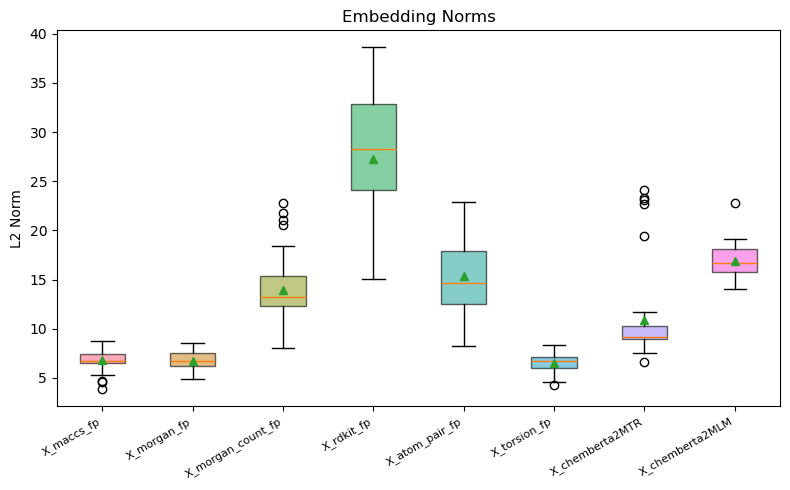

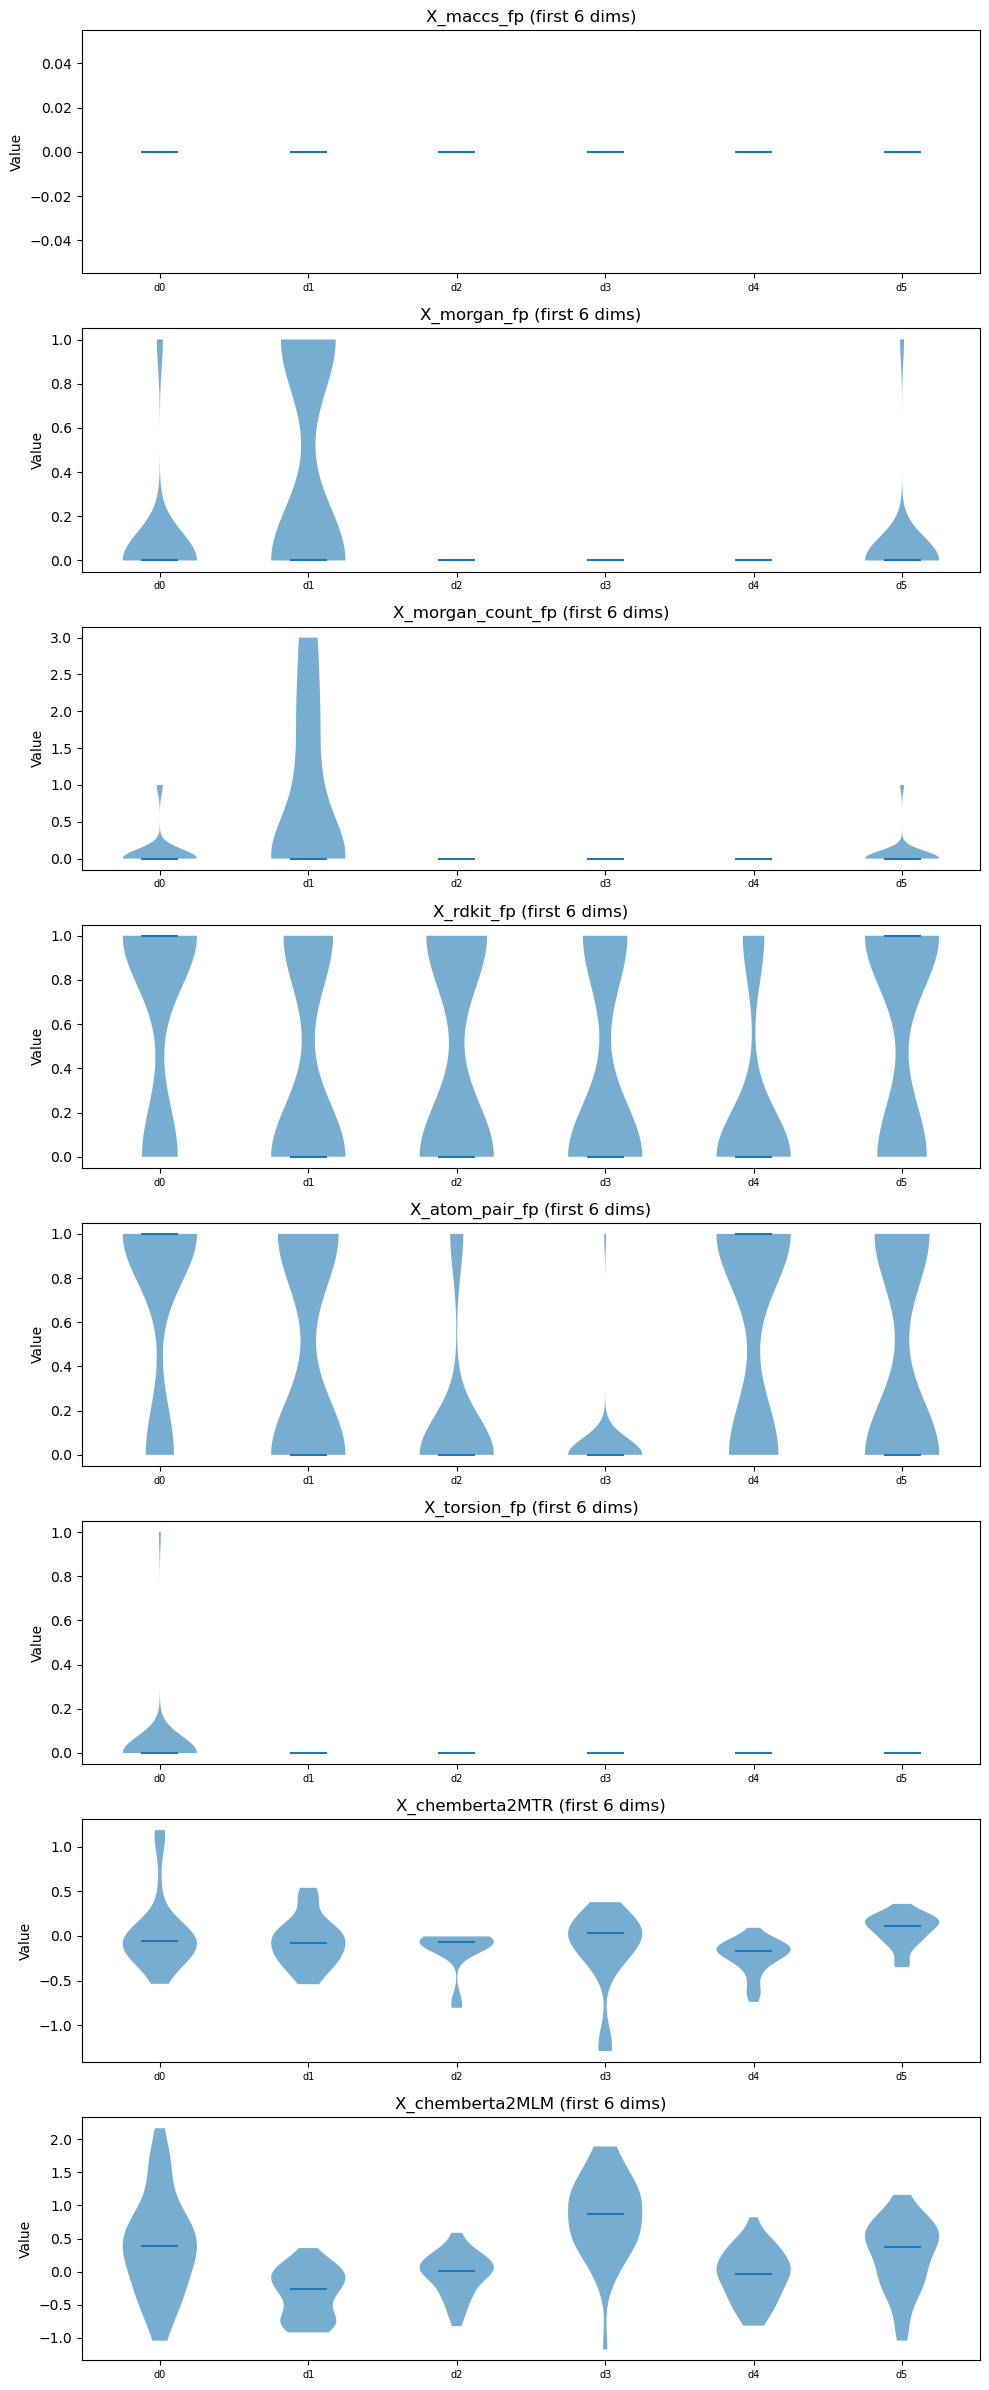

In [27]:
if ORDERED_KEYS:
    pl.embedding_norms(dense_space, obsm_keys=ORDERED_OBSM)
    pl.embedding_distributions(dense_space, obsm_keys=ORDERED_OBSM, n_dims=6)

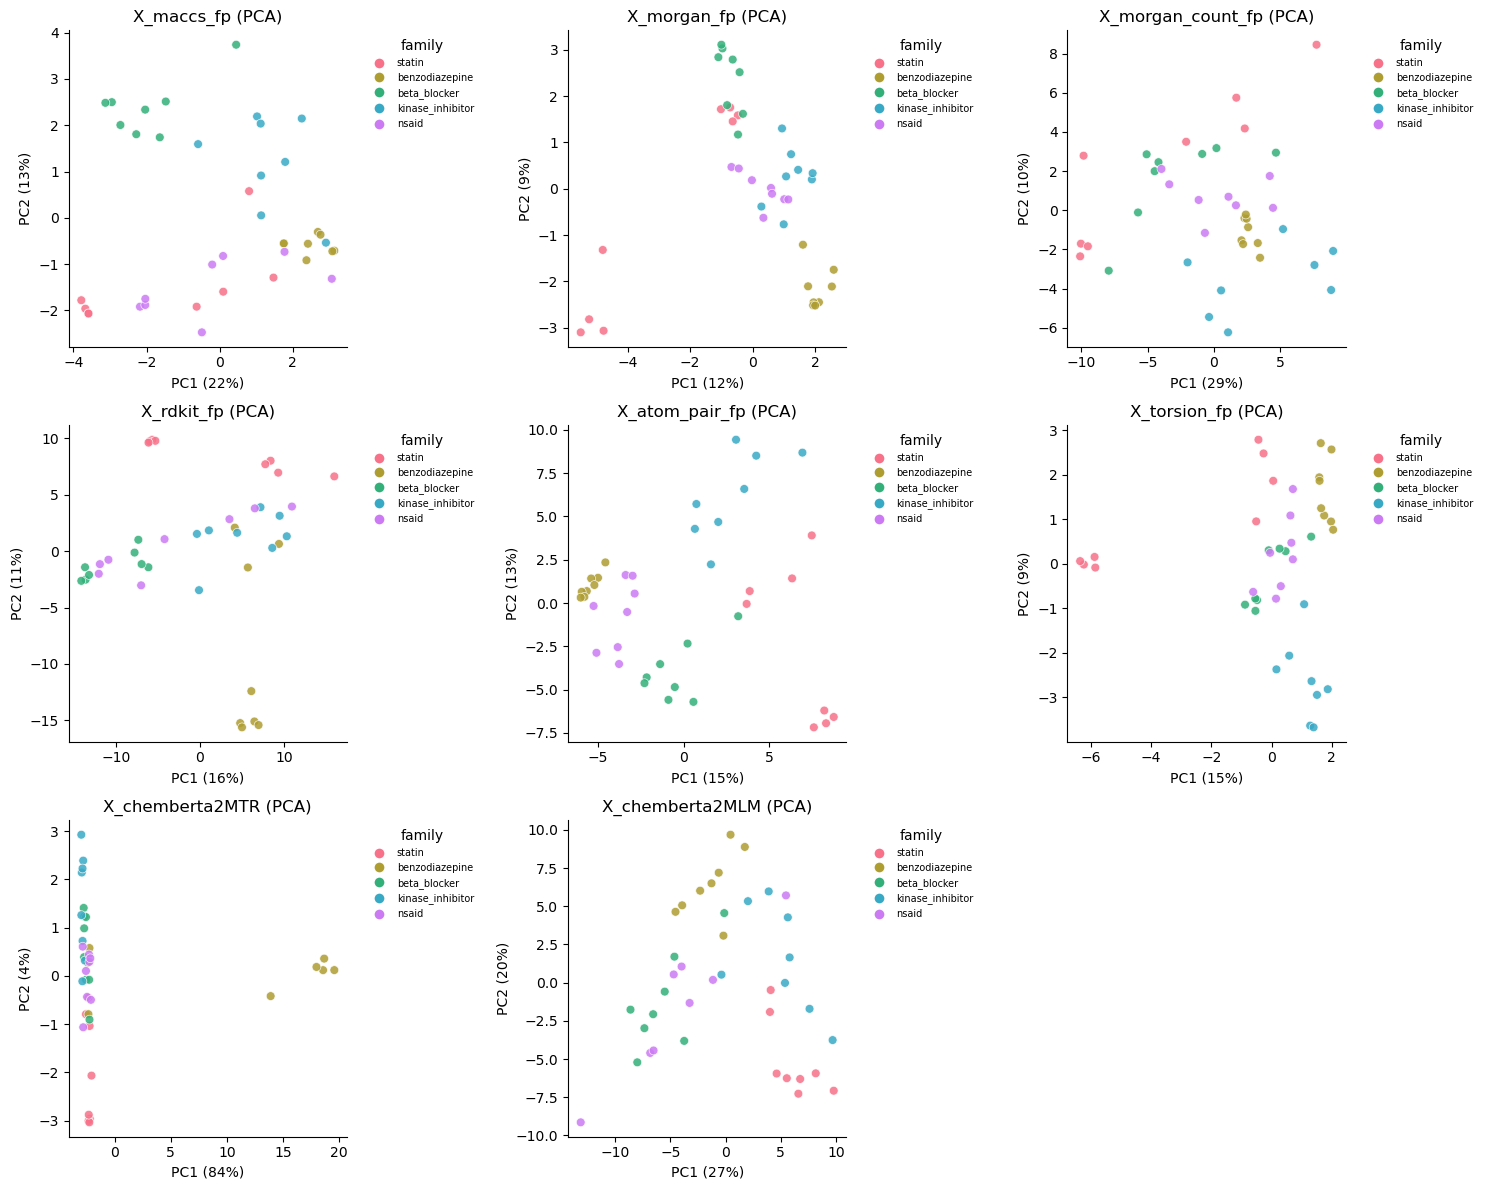

In [28]:
# Same molecules, same colouring, one panel per space -- the qualitative
# counterpart to the tables above. PCA rather than UMAP: on a panel this small a
# UMAP layout is mostly an artefact of its own hyperparameters.
if ORDERED_KEYS:
    pl.all_embeddings(dense_space, obsm_keys=ORDERED_OBSM, method="pca",
                      color="family", ncols=3)

One labelled panel per family, because a five-colour scatter shows you that the
statins clump and hides *which* compound sits in the wrong clump. `annotate_col`
puts the compound name on every point, which is legible at forty rows and would
not be at four hundred.

`plot_embedding_space` caches its 2-D coordinates in `dense_space.obsm` under
`X_pca_<key>`, so the layout is computed once and reused. embpy's key discovery
skips the `X_pca_` prefix by design, so those extra entries do not leak into any
later cell that lets `obsm_keys` default.

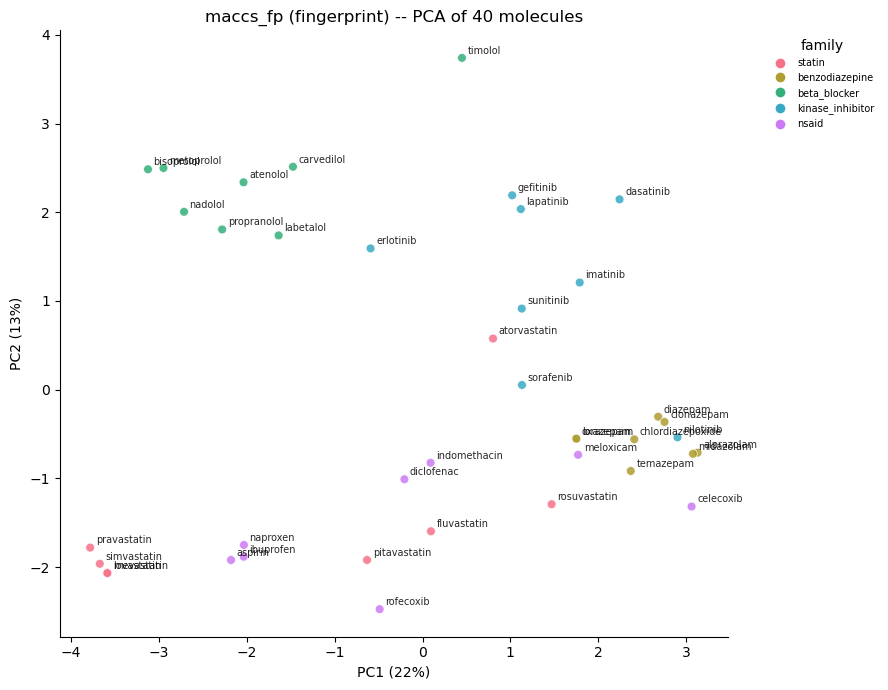

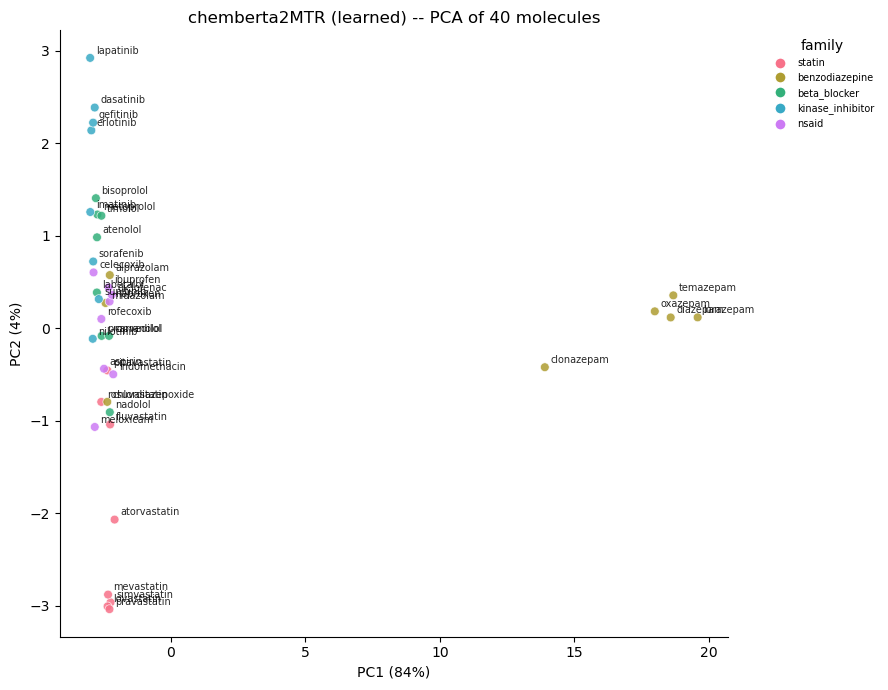

In [29]:
SHOWCASE = [k for k in (FINGERPRINT_KEYS[:1] + LEARNED_KEYS[:1])]
for key in SHOWCASE:
    pl.plot_embedding_space(dense_space, obsm_key=f"X_{key}", color="family",
                            method="pca", annotate=True, annotate_col="compound",
                            figsize=(9, 7),
                            title=f"{key} ({MODEL_FAMILY[key]}) -- PCA of "
                                  f"{dense_space.n_obs} molecules")
if not SHOWCASE:
    print("no space survived the sweep -- nothing to plot")

## Does the geometry track biology?

The [three comparison sections](#1-global-geometry) asked whether the models
agree with each other. Agreement is not correctness, and for molecules that gap
is wider than for genes or proteins: six of the nine spaces are computed from the
same molecular graph by six closely related enumeration schemes, so they are
*obliged* to agree, and their agreement is a statement about RDKit rather than
about pharmacology.

The `family` column is the way out. No fingerprint was shown it, no tokeniser
encodes it, and it is not derivable from a SMILES string -- it is a hand-built
mechanism label, so it is a fair external test. This is the section that scores
the prediction the panel was designed around.

The prediction has two halves, and they point in opposite directions:

* **The tight series should be easy, for a boring reason.** Every statin carries
  the same dihydroxy-heptanoic acid warhead and every benzodiazepine the same
  fused seven-membered ring, so their members share literal substructures. A
  Morgan fingerprint enumerates substructures. Recovering these families needs no
  chemistry beyond bit counting, and a model that *fails* here is telling you
  something about the model, not about the panel.
* **The scaffold-diverse families should be hard, for the same boring reason in
  reverse.** The NSAIDs share one mechanism -- COX inhibition -- across
  salicylate, propionic acid, coxib and oxicam scaffolds; aspirin and celecoxib
  have almost no substructure in common. The kinase inhibitors share a target
  family while spanning scaffolds, imatinib's phenylaminopyrimidine against
  sorafenib's diaryl urea. A structural method has nothing to find.

The second half carries a rider worth stating before the numbers arrive: a
learned representation *might* do better on the diverse families, because it was
fitted to a corpus rather than to an enumeration rule. That is a prediction, and
the cells below score it rather than assuming it.

The beta blockers are the deliberate middle case and are scored on their own. Most
of them hang an ethanolamine off an aryl ether, so a fingerprint has a partial
series to find, but carvedilol's carbazole and labetalol's salicylamide are not in
it. Neither group would be honest about them.

Two readouts, deliberately different in scope:

* `pl.within_vs_between_similarity` -- are same-family pairs more similar than
  cross-family pairs? Returns both means, the pair counts, and a Mann-Whitney
  **p-value**.
* `pl.knn_label_purity` -- of each compound's `k` nearest neighbours, how many
  share its family? Returns per-family values plus `__overall__` and
  `__baseline__`, so the number is interpretable rather than merely large.

In [30]:
# These three groups restate part 1's design table as code. Writing them down here
# rather than deriving them from any measurement is the point: the verdict cell
# below scores a prediction that was fixed before a single vector existed.
TIGHT_SERIES = ["statin", "benzodiazepine"]
SCAFFOLD_DIVERSE = ["nsaid", "kinase_inhibitor"]
MIDDLE_CASE = [f for f in PANEL if f not in TIGHT_SERIES + SCAFFOLD_DIVERSE]

# Score only what actually produced a matrix. A transformer that refused to load
# and a compound the tokeniser dropped both leave the analysis by this route
# rather than by breaking it.
SCORED = [k for k in SWEEP if f"X_{k}" in dense_space.obsm]
OBSM_OF = {k: f"X_{k}" for k in SCORED}

# The registry suffixes every fingerprint key with `_fp`, so the split between
# enumerated and learned representations is derivable from the roster instead of
# hand-listed -- a key added to ROSTER later lands on the correct side by itself.
FINGERPRINT_KEYS = [k for k in SCORED if k.endswith("_fp")]
LEARNED_KEYS = [k for k in SCORED if not k.endswith("_fp")]

# Purity has a ceiling set by family size, not by the model. knn_label_purity asks
# for k+1 neighbours and discards the query itself, so a compound in a family of m
# members has m-1 family-mates left to find and the best attainable value is
# min(k, m-1)/k. The panel is balanced by construction, but the dense mask in
# part 2 can thin a family, so the ceiling is computed rather than assumed.
family_sizes = dense_space.obs["family"].astype(str).value_counts().sort_index()
K_NN = int(min(5, max(2, family_sizes.min() - 1)))
ceiling = (np.minimum(K_NN, family_sizes - 1).clip(lower=0) / K_NN).rename("max_purity")

print(f"spaces scored : {len(SCORED)}  ({len(FINGERPRINT_KEYS)} fingerprint, "
      f"{len(LEARNED_KEYS)} learned)")
print(f"panel         : {dense_space.n_obs} compounds, k = {K_NN}")
print(f"random baseline for {len(family_sizes)} equal families: "
      f"{1 / len(family_sizes):.3f}\n")
print(pd.concat([family_sizes.rename("compounds"), ceiling.round(2)],
                axis=1).to_string())

spaces scored : 8  (6 fingerprint, 2 learned)
panel         : 40 compounds, k = 5
random baseline for 5 equal families: 0.200

                  compounds  max_purity
family                                 
benzodiazepine            8         1.0
beta_blocker              8         1.0
kinase_inhibitor          8         1.0
nsaid                     8         1.0
statin                    8         1.0


Before reading a single purity number, one failure mode specific to fingerprints
needs measuring, because it is invisible in every table that follows.

A fingerprint is a lossy description, and two different molecules can produce the
**same vector**. MACCS is the obvious candidate at 167 bits -- it asks 166 yes/no
questions and two members of a congeneric series can answer all of them
identically -- but a folded 2048-bit space can collide too. Where two rows are
identical, their k-NN ordering is settled by scikit-learn's tie-breaking, which is
index order, so their purity is partly an artefact of how the panel was written
down. The same applies to a zero-norm row: cosine distance is undefined there and
`NearestNeighbors` will happily return something anyway.

Neither is a reason to drop a space. It is a reason to know the number before
quoting a purity to three decimals.

In [31]:
degeneracy = []
for key in SCORED:
    X = np.asarray(dense_space.obsm[OBSM_OF[key]], dtype=float)
    norms = np.linalg.norm(X, axis=1)
    # Rounding before np.unique keeps a float representation difference from being
    # counted as chemistry; fingerprint bits are exact, but the learned spaces are
    # float32 and two rows that differ in the last bit are not a collision.
    _, inverse, counts = np.unique(np.round(X, 6), axis=0,
                                   return_inverse=True, return_counts=True)
    inverse = np.asarray(inverse).ravel()
    degeneracy.append({
        "model": key,
        "dim": int(X.shape[1]),
        "distinct_rows": int(len(counts)),
        "tied_rows": int((counts[inverse] > 1).sum()),
        "zero_norm_rows": int((norms == 0).sum()),
        # Only meaningful for the fingerprints. A dense float space has every
        # coordinate non-zero by construction, so the count there would restate
        # `dim` and invite a comparison that means nothing.
        "mean_bits_set": (float((X != 0).sum(axis=1).mean())
                          if key in FINGERPRINT_KEYS else float("nan")),
    })

# Named columns so an empty sweep still produces a table rather than a KeyError.
DEGENERACY = pd.DataFrame(degeneracy, columns=["model", "dim", "distinct_rows",
                                               "tied_rows", "zero_norm_rows",
                                               "mean_bits_set"]).set_index("model")
display(DEGENERACY.round(3))

tied = DEGENERACY[DEGENERACY["tied_rows"] > 0]
if len(tied):
    print("spaces that cannot tell two panel compounds apart: "
          f"{', '.join(tied.index)} -- their purity rows are partly tie-breaking")
else:
    print(f"every space resolves all {dense_space.n_obs} compounds to distinct "
          "vectors, so no purity number below is decided by tie-breaking")

,dim,distinct_rows,tied_rows,zero_norm_rows,mean_bits_set
model,,,,,
maccs_fp,167,38,4,0,47.80
morgan_fp,2048,40,0,0,46.60
morgan_count_fp,2048,40,0,0,46.60
rdkit_fp,2048,40,0,0,781.15
atom_pair_fp,2048,40,0,0,247.65
torsion_fp,2048,40,0,0,43.10
chemberta2MTR,384,40,0,0,NaN
chemberta2MLM,768,40,0,0,NaN


spaces that cannot tell two panel compounds apart: maccs_fp -- their purity rows are partly tie-breaking


In [32]:
# Both helpers draw as well as return. Sending the per-model figures to one
# throwaway axis pair keeps the ranking table from being buried under 2N plots;
# the spaces that win get their own figures further down.
scratch = plt.figure(figsize=(9, 3.5))
ax_wb, ax_purity = scratch.add_subplot(121), scratch.add_subplot(122)

scores: list[dict] = []
purities: dict[str, dict] = {}

for key in SCORED:
    obsm = OBSM_OF[key]
    X = np.asarray(dense_space.obsm[obsm], dtype=float)
    if not np.isfinite(X).all():
        n_bad = int((~np.isfinite(X)).any(axis=1).sum())
        print(f"skipped {key}: {n_bad} row(s) still carry NaN, which would poison "
              "every mean taken over them")
        continue
    try:
        wb = pl.within_vs_between_similarity(dense_space, label_key="family",
                                            obsm_key=obsm, ax=ax_wb)
        purity = pl.knn_label_purity(dense_space, label_key="family",
                                     obsm_key=obsm, k=K_NN, ax=ax_purity)
    except Exception as exc:
        print(f"skipped {key} -- {type(exc).__name__}: {str(exc)[:90]}")
        continue
    purities[key] = purity
    scores.append({
        "model": key,
        "kind": "fingerprint" if key in FINGERPRINT_KEYS else "learned",
        "dim": int(X.shape[1]),
        "within": wb["mean_within"],
        "between": wb["mean_between"],
        "separation": wb["mean_within"] - wb["mean_between"],
        "p_value": wb["p_value"],
        "purity": purity["__overall__"],
        "baseline": purity["__baseline__"],
    })

plt.close(scratch)

# Named columns so an empty sweep still produces a table rather than a KeyError.
PURITY = pd.DataFrame(scores, columns=["model", "kind", "dim", "within", "between",
                                       "separation", "p_value", "purity",
                                       "baseline"]).set_index("model")
# Sorted on purity, not separation. Purity is bounded above by the ceiling printed
# earlier and is therefore comparable between a 167-bit space and a 2048-bit one;
# a cosine separation is not, because the attainable cosine range depends on how
# sparse and how wide the space is.
if len(PURITY):
    PURITY = PURITY.sort_values(["purity", "separation"], ascending=False)
display(PURITY.round(4))

BEST_MODEL = PURITY.index[0] if len(PURITY) else None
BEST_FINGERPRINT = next((m for m in PURITY.index if m in FINGERPRINT_KEYS), None)
BEST_LEARNED = next((m for m in PURITY.index if m in LEARNED_KEYS), None)
print(f"\nbest overall     : {BEST_MODEL}")
print(f"best fingerprint : {BEST_FINGERPRINT}")
print(f"best learned     : {BEST_LEARNED}")

,kind,dim,within,between,separation,p_value,purity,baseline
model,,,,,,,,
atom_pair_fp,fingerprint,2048,0.5470,0.3710,0.1760,0.0,0.805,0.2
morgan_fp,fingerprint,2048,0.3805,0.2026,0.1779,0.0,0.720,0.2
torsion_fp,fingerprint,2048,0.3927,0.1985,0.1942,0.0,0.675,0.2
maccs_fp,fingerprint,167,0.6717,0.4914,0.1803,0.0,0.655,0.2
morgan_count_fp,fingerprint,2048,0.6704,0.5453,0.1251,0.0,0.575,0.2
chemberta2MLM,learned,768,0.7241,0.5519,0.1722,0.0,0.570,0.2
rdkit_fp,fingerprint,2048,0.5493,0.3987,0.1505,0.0,0.560,0.2
chemberta2MTR,learned,384,0.8738,0.7671,0.1067,0.0,0.530,0.2



best overall     : atom_pair_fp
best fingerprint : atom_pair_fp
best learned     : chemberta2MLM


Read `separation` and `purity` together; they can disagree, and the disagreement
is informative.

**Separation is global.** It averages over every same-family pair and every
cross-family pair at once, so one family parked far from the rest can carry the
whole number while the other four sit on top of each other. **Purity is local.**
It only ever looks at a compound's `k` nearest neighbours, which is the question
you actually act on: hand the space a compound, ask for "molecules like this one",
and see whether its family-mates come back. If you intend to cluster the space,
separation is the number to care about; if you intend to query it, purity is.

The `within` column has one molecule-specific quirk. Binary fingerprints share
their most common bits with almost everything -- an aromatic ring, a carbonyl,
a nitrogen -- so *every* cosine in a fingerprint space is pushed upwards and the
absolute value of `within` is not comparable to the same column in a ChemBERTa
row. The difference between `within` and `between` inside one row is the part
that survives the comparison, which is why `separation` exists as its own column.

The p-value is the least interesting column. With this many pairs the
Mann-Whitney test detects almost any real difference, so a tiny p says the split
is not noise; it says nothing about whether the split is *large*. The two means
and their difference carry that.

### Where each model works, family by family

The overall purity hides exactly the thing the panel was built to expose. Broken
out per family, with the attainable ceiling next to it, the table below is the
actual test: the tight series first, the scaffold-diverse families next, the
beta blockers last, and the columns in the ranking order from above.

In [33]:
PURITY_BY_FAMILY = pd.DataFrame({
    key: {fam: value for fam, value in purities[key].items()
          if not fam.startswith("__")}
    for key in PURITY.index
})

# The row order is the argument, so it is imposed rather than sorted: prediction
# groups in the order part 1 stated them, and any family the dense mask emptied
# drops out instead of appearing as a NaN row.
order = [f for f in TIGHT_SERIES + SCAFFOLD_DIVERSE + MIDDLE_CASE
         if f in PURITY_BY_FAMILY.index]
PURITY_BY_FAMILY = PURITY_BY_FAMILY.reindex(order)

expectation = pd.Series(
    {f: ("tight series" if f in TIGHT_SERIES
         else "scaffold-diverse" if f in SCAFFOLD_DIVERSE
         else "middle case") for f in order},
    name="prediction",
)
display(pd.concat([expectation, ceiling.reindex(order).round(2),
                   PURITY_BY_FAMILY.round(3)], axis=1))

,prediction,max_purity,atom_pair_fp,morgan_fp,torsion_fp,maccs_fp,morgan_count_fp,chemberta2MLM,rdkit_fp,chemberta2MTR
statin,tight series,1.0,0.850,0.750,0.800,0.575,0.600,0.900,0.800,0.700
benzodiazepine,tight series,1.0,0.950,1.000,0.975,0.900,1.000,0.800,0.550,0.575
nsaid,scaffold-diverse,1.0,0.575,0.375,0.300,0.325,0.150,0.250,0.225,0.375
kinase_inhibitor,scaffold-diverse,1.0,0.875,0.525,0.650,0.575,0.575,0.425,0.550,0.375
beta_blocker,middle case,1.0,0.775,0.950,0.650,0.900,0.550,0.475,0.675,0.625


In [34]:
TIGHT_PRESENT = [f for f in TIGHT_SERIES if f in PURITY_BY_FAMILY.index]
DIVERSE_PRESENT = [f for f in SCAFFOLD_DIVERSE if f in PURITY_BY_FAMILY.index]
MIDDLE_PRESENT = [f for f in MIDDLE_CASE if f in PURITY_BY_FAMILY.index]


# Mean purity over one block of the table. NaN when the block is empty, so a
# missing group of models reads as NaN rather than as a confident-looking zero.
def block_mean(models: list[str], families: list[str]) -> float:
    cols = [m for m in models if m in PURITY_BY_FAMILY.columns]
    if not cols or not families:
        return float("nan")
    block = PURITY_BY_FAMILY.loc[families, cols].to_numpy(dtype=float)
    return float(np.nanmean(block)) if np.isfinite(block).any() else float("nan")


# family_purity, not summary: section 1 already bound `summary` to the pairwise
# metric table and this notebook runs in one kernel.
family_purity = pd.DataFrame(
    [
        {"tight series": block_mean(FINGERPRINT_KEYS, TIGHT_PRESENT),
         "scaffold-diverse": block_mean(FINGERPRINT_KEYS, DIVERSE_PRESENT),
         "middle case": block_mean(FINGERPRINT_KEYS, MIDDLE_PRESENT)},
        {"tight series": block_mean(LEARNED_KEYS, TIGHT_PRESENT),
         "scaffold-diverse": block_mean(LEARNED_KEYS, DIVERSE_PRESENT),
         "middle case": block_mean(LEARNED_KEYS, MIDDLE_PRESENT)},
    ],
    index=["fingerprints", "learned (SMILES models)"],
)
family_purity["structure advantage"] = (family_purity["tight series"]
                                        - family_purity["scaffold-diverse"])
display(family_purity.round(3))

baseline = PURITY["baseline"].iloc[0] if len(PURITY) else float("nan")
print(f"random baseline from the family sizes: {baseline:.3f}")

tight_ceiling = (float(ceiling.reindex(TIGHT_PRESENT).mean())
                 if TIGHT_PRESENT else float("nan"))
div_ceiling = (float(ceiling.reindex(DIVERSE_PRESENT).mean())
               if DIVERSE_PRESENT else float("nan"))
if np.isfinite(tight_ceiling) and np.isfinite(div_ceiling) \
        and abs(tight_ceiling - div_ceiling) > 0.02:
    print(f"caution: the two groups do not share a ceiling ({tight_ceiling:.2f} vs "
          f"{div_ceiling:.2f}), so part of any advantage below is family size "
          "rather than chemistry.")

,tight series,scaffold-diverse,middle case,structure advantage
fingerprints,0.812,0.475,0.75,0.337
learned (SMILES models),0.744,0.356,0.55,0.387


random baseline from the family sizes: 0.200


In [35]:
fp_gap = float(family_purity.loc["fingerprints", "structure advantage"])
lr_gap = float(family_purity.loc["learned (SMILES models)", "structure advantage"])
fp_hard = float(family_purity.loc["fingerprints", "scaffold-diverse"])
lr_hard = float(family_purity.loc["learned (SMILES models)", "scaffold-diverse"])

# The verdict sentence is chosen by the measured numbers, including a sentence for
# the case where the prediction was wrong. Half one is the sign of the
# fingerprints' structure advantage; half two is whether the learned spaces beat
# the fingerprints on the families a structural method cannot reach.
if not np.isfinite(fp_gap):
    PREDICTION_VERDICT = (
        "NOT SCORED: no fingerprint space survived the sweep on this panel, so the "
        "prediction has nothing to be scored against. Re-run the embedding section "
        "and read the skip reasons printed there."
    )
elif fp_gap > 0 and np.isfinite(lr_hard) and lr_hard > fp_hard:
    PREDICTION_VERDICT = (
        f"CONFIRMED, both halves: the fingerprints score {fp_gap:.3f} higher on the "
        f"tight series than on the scaffold-diverse families, which is the predicted "
        f"sign, and the learned spaces recover the diverse families better than the "
        f"fingerprints do ({lr_hard:.3f} against {fp_hard:.3f}). A representation "
        "fitted to a corpus reaches something an enumeration rule does not. It is a "
        "narrow win, and the next section asks whether it survives being scored "
        "against a therapeutic label instead of a hand-built one."
    )
elif fp_gap > 0 and np.isfinite(lr_hard):
    PREDICTION_VERDICT = (
        f"PARTLY CONFIRMED: half one holds -- the fingerprints gain {fp_gap:.3f} "
        f"purity on the tight series over their own score on the scaffold-diverse "
        f"families. Half two does not: the learned spaces reach {lr_hard:.3f} on the "
        f"diverse families against the fingerprints' {fp_hard:.3f}, so they inherit "
        "the same blind spot rather than fixing it. That is a coherent result, not a "
        "contradiction: ChemBERTa and MoLFormer read SMILES strings, and a SMILES "
        "string is a serialisation of the same molecular graph the fingerprints "
        "enumerate. Neither was ever shown a mechanism."
    )
elif fp_gap > 0:
    PREDICTION_VERDICT = (
        f"HALF SCORED: the fingerprints carry the predicted structure advantage "
        f"({fp_gap:+.3f}), but no learned space survived the sweep, so the second "
        "half of the prediction is untested. Read the sweep's skip column before "
        "reading anything into the first half alone."
    )
elif fp_gap < 0:
    PREDICTION_VERDICT = (
        f"REFUTED: the fingerprints score {abs(fp_gap):.3f} *higher* on the "
        f"scaffold-diverse families than on the tight series, the opposite way round "
        "from the prediction. Two explanations this notebook can distinguish, and "
        "one it cannot. Check the ceiling column first, in case the dense mask "
        "thinned a tight family; check the tied-rows count next, in case a "
        "congeneric series collapsed onto identical vectors and lost its ordering. "
        "What cannot be ruled out here is that the diverse families are diverse in "
        "a way that still leaves them mutually distinguishable -- a family can be "
        "internally heterogeneous and still be the nearest thing to each of its "
        "members if the other four families are further away."
    )
else:
    PREDICTION_VERDICT = (
        f"INCONCLUSIVE: the fingerprints' structure advantage is exactly "
        f"{fp_gap:+.3f}, so on this panel the tight / diverse split does not "
        "separate them at all. With eight compounds per family an exact tie is more "
        "likely to mean the purity numbers have saturated against the ceiling than "
        "to mean the two groups are genuinely equal -- check the per-family table "
        "against the ceiling column before reading anything into it."
    )

PREDICTION_DELTAS = {"fingerprint_gap": fp_gap, "learned_gap": lr_gap,
                     "fingerprint_diverse": fp_hard, "learned_diverse": lr_hard,
                     "purity_baseline": float(baseline), "k": K_NN,
                     "n_fingerprint_spaces": len(FINGERPRINT_KEYS),
                     "n_learned_spaces": len(LEARNED_KEYS)}
print(PREDICTION_VERDICT)

PARTLY CONFIRMED: half one holds -- the fingerprints gain 0.337 purity on the tight series over their own score on the scaffold-diverse families. Half two does not: the learned spaces reach 0.356 on the diverse families against the fingerprints' 0.475, so they inherit the same blind spot rather than fixing it. That is a coherent result, not a contradiction: ChemBERTa and MoLFormer read SMILES strings, and a SMILES string is a serialisation of the same molecular graph the fingerprints enumerate. Neither was ever shown a mechanism.


Whatever the printed verdict, two things about the *shape* of that table outlive
it.

**The tight series are a low bar dressed as a capability.** Two statins are near
each other because they contain the same atoms in the same arrangement, and a
method that enumerates substructures finds that without knowing what HMG-CoA
reductase is. This notebook never computes a pairwise Tanimoto against the panel,
so treat shared substructure as the panel's design assumption rather than as
something measured here; what *is* measured is the consequence, in the tight-series
rows above and in the nilotinib probe in
[section 2](#2-local-neighbourhoods).

**The scaffold-diverse families are the case that matters, and the one nothing
here solves.** Aspirin and celecoxib inhibit the same enzyme through a
143-dalton acetylated salicylate and a trifluoromethyl pyrazole sulfonamide
respectively. No enumeration of their subgraphs will place them together, and a
model trained on SMILES strings has been shown the same graphs in a different
notation. Recovering that pair needs evidence from outside the structure --
assay data, target annotations, a clinical record -- which is exactly what
[part 5](#annotate-the-molecules) goes and fetches, and what
[the scaffold-hopping section](#molecule-only-scaffold-hopping) turns into a
single yes-or-no test on celecoxib and rofecoxib.

> **A family label is not ground truth about similarity.** `family` is a
> mechanism label the panel imposed, and a low purity means the space disagrees
> with *that* label, not that the space is wrong. Two beta blockers with different
> receptor subtype selectivity are one family here and two behaviours in a clinic.
> The purity numbers are only as sharp as the labelling, and this labelling is
> deliberately coarse.

`PREDICTION_VERDICT` and `PREDICTION_DELTAS` keep the sentence and the numbers
behind it in the kernel, so the closing section can quote the measured result
instead of restating it from memory.

### Which families does each model confuse?

Purity says how often a compound's neighbours are wrong. It does not say *which*
family they came from. Centroid similarity answers that directly: each family is
reduced to its mean vector and the heatmap is the cosine between them. The
diagonal is 1 by construction, so only the **off-diagonal** carries information,
and heat there is a pair the space cannot separate.

Best fingerprint and best learned space, side by side.
`pl.category_centroid_similarity` fixes `vmin`/`vmax` at -1/1, so the two panels
share a colour scale without being told to.

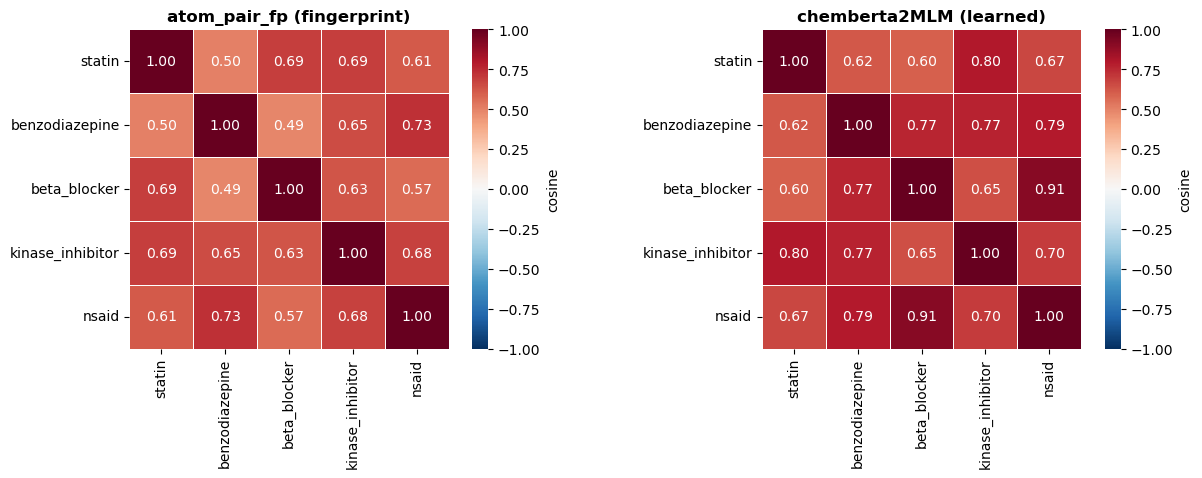

In [36]:
candidates = ((BEST_FINGERPRINT, "fingerprint"), (BEST_LEARNED, "learned"))
centroid_panels = [(model, kind) for model, kind in candidates if model is not None]
absent = [kind for model, kind in candidates if model is None]

if not centroid_panels:
    print("no space survived the sweep, so there is nothing to draw.")
else:
    if absent:
        print(f"no {' or '.join(absent)} space was scored -- only the "
              f"{centroid_panels[0][1]} side is drawn, so this is not a contrast.")
    fig, axes = plt.subplots(1, len(centroid_panels),
                            figsize=(6.4 * len(centroid_panels), 4.8))
    for ax, (model, kind) in zip(np.atleast_1d(axes), centroid_panels):
        pl.category_centroid_similarity(dense_space, label_key="family",
                                        obsm_key=OBSM_OF[model], ax=ax,
                                        title=f"{model} ({kind})")
    fig.tight_layout()

In [37]:
# The heatmaps are for two spaces; the confusion itself is worth having for all of
# them, so every centroid matrix is computed and only the numbers are kept. The
# throwaway axis is the same trick as the ranking cell -- these helpers draw
# whether or not you want the figure.
scratch = plt.figure(figsize=(4, 3))
ax_scratch = scratch.add_subplot(111)

confusions = []
for key in PURITY.index:
    centroids = pl.category_centroid_similarity(
        dense_space, label_key="family", obsm_key=OBSM_OF[key],
        ax=ax_scratch, annot=False,
    )
    values = centroids.to_numpy(dtype=float)
    np.fill_diagonal(values, np.nan)
    flat = np.nanargmax(values)
    i, j = np.unravel_index(flat, values.shape)
    confusions.append({
        "model": key,
        "worst pair": f"{centroids.index[i]} / {centroids.columns[j]}",
        "that cosine": float(values[i, j]),
        "mean off-diagonal": float(np.nanmean(values)),
        "min off-diagonal": float(np.nanmin(values)),
    })

plt.close(scratch)

# Named columns so an empty sweep still produces a table rather than a KeyError.
CONFUSION = pd.DataFrame(confusions, columns=["model", "worst pair", "that cosine",
                                              "mean off-diagonal",
                                              "min off-diagonal"]).set_index("model")
display(CONFUSION.round(3))

pairs = CONFUSION["worst pair"].value_counts()
if len(pairs):
    print(f"most frequently confused pair across {len(CONFUSION)} spaces: "
          f"{pairs.index[0]} ({pairs.iloc[0]} of {len(CONFUSION)})")

,worst pair,that cosine,mean off-diagonal,min off-diagonal
model,,,,
atom_pair_fp,benzodiazepine / nsaid,0.733,0.625,0.488
morgan_fp,kinase_inhibitor / nsaid,0.587,0.456,0.283
torsion_fp,benzodiazepine / nsaid,0.619,0.436,0.271
maccs_fp,statin / nsaid,0.805,0.707,0.555
morgan_count_fp,benzodiazepine / nsaid,0.892,0.790,0.681
chemberta2MLM,beta_blocker / nsaid,0.912,0.728,0.600
rdkit_fp,kinase_inhibitor / nsaid,0.814,0.695,0.544
chemberta2MTR,beta_blocker / kinase_inhibitor,0.974,0.797,0.531


most frequently confused pair across 8 spaces: benzodiazepine / nsaid (3 of 8)


The `mean off-diagonal` column is the one to read first, and it is a property of
the *space* rather than of the panel. A binary fingerprint puts every drug-like
molecule in the same corner of the hypercube -- they all have rings, nitrogens and
carbonyls -- so its family centroids sit at a high cosine to each other no matter
how well it separates them. A high mean off-diagonal next to a high purity is not
a contradiction: the neighbourhoods can be clean while the centroids are crowded.
That is why the `min` column is next to it. The spread between mean and min is the
amount of family structure the space actually expresses.

`worst pair` is where the chemistry shows through. Two failure modes are worth
distinguishing when you read it:

* **A shared pharmacophore.** Beta blockers and benzodiazepines are both
  nitrogen-rich and lipophilic; nothing in either family's definition stops them
  being close in a substructure count.
* **A shared size.** Fingerprint cosine is sensitive to how many bits are set,
  and the `mean_bits_set` column above says how much that varies. Two families of
  similarly large molecules -- statins and kinase inhibitors -- can be near each
  other because they are both big, which is a fact about molecular weight
  masquerading as a fact about mechanism.

Neither is diagnosed by this table alone. Both are visible in it, which is the
most a five-family panel can offer.

## Unsupervised structure

Purity, separation and the centroid heatmaps all use the labels. Clustering asks
the same question without them: left to itself, does the winning space rediscover
the panel? `tl.cluster_annotation_enrichment` then scores each cluster against
`family`, so a cluster that is one family and nothing else appears as a high
fold-enrichment row.

Two implementation facts to know before reading the output.

**The graph is Euclidean, and you cannot change that here.** `tl.leiden` calls
`sc.pp.neighbors` with scanpy's default metric, and exposes no `metric` argument;
`tl.find_nearest_neighbors` does have one, but `tl.leiden` rebuilds the graph
unconditionally, so the two do not compose. For a binary fingerprint this is less
arbitrary than it sounds -- the squared Euclidean distance between two bit vectors
*is* their Hamming distance -- but it is not Tanimoto, which is the coefficient
cheminformatics actually uses, and the difference is exactly the normalisation by
molecule size that the paragraph above was about. The dendrogram at the end of the
section is drawn on cosine distance, so the two views disagree by construction.

**Leiden needs `leidenalg` and `igraph`.** If they are absent the cell says so and
the notebook carries on.

In [38]:
# pl.leiden_overview looks for a column named leiden_{obsm_key} and computes it if
# it is missing. Writing it under that exact name here means the overview figure
# below reuses this partition instead of clustering a second time and drawing a
# picture of a different answer.
LEIDEN_KEY = f"leiden_{OBSM_OF[BEST_MODEL]}" if BEST_MODEL else "leiden_none"
clustered = False

if BEST_MODEL is None:
    print("no scored space, so clustering is skipped.")
else:
    n_neighbors = int(min(8, max(2, dense_space.n_obs - 1)))
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            dense_space = tl.leiden(dense_space, obsm_key=OBSM_OF[BEST_MODEL],
                                    resolution=1.0, n_neighbors=n_neighbors,
                                    key_added=LEIDEN_KEY)
        clustered = True
    except ImportError as exc:
        print(f"leiden unavailable -- {exc}\n  pip install leidenalg igraph")
    except Exception as exc:
        print(f"clustering skipped -- {type(exc).__name__}: {str(exc)[:120]}")

if clustered:
    # Both views get the column. dense_space carries it under the name the plotting
    # helper expects, mol_space under the plain name later sections read, and a
    # compound the dense mask dropped is labelled rather than left as a NaN that
    # would silently become its own category in a crosstab.
    labels = pd.Series(dense_space.obs[LEIDEN_KEY].astype(str).values,
                       index=dense_space.obs_names)
    dense_space.obs["leiden"] = labels.values
    mol_space.obs["leiden"] = (labels.reindex(mol_space.obs_names)
                               .fillna("not clustered").values)
    unplaced = int((mol_space.obs["leiden"] == "not clustered").sum())

    print(f"leiden on {BEST_MODEL} (k = {n_neighbors} neighbours, resolution 1.0):")
    print(dense_space.obs["leiden"].value_counts().sort_index().to_string())
    print(f"\n{dense_space.obs['leiden'].nunique()} clusters for "
          f"{len(family_sizes)} designed families")
    if unplaced:
        print(f"{unplaced} compound(s) outside dense_space carry 'not clustered'")

leiden on atom_pair_fp (k = 8 neighbours, resolution 1.0):
leiden
0    11
1     8
2     7
3     6
4     4
5     4

6 clusters for 5 designed families


In [39]:
if clustered:
    # The crosstab is the honest version of the enrichment table: it shows the
    # whole partition, including the clusters that are mixtures, which a top_k
    # ranking by fold-enrichment hides.
    display(pd.crosstab(dense_space.obs["leiden"], dense_space.obs["family"]))
    display(tl.cluster_annotation_enrichment(dense_space, cluster_key="leiden",
                                             annotation_key="family",
                                             top_k=3).round(3))

family,statin,benzodiazepine,beta_blocker,kinase_inhibitor,nsaid
leiden,,,,,
0,0,3,0,8,0
1,0,0,8,0,0
2,0,5,0,0,2
3,0,0,0,0,6
4,4,0,0,0,0
5,4,0,0,0,0


,cluster,term,in_cluster,overall,in_freq,overall_freq,enrichment
0,0,kinase_inhibitor,8,8,0.727,0.2,3.64
1,0,benzodiazepine,3,8,0.273,0.2,1.36
2,1,beta_blocker,8,8,1.000,0.2,5.00
3,2,benzodiazepine,5,8,0.714,0.2,3.57
4,2,nsaid,2,8,0.286,0.2,1.43
5,3,nsaid,6,8,1.000,0.2,5.00
6,4,statin,4,8,1.000,0.2,5.00
7,5,statin,4,8,1.000,0.2,5.00


Read the cluster count before the enrichment table. Leiden at resolution 1.0 is
told nothing about how many families the panel has, so compare the two counts
printed next to each other: more clusters than families means it split one --
usually the family whose members are least alike -- and fewer means it merged two,
which is the same confusion the off-diagonal heat showed, now expressed as a
partition of the compounds rather than as a similarity between means.

One caution on the enrichment column. With eight compounds per family and five
families, a cluster of two compounds that happen to share a family scores a
fold-enrichment of 5.0, the maximum, on the strength of two molecules. Read
`in_cluster` alongside `enrichment` and treat the small clusters as unresolved
rather than as discoveries.

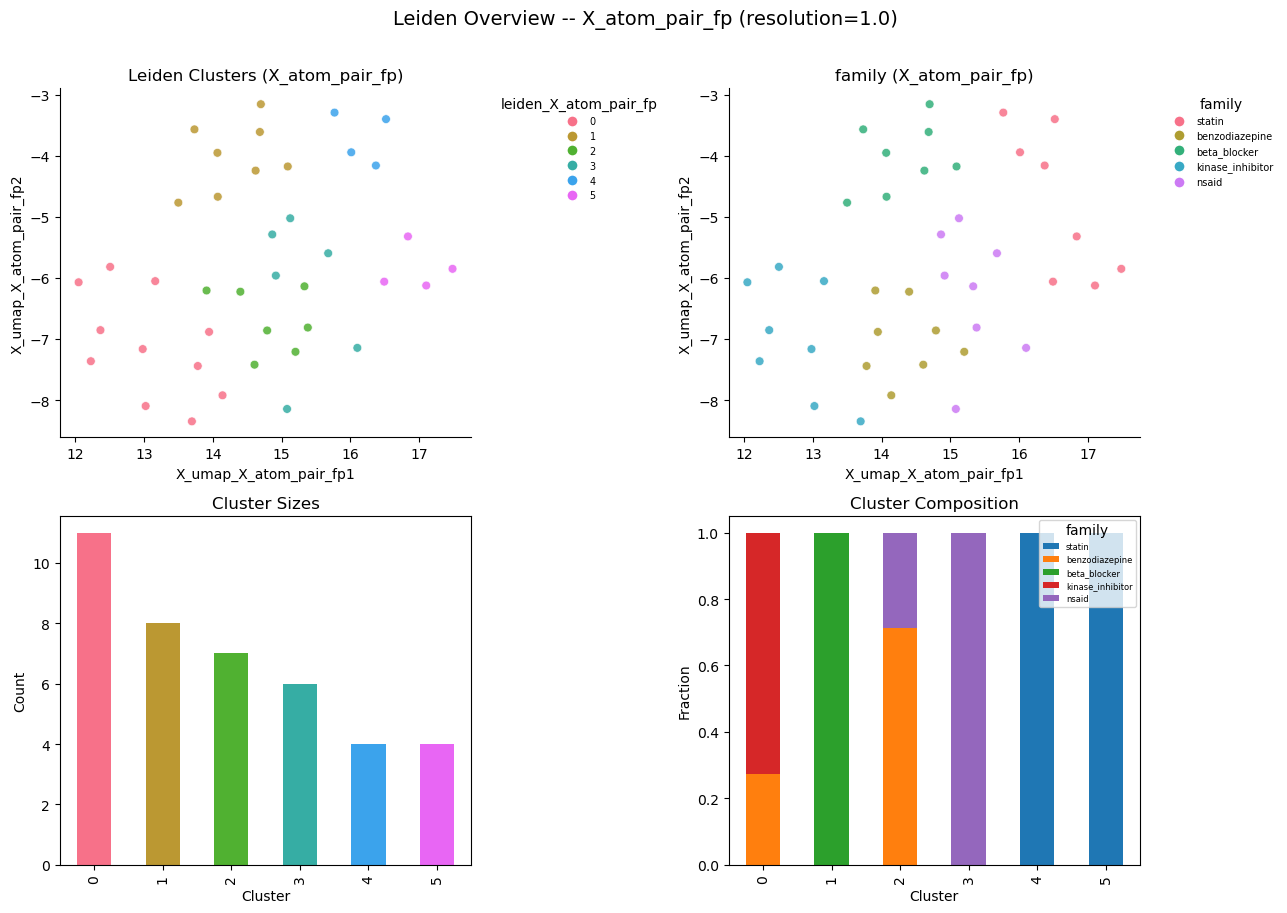

In [40]:
if clustered:
    try:
        # color_by adds the metadata UMAP and the composition bar chart, which is
        # the whole reason to call the overview rather than plotting the clusters
        # alone: the cluster panel and the family panel are the same coordinates.
        pl.leiden_overview(dense_space, obsm_key=OBSM_OF[BEST_MODEL],
                           resolution=1.0, color_by="family", figsize=(13, 9))
    except Exception as exc:
        print(f"overview skipped -- {type(exc).__name__}: {str(exc)[:120]}")

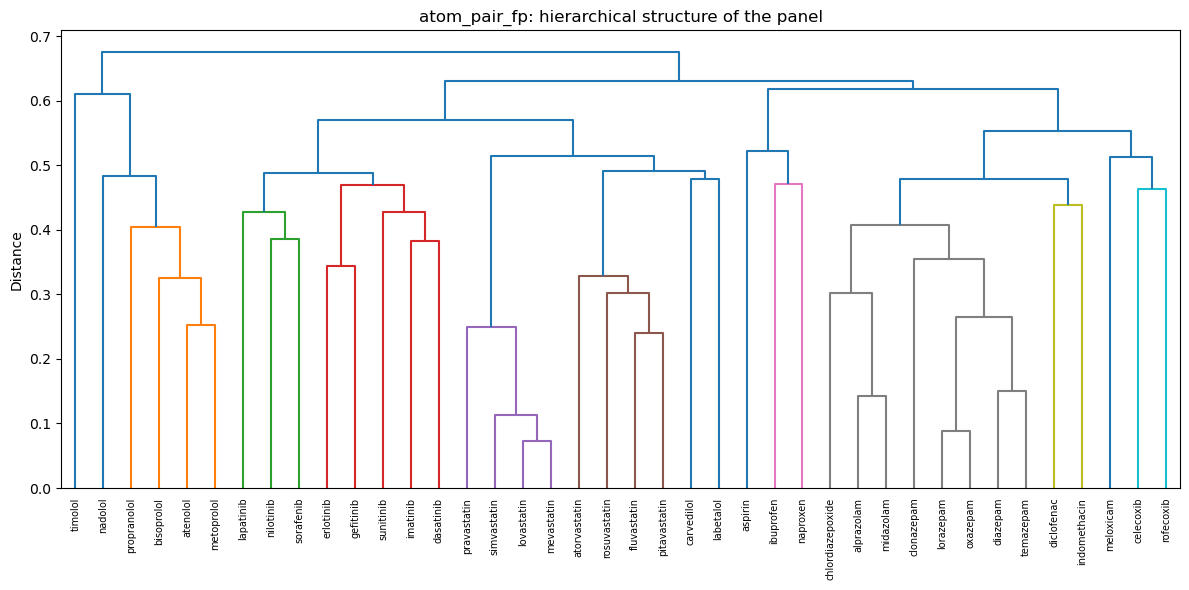

In [41]:
if BEST_MODEL is not None:
    # labels= is not optional here. pl.dendrogram falls back to adata.obs_names,
    # and for this notebook those are canonical SMILES, which makes an unreadable
    # axis. The compound column is the human-readable identity.
    pl.dendrogram(dense_space, obsm_key=OBSM_OF[BEST_MODEL], metric="cosine",
                  labels=dense_space.obs["compound"].astype(str).tolist(),
                  leaf_font_size=7,
                  title=f"{BEST_MODEL}: hierarchical structure of the panel")

The dendrogram is the most useful picture in this section, because it shows the
*order* in which the space merges compounds rather than a partition at one
resolution. Three things to look for, in this order:

1. **Do the tight series come out as single early-merging blocks?** They should.
   If a statin joins the benzodiazepines before it joins the other statins, the
   space has a problem that no purity number at k = 5 would have shown you.
2. **Where does the NSAID block break?** The prediction is that it does not exist
   as a block at all -- aspirin near nothing, the coxibs together, the propionic
   acids together. A structural space should shatter this family along scaffold
   lines, and the leaf order says which lines.
3. **Which compound is the outlier?** Every space has one, and it is usually
   informative: the smallest molecule in the panel has the fewest bits set and
   therefore the lowest cosine to everything, so an outlier at the far edge may be
   reporting molecular weight rather than chemistry.

That is as far as structure alone goes. Every label used in this section --
`family` above all -- was written by hand for this notebook, and a hand-built
label can flatter a method that agrees with the same intuition that built it. The
[next part](#annotate-the-molecules) replaces it with the curated clinical record:
ATC class, development phase, mechanism of action and measured target potency, all
fetched from ChEMBL, none of them written by anyone who had seen these embeddings.
Then [the same purity machinery](#does-the-embedding-know-the-clinical-record)
runs again against those labels, and the verdict either survives the swap or it
does not.

## Annotate the molecules

Everything so far treated a compound as a structure and asked whether the models
agree about it. That is only half of what is known about these forty molecules.
Each one also has a physicochemical profile, a clinical history, a set of
targets, a regulatory record and, for two of them, a reason it is no longer
prescribed.

Two entry points, deliberately separate:

* `tl.annotate_molecules` -- local, RDKit only, no network. Physicochemical
  properties computed from the structure.
* `tl.annotate_drug_perturbations` -- the ChEMBL clinical record. Live API,
  roughly a dozen requests per compound.

Start with the local one, because it cannot fail and it establishes the
`mol_*` column convention.

In [42]:
mol_space = tl.annotate_molecules(
    mol_space, column="smiles", sources=["structural"], copy=True,
)

mol_cols = [c for c in mol_space.obs.columns if c.startswith("mol_")]
print(f"{len(mol_cols)} mol_* columns:", mol_cols)

display(
    mol_space.obs.groupby("family", observed=True)[
        ["mol_molecular_weight", "mol_logp", "mol_tpsa", "mol_qed",
         "mol_lipinski_violations"]
    ].mean().round(2)
)

12 mol_* columns: ['mol_molecular_weight', 'mol_logp', 'mol_tpsa', 'mol_hbd', 'mol_hba', 'mol_rotatable_bonds', 'mol_qed', 'mol_lipinski_violations', 'mol_fsp3', 'mol_heavy_atoms', 'mol_n_targets', 'mol_canonical_smiles']


,mol_molecular_weight,mol_logp,mol_tpsa,mol_qed,mol_lipinski_violations
family,,,,,
statin,438.91,4.13,96.10,0.50,0.25
benzodiazepine,305.42,3.00,51.87,0.78,0.00
beta_blocker,309.91,1.75,71.22,0.64,0.00
kinase_inhibitor,474.49,4.62,88.73,0.42,0.62
nsaid,289.72,2.97,62.91,0.79,0.00


`mol_qed` is quantitative estimate of drug-likeness, and every family scores
respectably because every compound in this panel *is* a drug. That makes QED a
poor discriminator here, which matters later: predicting it from a fingerprint
is close to circular, since QED is itself a function of the same descriptors a
fingerprint encodes. The
[downstream section](#downstream-which-model-predicts-a-measured-property)
comes back to that.

## The clinical record

`tl.annotate_drug_perturbations` reaches ChEMBL for what the structure cannot
tell you: what phase a compound reached, what it is indicated for, whether it
was withdrawn and why, where the WHO files it, what it inhibits, and how it is
cleared.

This is the slow cell in the notebook -- forty compounds against a live API.
Every downstream section reads the `drug_*` columns it writes.

In [43]:
# Annotate mol_space (all forty, and what the save cell writes to disk), then
# copy the columns onto dense_space rather than annotating twice -- the API
# calls are the expensive part and both objects hold the same compounds.
mol_space = tl.annotate_drug_perturbations(
    mol_space, column="compound", sources="all", copy=True,
)

drug_cols = [c for c in mol_space.obs.columns if c.startswith("drug_")]
print(f"{len(drug_cols)} drug_* columns")

matched = int(mol_space.obs["drug_in_chembl"].sum())
print(f"matched in ChEMBL: {matched}/{mol_space.n_obs}")

for col in drug_cols:
    dense_space.obs[col] = mol_space.obs.loc[dense_space.obs_names, col].values
for col in [c for c in mol_space.obs.columns if c.startswith("mol_")]:
    dense_space.obs[col] = mol_space.obs.loc[dense_space.obs_names, col].values

ANNOTATED = f"{matched}/{mol_space.n_obs} compounds matched in ChEMBL"

39 drug_* columns
matched in ChEMBL: 40/40


Note the identifier: `column="compound"`, the lowercase generic names from the
panel, not the SMILES. ChEMBL resolves names, trade names, research codes and
ChEMBL IDs as well as structures, and for a screen whose plate map holds
"imatinib" rather than a SMILES string that is the column you have.

### Development status

The first question to ask of a compound list is what kind of compounds are on
it. "Approved drug" and "clinical candidate" and "tool compound" are three very
different claims, and ChEMBL distinguishes them.

In [44]:
display(
    mol_space.obs[[
        "compound", "family", "drug_pref_name", "drug_development_phase",
        "drug_first_approval", "drug_availability", "drug_oral",
    ]].head(10).reset_index(drop=True)
)

display(
    mol_space.obs.groupby("drug_development_phase", observed=True)
    .size().to_frame("n_compounds")
)

,compound,family,drug_pref_name,drug_development_phase,drug_first_approval,drug_availability,drug_oral
0,atorvastatin,statin,ATORVASTATIN,approved,1996.0,prescription only,True
1,simvastatin,statin,SIMVASTATIN,approved,1991.0,prescription only,True
2,lovastatin,statin,LOVASTATIN,approved,1987.0,prescription only,True
3,pravastatin,statin,PRAVASTATIN,approved,1991.0,prescription only,True
4,rosuvastatin,statin,ROSUVASTATIN,approved,2003.0,prescription only,True
5,fluvastatin,statin,FLUVASTATIN,approved,1993.0,prescription only,True
6,pitavastatin,statin,PITAVASTATIN,approved,2009.0,prescription only,True
7,mevastatin,statin,MEVASTATIN,phase 2,NaN,,False
8,diazepam,benzodiazepine,DIAZEPAM,approved,1963.0,prescription only,True
9,lorazepam,benzodiazepine,LORAZEPAM,approved,1977.0,prescription only,True


,n_compounds
drug_development_phase,
approved,39
phase 2,1


> **`None` and `-1` are different claims.** A `max_phase` of `None` means a
> preclinical compound with bioactivity data and no clinical record;
> `-1` means ChEMBL has a clinical candidate but cannot assign a phase to it.
> Folding either into "phase 0" would invent a fact. `drug_development_phase`
> renders them as `"preclinical"` and `"clinical phase unknown"` respectively.

Every compound in this panel is approved, which is a property of how the panel
was chosen rather than a finding. A real screen mixes approved drugs with tool
compounds, and this column is what separates them.

### What each drug is for

Indications come as MeSH headings and EFO terms, each carrying the phase reached
*for that indication* -- which is not the same as the compound's overall maximum
phase. A drug approved for one disease and in phase 2 for another has one
`drug_max_phase` and two very different indication rows.

In [45]:
display(
    mol_space.obs[["compound", "drug_n_indications", "drug_top_indication"]]
    .sort_values("drug_n_indications", ascending=False)
    .head(8).reset_index(drop=True)
)

# The full records live in .uns; obs carries only the summary. Read one out to
# see the per-indication phase, which is the field the summary cannot hold.
ann = mol_space.uns["chembl_annotations"].get("imatinib", {})
for ind in (ann.get("indications") or [])[:5]:
    print(f"  phase {ind['max_phase_for_indication']}  "
          f"{ind['mesh_heading']}  ({ind['efo_term']})")

,compound,drug_n_indications,drug_top_indication
0,aspirin,99,Fever
1,simvastatin,99,Hypercholesterolemia
2,celecoxib,98,"Spondylitis, Ankylosing"
3,midazolam,93,Amnesia
4,propranolol,89,Hypertension
5,dasatinib,88,"Leukemia, Myelogenous, Chronic, BCR-ABL Positive"
6,ibuprofen,86,Fever
7,atorvastatin,84,Hypercholesterolemia


  phase 4.0  Leukemia, Myelogenous, Chronic, BCR-ABL Positive  (chronic myelogenous leukemia)
  phase 4.0  Precursor Cell Lymphoblastic Leukemia-Lymphoma  (acute lymphoblastic leukemia)
  phase 4.0  Hypereosinophilic Syndrome  (Hypereosinophilic syndrome)
  phase 4.0  Precursor Cell Lymphoblastic Leukemia-Lymphoma  (childhood acute lymphoblastic leukemia)
  phase 4.0  Precursor Cell Lymphoblastic Leukemia-Lymphoma  (lymphoblastic lymphoma)


ChEMBL records one row per drug-indication-reference triple, so the same disease
recurs with different phases; `get_indications` collapses those to one entry per
indication keeping the highest phase, which is why the counts here are smaller
than the raw row counts.

`drug_n_indications` is capped at `DEFAULT_INDICATIONS`, and a compound that
hits the cap gets `drug_n_indications_at_limit` set -- a count from a capped
fetch is not a measurement, and regressing on one without checking that flag is
a silent mistake.

### The safety record

This is where the panel earns its two deliberate inclusions. Rofecoxib was
withdrawn worldwide in 2004; celecoxib, same target and same mechanism, was not.
No structural embedding in this notebook can distinguish those two facts,
because the difference is not in the molecules.

In [46]:
safety = mol_space.obs[[
    "compound", "family", "drug_is_withdrawn", "drug_has_black_box_warning",
    "drug_n_warnings", "drug_withdrawn_reason",
]]
display(safety[safety["drug_n_warnings"] > 0].reset_index(drop=True))

print(f"withdrawn        : {list(safety.loc[safety['drug_is_withdrawn'], 'compound'])}")
print(f"black box warning: {list(safety.loc[safety['drug_has_black_box_warning'], 'compound'])}")

,compound,family,drug_is_withdrawn,drug_has_black_box_warning,drug_n_warnings,drug_withdrawn_reason
0,diazepam,benzodiazepine,False,True,2,
1,lorazepam,benzodiazepine,False,True,2,
2,alprazolam,benzodiazepine,False,True,2,
3,clonazepam,benzodiazepine,False,True,2,
4,midazolam,benzodiazepine,False,True,4,
5,temazepam,benzodiazepine,False,True,1,
6,oxazepam,benzodiazepine,False,True,2,
7,chlordiazepoxide,benzodiazepine,False,True,2,
8,propranolol,beta_blocker,False,True,1,
9,atenolol,beta_blocker,False,True,1,


withdrawn        : ['rofecoxib']
black box warning: ['diazepam', 'lorazepam', 'alprazolam', 'clonazepam', 'midazolam', 'temazepam', 'oxazepam', 'chlordiazepoxide', 'propranolol', 'atenolol', 'metoprolol', 'nadolol', 'nilotinib', 'sunitinib', 'lapatinib', 'ibuprofen', 'naproxen', 'diclofenac', 'celecoxib', 'rofecoxib', 'indomethacin', 'meloxicam']


In [47]:
# The full warning records carry the class, country, year and references that
# the obs summary flattens away.
for warning in (mol_space.uns["chembl_annotations"]
                .get("rofecoxib", {}).get("warnings") or [])[:4]:
    print(f"  {warning['warning_type']:20s} {str(warning['warning_class']):18s} "
          f"{str(warning['warning_country']):16s} {warning['warning_year']}")

  Black Box Warning    None               United States    None
  Withdrawn            cardiotoxicity     Worldwide        2004
  Withdrawn            cardiotoxicity     Worldwide        2004
  Withdrawn            cardiotoxicity     Worldwide        2004


`cardiotoxicity`, `Worldwide`, `2004`. That is the fact a cheminformatics model
cannot recover from structure, and the reason a compound annotation layer is not
optional decoration on an embedding package.

### Where the WHO puts them

The ATC hierarchy is a *therapeutic* classification: it files a compound by what
it is used for and where it acts, not by what it looks like. That makes it an
independent label to test the embeddings against, and unlike the hand-built
`family` column it was not chosen by whoever wrote this notebook.

In [48]:
atc = pd.crosstab(mol_space.obs["family"], mol_space.obs["drug_atc_level1"])
display(atc)

print("compounds holding several ATC codes:")
for name in mol_space.obs["compound"]:
    classes = mol_space.uns["chembl_annotations"].get(name, {}).get("atc_classes") or []
    if len(classes) > 1:
        print(f"  {name:16s} {[c['code'] for c in classes]}")

drug_atc_level1,,ANTINEOPLASTIC AND IMMUNOMODULATING AGENTS,BLOOD AND BLOOD FORMING ORGANS,CARDIOVASCULAR SYSTEM,GENITO URINARY SYSTEM AND SEX HORMONES,MUSCULO-SKELETAL SYSTEM,NERVOUS SYSTEM
family,,,,,,,
statin,1,0,0,7,0,0,0
benzodiazepine,0,0,0,0,0,0,8
beta_blocker,0,0,0,8,0,0,0
kinase_inhibitor,0,8,0,0,0,0,0
nsaid,0,0,1,1,2,4,0


compounds holding several ATC codes:
  lorazepam        ['N05BA56', 'N05BA06']
  timolol          ['C07AA06', 'S01ED51', 'S01ED01']
  aspirin          ['B01AC06', 'N02BA01', 'N02BA51', 'A01AD05', 'N02BA71']
  ibuprofen        ['G02CC01', 'M01AE51', 'M02AA13', 'R02AX02', 'C01EB16', 'M01AE01']
  naproxen         ['G02CC02', 'M01AE02', 'M02AA12']
  diclofenac       ['M01AB55', 'D11AX18', 'M01AB05', 'M02AA15']
  celecoxib        ['M01AH01', 'L01XX33']
  indomethacin     ['C01EB03', 'M02AA23', 'M01AB51', 'S01BC01', 'M01AB01']
  meloxicam        ['M01AC56', 'M01AC06']


The two classifications disagree, and the disagreements are the informative
part. Aspirin holds five ATC codes spanning antithrombotics and analgesics: it
is one molecule with several therapeutic identities, and any single-label
evaluation has to pick one and throw the rest away.

### Mechanism, and the parent-molecule trap

Mechanism of action is curated rather than computed, and it is the field most
likely to be silently empty for reasons that have nothing to do with the
compound.

> **Drug-level annotation hangs off the parent molecule.** ChEMBL registers
> mechanisms, indications and warnings against the *parent* form, not the salt
> that was dosed. Imatinib is `CHEMBL941`; the marketed drug is imatinib
> mesylate, `CHEMBL1642`, whose parent is `CHEMBL941`. Query the mechanism table
> by `molecule_chembl_id=CHEMBL941` and it returns **nothing at all** -- not an
> error, an empty list, indistinguishable from a compound with no known
> mechanism.

The cell below asks ChEMBL both ways, so the trap is visible rather than
described.

In [49]:
import requests

CHEMBL_API = "https://www.ebi.ac.uk/chembl/api/data"

both_ways = []
for field in ("molecule_chembl_id", "parent_molecule_chembl_id"):
    try:
        resp = requests.get(
            f"{CHEMBL_API}/mechanism.json",
            params={field: "CHEMBL941", "format": "json"}, timeout=30,
        )
        n = resp.json()["page_meta"]["total_count"]
    except Exception as exc:
        n = f"unreachable ({type(exc).__name__})"
    both_ways.append({"filter": field, "mechanisms_returned": n})

display(pd.DataFrame(both_ways).set_index("filter"))

,mechanisms_returned
filter,
molecule_chembl_id,0
parent_molecule_chembl_id,4


In [50]:
# embpy resolves the hierarchy first, so the annotator returns the parent's
# mechanisms whichever form you name.
from embpy.resources import ChEMBLAnnotator

chembl = ChEMBLAnnotator(rate_limit_delay=0.1)
for mech in chembl.get_mechanisms("imatinib"):
    print(f"  {mech['action_type']:12s} {mech['mechanism']}")
    print(f"               direct={mech['direct_interaction']} "
          f"efficacy={mech['disease_efficacy']} refs={len(mech['references'])}")

  INHIBITOR    Tyrosine-protein kinase ABL inhibitor
               direct=True efficacy=True refs=2
  INHIBITOR    Platelet-derived growth factor receptor beta inhibitor
               direct=True efficacy=True refs=2
  INHIBITOR    Stem cell growth factor receptor inhibitor
               direct=True efficacy=True refs=2
  INHIBITOR    Bcr/Abl fusion protein inhibitor
               direct=True efficacy=True refs=1


Four mechanisms where the naive query returns zero. `drug_moa` prefers the
mechanism ChEMBL marks as responsible for efficacy rather than simply taking the
first row, which is why the summary column names the ABL inhibition rather than
an off-target.

In [51]:
display(
    mol_space.obs[["compound", "drug_n_mechanisms", "drug_action_type", "drug_moa"]]
    .head(12).reset_index(drop=True)
)

,compound,drug_n_mechanisms,drug_action_type,drug_moa
0,atorvastatin,1,INHIBITOR,HMG-CoA reductase inhibitor
1,simvastatin,1,INHIBITOR,HMG-CoA reductase inhibitor
2,lovastatin,1,INHIBITOR,HMG-CoA reductase inhibitor
3,pravastatin,1,INHIBITOR,HMG-CoA reductase inhibitor
4,rosuvastatin,1,INHIBITOR,HMG-CoA reductase inhibitor
5,fluvastatin,1,INHIBITOR,HMG-CoA reductase inhibitor
6,pitavastatin,3,INHIBITOR,HMG-CoA reductase inhibitor
7,mevastatin,0,,
8,diazepam,1,POSITIVE ALLOSTERIC MODULATOR,GABA-A receptor; anion channel positive allost...
9,lorazepam,1,POSITIVE ALLOSTERIC MODULATOR,GABA-A receptor; anion channel positive allost...


### Targets, as genes rather than accessions

A bare `CHEMBL1862` is not an answer to "what does this drug hit". Resolving
targets through the `target`, `target_component` and `protein_classification`
endpoints turns it into `ABL1` / `P00519` / tyrosine protein kinase.

There is a second trap here. A ChEMBL "target" is not always a protein: cell
lines and tissues are targets too, and for imatinib the most potent single
measurement in the whole table belongs to the K562 *cell line*, which outranks
every protein. Sorting by potency without filtering on `target_type` therefore
reports a cell line as the primary target.

In [52]:
profile = chembl.get_target_profile("imatinib", limit=200)

display(pd.DataFrame([
    {
        "target": (e["target_name"] or "")[:34],
        "type": e.get("target_type"),
        "gene": e.get("gene_symbol"),
        "class": e.get("target_class"),
        "n": e["n_measurements"],
        "best_pchembl": e["best_pchembl"],
        "median_pchembl": e["median_pchembl"],
    }
    for e in profile[:8]
]).set_index("target").round(2))

,type,gene,class,n,best_pchembl,median_pchembl
target,,,,,,
Receptor tyrosine-protein kinase e,SINGLE PROTEIN,ERBB2,None,1,10.22,10.22
Epidermal growth factor receptor,SINGLE PROTEIN,EGFR,None,1,9.96,9.96
K562,CELL-LINE,None,None,13,9.82,7.08
EOL1,CELL-LINE,None,None,2,9.70,9.70
Epithelial discoidin domain-contai,SINGLE PROTEIN,DDR1,None,6,9.15,8.38
Tyrosine-protein kinase ABL1,SINGLE PROTEIN,ABL1,None,43,9.00,7.42
Bcr/Abl fusion protein,CHIMERIC PROTEIN,ABL1,None,22,8.96,7.34
Platelet-derived growth factor rec,SINGLE PROTEIN,PDGFRA,None,10,8.70,7.51


Read the `n` column before believing `best_pchembl`. A single optimistic assay
outranks a target with dozens of consistent measurements, so
`summarize_selectivity` takes `min_measurements` and `rank_by` for exactly this
reason -- and the honest answer changes depending on how you set them.

In [53]:
for label, kwargs in [
    ("best of any single assay", {}),
    (">= 5 measurements", {"min_measurements": 5}),
    (">= 5, ranked by median", {"min_measurements": 5, "rank_by": "median_pchembl"}),
]:
    s = chembl.summarize_selectivity(profile, **kwargs)
    print(f"  {label:26s} -> {str(s['primary_target_gene']):7s} "
          f"n={s['primary_target_n_measurements']} "
          f"best={s['best_pchembl']} window={s['selectivity_window']}")

  best of any single assay   -> ERBB2   n=1 best=10.22 window=0.2599999999999998
  >= 5 measurements          -> DDR1    n=6 best=9.15 window=0.15000000000000036
  >= 5, ranked by median     -> DDR1    n=6 best=9.15 window=0.379999999999999


Three defensible settings, three different primary targets, and none of them is
ABL1 -- the target imatinib is prescribed against. That is not a bug in the
data; it is what happens when you rank curated measurements from heterogeneous
assays by potency alone. The number to report is whichever your analysis can
defend, and the parameters exist so that choice is explicit rather than
inherited from a default.

### Selectivity

Across the panel, the pChEMBL gap between the best and second-best protein
target is a crude selectivity proxy: a large window means the compound is much
more potent on one target than the next, a window near zero means it is not
discriminating between them.

In [54]:
display(
    mol_space.obs[[
        "compound", "family", "drug_n_targets", "drug_n_protein_targets",
        "drug_primary_target_gene", "drug_target_class",
        "drug_best_pchembl", "drug_selectivity_window",
    ]].sort_values("drug_best_pchembl", ascending=False)
    .head(10).reset_index(drop=True).round(2)
)

covered = int(mol_space.obs["drug_best_pchembl"].notna().sum())
print(f"drug_best_pchembl available for {covered}/{mol_space.n_obs} compounds")

,compound,family,drug_n_targets,drug_n_protein_targets,drug_primary_target_gene,drug_target_class,drug_best_pchembl,drug_selectivity_window
0,dasatinib,kinase_inhibitor,45,35,SRC,,10.80,0.00
1,sorafenib,kinase_inhibitor,44,22,KDR,,10.68,0.98
2,erlotinib,kinase_inhibitor,22,9,EGFR,,10.54,1.84
3,lapatinib,kinase_inhibitor,18,3,EGFR,,10.22,1.42
4,imatinib,kinase_inhibitor,40,22,ERBB2,,10.22,0.26
5,sunitinib,kinase_inhibitor,35,24,PDGFRB,,10.12,0.42
6,propranolol,beta_blocker,57,41,ADRB2,,10.00,0.95
7,gefitinib,kinase_inhibitor,13,4,EGFR,,10.00,1.58
8,carvedilol,beta_blocker,78,45,ADRB1,,9.99,0.21
9,indomethacin,nsaid,30,16,AR,,9.85,0.00


drug_best_pchembl available for 40/40 compounds


### How they are cleared

Metabolism records the conversion, the enzyme responsible and the metabolite --
which is where prodrugs and toxic metabolites live.

In [55]:
display(
    mol_space.obs[["compound", "drug_n_metabolites", "drug_is_prodrug"]]
    .sort_values("drug_n_metabolites", ascending=False)
    .head(6).reset_index(drop=True)
)

for met in chembl.get_metabolism("aspirin")[:3]:
    print(f"  {met['substrate_name']} -> {met['metabolite_name']} "
          f"via {met['enzyme_name']}")
    print(f"     {str(met['conversion'])[:76]}")

,compound,drug_n_metabolites,drug_is_prodrug
0,lapatinib,35,False
1,sunitinib,14,False
2,lovastatin,10,True
3,aspirin,10,False
4,diclofenac,9,False
5,alprazolam,8,False


  ASPIRIN -> SALICYLIC ACID via Esterases
     Ester hydrolysis, leaving a hydroxyl group substituent on the aromatic ring.
  SALICYLIC ACID -> SALICYLIC ACID PHENOL GLUCURONIDE via UGT1A6
     O-glucuronide conjugation to the hydroxyl group forming an ether
  SALICYLIC ACID -> SALICYLURIC ACID via UGT1A6
     Glycine conjugation to the carboxylic acid group


Aspirin to salicylic acid by ester hydrolysis. The metabolite is
pharmacologically active in its own right, so an experiment dosing aspirin is
partly an experiment on salicylic acid -- a fact no structural embedding of
aspirin encodes.

## Does the embedding know the clinical record?

The [purity section](#does-the-geometry-track-biology) scored the models against
`family`, a label built by hand for this notebook. ATC class and target class are
labels nobody here chose. Re-running the same measurement against them is the
harder test, and the interesting question is whether the ordering of models
survives the change of label.

In [56]:
LABELS = ["family", "drug_atc_level1", "drug_target_class"]
MIN_LABELLED = 16      # below this a purity score is noise, not a measurement

# knn_label_purity always draws. Only the numbers are wanted here -- part 4
# already plots purity against `family` -- so give it one throwaway axis and
# close it afterwards rather than emitting eight figures.
fig_scratch, ax_scratch = plt.subplots(figsize=(2, 2))

purity_rows = []
for key in SWEEP:
    row = {"model": key}
    for label in LABELS:
        values = dense_space.obs[label].astype("string")
        # A label needs at least two populated classes to be scoreable at all,
        # and ChEMBL leaves target_class empty for anything it never resolved.
        usable = values.notna() & (values != "") & (values != "None")
        if usable.sum() < MIN_LABELLED or values[usable].nunique() < 2:
            row[label] = np.nan
            continue
        sub = dense_space[usable.values].copy()
        sub.obs["_label"] = values[usable].values
        scores = pl.knn_label_purity(
            sub, label_key="_label", obsm_key=f"X_{key}", k=K_NN, ax=ax_scratch,
        )
        row[label] = scores.get("__overall__")
    purity_rows.append(row)

plt.close(fig_scratch)
PURITY_CLINICAL = pd.DataFrame(purity_rows).set_index("model")
display(PURITY_CLINICAL.round(3))

,family,drug_atc_level1,drug_target_class
model,,,
maccs_fp,0.655,0.651,NaN
morgan_fp,0.720,0.692,NaN
morgan_count_fp,0.575,0.656,NaN
rdkit_fp,0.560,0.574,NaN
atom_pair_fp,0.805,0.774,NaN
torsion_fp,0.675,0.641,NaN
chemberta2MTR,0.530,0.564,NaN
chemberta2MLM,0.570,0.549,NaN


Read the columns against each other rather than the absolute values. `family`
was drawn so that congeneric series fall together, so a structural fingerprint
should score highest there. ATC class is partly confounded with structure -- a
congeneric series usually shares a therapeutic class, so recovering ATC is
partly recovering scaffold -- and target class is the least structural of the
three.

A model that holds its ranking across all three is encoding something more
transferable than one that only wins on the label this notebook invented.

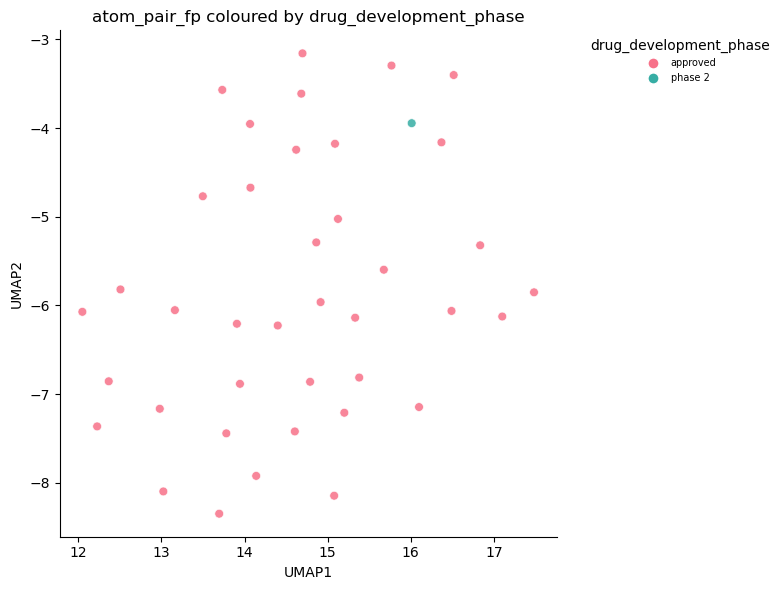

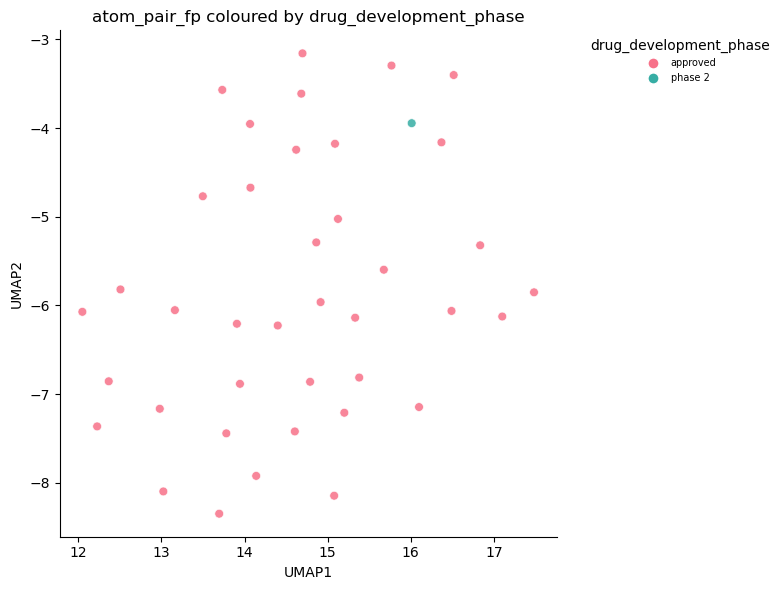

In [57]:
color_key = ("drug_development_phase"
             if dense_space.obs["drug_development_phase"].nunique() > 1
             else "drug_atc_level1")
best_space = PURITY_CLINICAL["family"].idxmax()

pl.plot_embedding_space(
    dense_space, obsm_key=f"X_{best_space}", color=color_key,
    method="umap", title=f"{best_space} coloured by {color_key}",
)

Two honest qualifications on that plot.

* **Forty points is not a manifold.** UMAP on forty compounds is a sketch, and
  its apparent clusters are not stable under reseeding. The
  [numbers](#does-the-embedding-know-the-clinical-record) are the evidence; the
  plot is orientation.
* **The colouring may be constant.** Every compound in this panel is approved,
  so if `drug_development_phase` has one value the cell falls back to ATC class
  rather than drawing a single-colour plot and calling it a result.

## Reading ChemBERTa's attention

The fingerprints in this notebook have no inside to look at. A Morgan bit is
set or it is not, and the mapping from substructure to bit is a hash -- there
is no intermediate representation to interrogate. The two ChemBERTa
checkpoints are transformers, so there is: one attention matrix per block, and
each row of it is a distribution over the tokens of the molecule.

That makes a specific question askable. *Which parts of a molecule does the
model look at when it builds its representation?* The cells below extract the
matrices, measure how focused each head is, and map the answer back onto the
SMILES string.

> **Structural, not causal.** Attention says what attends to what. It does not
> say what the model used to reach its output. Jain & Wallace (NAACL 2019,
> *Attention is not Explanation*) showed that attention weights can be
> substantially altered without changing predictions, so read what follows as
> a description of the architecture's routing, not as an explanation of its
> chemistry.

In [58]:
ATTN_MODEL = "chemberta2MTR"
ATTN_COMPOUND = "aspirin"

# Aspirin rather than one of the kinase inhibitors: 23 tokens fit on a plot
# axis and every one of them is legible as a substructure, which is the whole
# point of mapping attention back onto the string.
attn_smiles = mol_space.obs.loc[
    mol_space.obs["compound"] == ATTN_COMPOUND, "smiles"
].iloc[0]

wrapper = embedder.get_model(ATTN_MODEL)
tokens = wrapper.tokenizer(attn_smiles, return_tensors="pt")

# extract_attention takes tokenised `input_ids`, NOT the SMILES string. Passing
# the string raises `AttributeError: 'str' object has no attribute 'to'` from
# deep inside base.py, which is an unhelpful way to learn the signature.
attn = wrapper.extract_attention(
    tokens["input_ids"],
    attention_mask=tokens["attention_mask"],
    layers=None,          # every block; pass e.g. [-1] for just the last
)

token_labels = wrapper.tokenizer.convert_ids_to_tokens(tokens["input_ids"][0])
last = max(attn)

print(f"{ATTN_COMPOUND}: {attn_smiles}")
print(f"blocks returned: {sorted(attn)}")
print(f"block {last} shape: {tuple(attn[last].shape)}  (batch, heads, seq, seq)")
print(f"tokens ({len(token_labels)}): {token_labels}")

row_sums = attn[last].sum(-1).cpu().numpy()   # tensors come back on the model's device
print(f"rows are distributions: {bool(np.allclose(row_sums, 1.0, atol=1e-4))}")

aspirin: CC(=O)Oc1ccccc1C(=O)O
blocks returned: [0, 1, 2]
block 2 shape: (1, 12, 23, 23)  (batch, heads, seq, seq)
tokens (23): ['[CLS]', 'C', 'C', '(', '=', 'O', ')', 'O', 'c', '1', 'c', 'c', 'c', 'c', 'c', '1', 'C', '(', '=', 'O', ')', 'O', '[SEP]']
rows are distributions: True


Every query row sums to 1: each token distributes a fixed budget of attention
over the molecule.

> **Layer indexing.** `extract_attention` returns **one entry per transformer
> block** -- there is no embedding-layer entry, unlike `extract_hidden_states`
> where index 0 *is* the embedding layer. `tl.block_to_attention_index` and
> `tl.block_to_hidden_state_index` convert between the two conventions, and
> the [layer sweep](proteins.ipynb#which-layer-should-you-take) in the sibling
> [proteins](proteins.ipynb) notebook shows why the distinction matters.

Note how short the model is. `chemberta2MTR` has three blocks, against ESM-2's
thirty-three. A three-block model cannot build much hierarchy, and the entropy
curve below is correspondingly flat -- that is a property of this checkpoint,
not of chemical language models in general.

### How focused is each head, and does that change with depth?

Attention entropy is the obvious summary: a head attending uniformly over
`n` tokens has entropy `log(n)`, and a head attending to exactly one token has
entropy 0. The interesting quantity is not the absolute value but whether it
*falls* with depth, which is what specialisation looks like.

The prediction is that it barely moves here, because there are only three
blocks to move across. That is a prediction, and the cell below scores it
rather than assuming it.

In [59]:
uniform_entropy = float(np.log(len(token_labels)))

rows = []
for block in sorted(attn):
    entropy = tl.attention_entropy(attn[block])          # (batch, heads)
    uniformity = tl.head_uniformity(attn[block])         # (batch, heads)
    flat = np.ravel(entropy)
    rows.append({
        "block": block,
        "mean_entropy": float(flat.mean()),
        "min_entropy": float(flat.min()),
        "max_entropy": float(flat.max()),
        # Normalised against log(n_tokens) so the number is comparable across
        # molecules of different length, which raw entropy is not.
        "mean_frac_of_uniform": float(flat.mean() / uniform_entropy),
        "mean_uniformity": float(np.ravel(uniformity).mean()),
    })

entropy_by_block = pd.DataFrame(rows).set_index("block")
print(f"uniform-attention entropy for {len(token_labels)} tokens: "
      f"{uniform_entropy:.3f}")
display(entropy_by_block.round(3))

uniform-attention entropy for 23 tokens: 3.135


,mean_entropy,min_entropy,max_entropy,mean_frac_of_uniform,mean_uniformity
block,,,,,
0,1.324,0.072,2.892,0.422,0.732
1,1.408,0.306,2.725,0.449,0.727
2,2.990,2.324,3.112,0.954,0.171


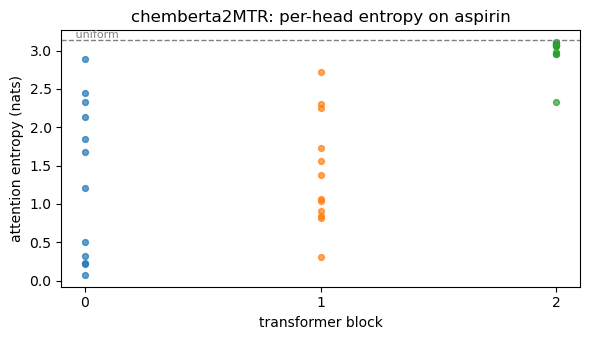

In [60]:
fig, ax = plt.subplots(figsize=(6, 3.5))
for block in sorted(attn):
    per_head = np.ravel(tl.attention_entropy(attn[block]))
    ax.scatter([block] * len(per_head), per_head, s=18, alpha=0.7,
               label=f"block {block}" if block == 0 else None)
ax.axhline(uniform_entropy, ls="--", lw=1, color="grey")
ax.text(0.02, uniform_entropy, " uniform", va="bottom", fontsize=8,
        color="grey", transform=ax.get_yaxis_transform())
ax.set_xlabel("transformer block")
ax.set_ylabel("attention entropy (nats)")
ax.set_xticks(sorted(attn))
ax.set_title(f"{ATTN_MODEL}: per-head entropy on {ATTN_COMPOUND}")
fig.tight_layout()
plt.show()

Each dot is one head. Read the spread rather than the mean: a block where every
head sits at the uniform line is doing no routing at all, and a block with a
wide spread has heads that disagree about what matters.

### Which parts of the molecule does the model read?

Entropy says how concentrated a head is. It does not say *where*. Summing
attention over query positions gives received attention per token -- how much
of the molecule's total attention budget each token attracts.

In [61]:
received = np.ravel(tl.received_attention(attn[last]))    # (batch, seq) -> (seq,)

received_table = pd.DataFrame({
    "position": np.arange(len(token_labels)),
    "token": token_labels,
    "received": received,
}).sort_values("received", ascending=False)

print(f"block {last}, top tokens by received attention:")
display(received_table.head(8).round(3))

block 2, top tokens by received attention:


,position,token,received
22,22,[SEP],0.124
1,1,C,0.058
13,13,c,0.048
12,12,c,0.048
11,11,c,0.048
10,10,c,0.048
15,15,1,0.047
14,14,c,0.047


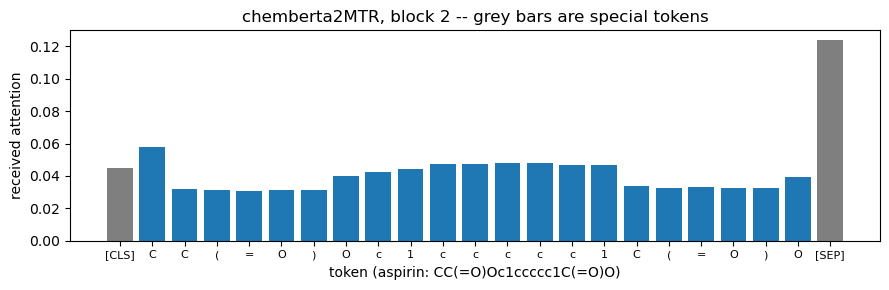

In [62]:
fig, ax = plt.subplots(figsize=(9, 3))
colours = ["tab:grey" if t.startswith("[") else "tab:blue" for t in token_labels]
ax.bar(np.arange(len(token_labels)), received, color=colours)
ax.set_xticks(np.arange(len(token_labels)))
ax.set_xticklabels(token_labels, fontsize=8)
ax.set_xlabel(f"token ({ATTN_COMPOUND}: {attn_smiles})")
ax.set_ylabel("received attention")
ax.set_title(f"{ATTN_MODEL}, block {last} -- grey bars are special tokens")
fig.tight_layout()
plt.show()

Two things to check before reading chemistry into this plot.

* **Special tokens absorb attention.** `[CLS]` and `[SEP]` are grey above. In
  most transformers they act as a sink, and a large `[CLS]` bar says more about
  the architecture than about the molecule. Since `"cls"` pooling is what
  produces the embedding used everywhere else in this notebook, that sink is
  not incidental -- it *is* the representation.
* **A token is not an atom.** For this character-level tokeniser they are
  nearly aligned, which is why aspirin is a readable example. The next
  subsection shows what happens when they are not.

### The same molecule through two tokenisers

`chemberta2MTR` and `chemberta2MLM` are both called ChemBERTa and both sit in
the same registry family, which makes it easy to assume they are the same
architecture trained two ways. They are not. They differ in depth, in width,
and -- most consequentially for anything token-level -- in how they cut a SMILES
string into tokens.

In [63]:
TOKENISER_PROBE = ["chemberta2MTR", "chemberta2MLM"]

rows = []
token_lists = {}
for key in TOKENISER_PROBE:
    w = embedder.get_model(key)
    pieces = w.tokenizer.tokenize(attn_smiles)
    token_lists[key] = pieces
    n_blocks = len(w.extract_attention(
        w.tokenizer(attn_smiles, return_tensors="pt")["input_ids"], layers=None,
    ))
    rows.append({
        "model": key,
        "n_tokens": len(pieces),
        "n_blocks": n_blocks,
        "embedding_dim": int(mol_space.obsm[f"X_{key}"].shape[1]),
        "first_8": " ".join(pieces[:8]),
    })

display(pd.DataFrame(rows).set_index("model"))
for key, pieces in token_lists.items():
    print(f"{key}: {pieces}")

,n_tokens,n_blocks,embedding_dim,first_8
model,,,,
chemberta2MTR,21,3,384,C C ( = O ) O c
chemberta2MLM,13,12,768,CC (= O ) Oc 1 ccccc 1


chemberta2MTR: ['C', 'C', '(', '=', 'O', ')', 'O', 'c', '1', 'c', 'c', 'c', 'c', 'c', '1', 'C', '(', '=', 'O', ')', 'O']
chemberta2MLM: ['CC', '(=', 'O', ')', 'Oc', '1', 'ccccc', '1', 'C', '(=', 'O', ')', 'O']


The MTR checkpoint splits aspirin one character at a time; the MLM checkpoint
uses a BPE vocabulary and merges `CC`, `(=`, `Oc` and `ccccc` into single
tokens. So a received-attention bar for the MLM model covers a *group* of
atoms, and the neat token-to-substructure reading of the previous plot does not
carry over.

They also differ in width -- 384 against 768 -- which is worth stating plainly
because "the same model, two objectives" is the natural assumption and it is
wrong. The two columns above are the evidence.

> **What this costs you.** Any attention analysis that maps back onto atoms is
> tokeniser-specific. Comparing received attention between two chemical
> language models is only meaningful if you first agree on what a position
> *is*, and for these two checkpoints there is no shared answer.

### Where MoLFormer would have gone

MoLFormer-XL uses a third scheme again -- an atom-level regex -- which would
have made a three-way tokeniser comparison. It is in the registry as
`molformer_base` and `list_available_models("molecule")` lists it, but it does
not load in this environment, and the sweep above already recorded that.

The reason is worth surfacing rather than hiding, because the error the user
sees is two layers away from the cause.

In [64]:
# The wrapper wraps the real ImportError in a RuntimeError, and `_get_model`
# wraps that in a ModelLoadError, so the message you get names neither the
# missing module nor the version constraint. Walk the __cause__ chain.
try:
    embedder.get_model("molformer_base")
    print("molformer_base loaded -- the three-way comparison is available")
except Exception as exc:
    chain = []
    cursor = exc
    while cursor is not None:
        chain.append(f"{type(cursor).__name__}: {str(cursor)[:80]}")
        cursor = cursor.__cause__
    for depth, entry in enumerate(chain):
        print(f"{'  ' * depth}{entry}")

ERROR:root:MolFormer load error: No module named 'transformers.masking_utils'


ERROR:root:Failed to load model 'molformer_base' using wrapper MolformerWrapper and path 'ibm/MoLFormer-XL-both-10pct': Could not load MolFormer 'ibm/MoLFormer-XL-both-10pct'


ModelLoadError: Failed to load model 'molformer_base': RuntimeError: Could not load MolFormer 'i
  RuntimeError: Could not load MolFormer 'ibm/MoLFormer-XL-both-10pct'
    ModuleNotFoundError: No module named 'transformers.masking_utils'


The root is `ModuleNotFoundError: No module named
'transformers.masking_utils'`. MoLFormer ships its modelling code on the Hub
and is loaded with `trust_remote_code=True`, so it runs against whatever
`transformers` the environment has; that module arrived in a later release than
the 4.48.1 pinned here for ESM compatibility. Remote code is a moving
dependency that your lockfile does not cover.

`MolformerWrapper.load` catches the failure and raises
`RuntimeError("Could not load MolFormer ...")` at
`src/embpy/models/molecule_models.py:287`, and `_get_model` turns that into
`ModelLoadError`. Both re-wraps preserve `__cause__`, which is why the chain
above is readable -- but only if you know to walk it.

### The attention-free wall

Six of the nine models in the sweep are fingerprints. Asking them for attention
is not a matter of a missing feature; there is no computation to inspect. embpy
declares that up front rather than failing at the tensor level.

In [65]:
print(f"RDKitWrapper.has_attention = "
      f"{embedder.get_model('morgan_fp', load=False).has_attention}")

# The failure is explanatory rather than a bare exception, and it arrives
# without loading weights -- has_attention is a class attribute, so the check
# happens before the load guard.
try:
    embedder.get_model("morgan_fp", load=False).extract_attention(
        np.zeros((1, 8), dtype="int64"), layers=[-1],
    )
except NotImplementedError as exc:
    print(f"\nNotImplementedError: {exc}")

RDKitWrapper.has_attention = False

NotImplementedError: RDKitWrapper wraps an architecture whose attention weights are not observable -- either it is attention-free (state-space, implicit convolution, graph message passing) or it computes attention with a fused kernel that never materialises the matrix. Use extract_hidden_states() for per-layer activations instead.


### Keeping `has_attention` honest

`has_attention` is only useful if a wrapper that claims attention can actually
produce it. `BaseModelWrapper` defaults it to `True`, so a subclass that never
overrides it inherits the claim whether or not the claim holds. The audit below
separates the two cases: which molecule wrappers *declare* the flag, and which
merely inherit it.

In [66]:
FLAG_ROSTER = ["morgan_fp", "maccs_fp", "chemberta2MTR", "chemberta2MLM",
               "molformer_base", "minimol", "mhg_gnn", "mole"]

# Is `has_attention` set anywhere below BaseModelWrapper, or only inherited?
def declared_by_subclass(cls, name: str) -> bool:
    return any(name in klass.__dict__ for klass in cls.__mro__
               if klass.__name__ != "BaseModelWrapper")

rows = []
for key in FLAG_ROSTER:
    try:
        w = embedder.get_model(key, load=False)
        cls = type(w)
        rows.append({"model": key, "wrapper": cls.__name__,
                     "has_attention": w.has_attention,
                     "flag_declared": declared_by_subclass(cls, "has_attention"),
                     "is_hf_model": cls.__name__ in {"ChembertaWrapper",
                                                     "MolformerWrapper"}})
    except Exception as exc:
        rows.append({"model": key, "wrapper": "-", "has_attention": None,
                     "flag_declared": None, "is_hf_model": None,
                     "wrapper_error": type(exc).__name__})

display(pd.DataFrame(rows).set_index("model"))

,wrapper,has_attention,flag_declared,is_hf_model
model,,,,
morgan_fp,RDKitWrapper,False,True,False
maccs_fp,RDKitWrapper,False,True,False
chemberta2MTR,ChembertaWrapper,True,False,True
chemberta2MLM,ChembertaWrapper,True,False,True
molformer_base,MolformerWrapper,True,False,True
minimol,MiniMolWrapper,False,True,False
mhg_gnn,MHGGNNWrapper,False,True,False
mole,MolEWrapper,True,False,False


The fingerprint and graph wrappers declare `False`, which is honest. The two
ChemBERTa wrappers inherit `True` and earn it -- the extraction above worked.

`mole` is the uncomfortable row. `MolEWrapper` inherits `has_attention = True`
without declaring it, and it is not a HuggingFace model, so
`extract_attention` would fall through to the forward-hook path rather than
`output_attentions=True`. The question is academic here only because the
wrapper cannot be constructed at all through `BioEmbedder` -- see the
[catalogue section](#which-molecule-models-does-embpy-have). An inherited
`True` on a non-HF wrapper is a claim nothing checks, and this table is how you
find those.

## Downstream: which model predicts a measured property?

Everything so far compared the spaces against each other, or against labels this
notebook wrote by hand. A benchmark asks a narrower question: given one of these
matrices, can a plain regressor recover a number that came from somewhere else?
`tl.benchmark_embeddings` trains four probes -- linear, ridge, k-NN and random
forest -- on an `.obsm` matrix and scores them against a numeric `.obs` column.

Choosing the target is the whole design, and for molecules it is easy to get
wrong in a way that produces a confident number and no information. Every
fingerprint in the roster is a **deterministic function of the SMILES string**.
So is `mol_qed`. So is `mol_molecular_weight`. Ask a Morgan fingerprint to
predict QED and you are asking whether one function of the SMILES can be
recovered from another function of the same SMILES -- a question about RDKit,
not about chemistry. A high score there is the expected result and means
nothing about whether the embedding is useful.

| Target | Where it came from | Circular? | Prior expectation |
| --- | --- | --- | --- |
| `drug_best_pchembl` | the strongest measured potency across the compound's curated ChEMBL protein targets | no -- it is assay data, and no model in the roster has seen it | **the real test.** Nothing about a bit vector implies a binding constant, so a positive score is evidence and a negative one is honest |
| `mol_qed` | RDKit's QED, computed from the same SMILES the fingerprints were computed from | **yes** | **the fingerprints should win, and it proves nothing.** It is here as a calibration: it shows what "this space encodes the structure faithfully" looks like as a number, so the potency column can be read against it |

Two predictions, then, and the cells below score both. The interesting quantity
is not either score on its own but the **gap** between them. A space that
reproduces its own input and cannot touch the measurement is doing exactly what
a structural descriptor is supposed to do; a space that closes some of that gap
has learned something the structure alone does not say.

R2 is on the standard scale where 0 means "no better than predicting the mean",
and **negative values mean worse than that**. A model scoring below zero on a
target it has no path to is the correct answer, not a broken run.

In [67]:
BENCH_TARGET_COLS = ["drug_best_pchembl", "mol_qed"]

# The annotation section wrote its mol_* and drug_* columns onto whichever object it
# ran on. Prefer the dense subset, because every cross-model number in this notebook
# is computed there and a benchmark on a different row set would not be comparable;
# fall back to the full space when only that one carries the columns.
def _n_targets_present(space) -> int:
    return sum(1 for col in BENCH_TARGET_COLS if col in space.obs.columns)


if _n_targets_present(dense_space) >= _n_targets_present(mol_space):
    bench_space, bench_space_name = dense_space, "dense_space"
else:
    bench_space, bench_space_name = mol_space, "mol_space"

# Read the roster that actually produced matrices rather than iterating .obsm: the
# plots in the visual-comparison section parked 2-d UMAP and PCA coordinates in
# .obsm too, and a projection of a model is not a model. Benchmarking those would
# manufacture rows that look like results.
bench_spaces = {key: f"X_{key}" for key in SWEEP if f"X_{key}" in bench_space.obsm}


def space_kind(key: str) -> str:
    # Every fingerprint registry key ends in _fp; the learned models do not. That is
    # the split the whole notebook is stated in, so it is worth naming once.
    return "fingerprint" if key.endswith("_fp") else "learned"


inventory = pd.DataFrame([
    {"model": key, "obsm_key": obsm, "kind": space_kind(key),
     "dim": int(np.asarray(bench_space.obsm[obsm]).shape[1]),
     "finite_rows": int(np.isfinite(
         np.asarray(bench_space.obsm[obsm], dtype=float)).all(axis=1).sum())}
    for key, obsm in bench_spaces.items()
]).set_index("model")

ignored = sorted(set(bench_space.obsm) - set(bench_spaces.values()))
print(f"benchmarking on {bench_space_name}: {bench_space.n_obs} compounds, "
      f"{len(bench_spaces)} model spaces")
print(f"target columns present: "
      f"{[c for c in BENCH_TARGET_COLS if c in bench_space.obs.columns] or 'none'}")
if ignored:
    print(f"ignored (derived coordinates, not embeddings): {ignored}")
display(inventory)

# A target is only usable if it is numeric, varies, and covers enough compounds to
# split. drug_best_pchembl is the one that will thin out -- a compound with no
# curated activity has no pChEMBL -- so the count is printed rather than assumed.
MIN_ROWS = 16          # under a 0.25 split this is four test points; less is not a score

BENCH_TARGETS: list[tuple[str, str]] = []      # (column, "measured" | "circular")
for col, role in [("drug_best_pchembl", "measured"), ("mol_qed", "circular")]:
    if col not in bench_space.obs.columns:
        print(f"{col}: not in .obs -- the {role} half of the comparison goes unscored")
        continue
    values = pd.to_numeric(bench_space.obs[col], errors="coerce")
    n_ok, n_distinct = int(values.notna().sum()), int(values.nunique(dropna=True))
    if n_ok < MIN_ROWS or n_distinct < 3:
        print(f"{col}: present but not usable ({n_ok} numeric values, "
              f"{n_distinct} distinct) -- skipped")
        continue
    BENCH_TARGETS.append((col, role))
    print(f"{col:<20} {role:<9} {n_ok}/{bench_space.n_obs} compounds, "
          f"{n_distinct} distinct, range "
          f"{values.min():.2f} to {values.max():.2f}")

if not BENCH_TARGETS:
    print("\nno usable target -- the benchmark below will report that and skip")

benchmarking on dense_space: 40 compounds, 8 model spaces
target columns present: ['drug_best_pchembl', 'mol_qed']
ignored (derived coordinates, not embeddings): ['X_pca_X_atom_pair_fp', 'X_pca_X_chemberta2MLM', 'X_pca_X_chemberta2MTR', 'X_pca_X_maccs_fp', 'X_pca_X_morgan_count_fp', 'X_pca_X_morgan_fp', 'X_pca_X_rdkit_fp', 'X_pca_X_torsion_fp', 'X_umap', 'X_umap_X_atom_pair_fp']


,obsm_key,kind,dim,finite_rows
model,,,,
maccs_fp,X_maccs_fp,fingerprint,167,40
morgan_fp,X_morgan_fp,fingerprint,2048,40
morgan_count_fp,X_morgan_count_fp,fingerprint,2048,40
rdkit_fp,X_rdkit_fp,fingerprint,2048,40
atom_pair_fp,X_atom_pair_fp,fingerprint,2048,40
torsion_fp,X_torsion_fp,fingerprint,2048,40
chemberta2MTR,X_chemberta2MTR,learned,384,40
chemberta2MLM,X_chemberta2MLM,learned,768,40


drug_best_pchembl    measured  40/40 compounds, 34 distinct, range 6.68 to 10.80
mol_qed              circular  40/40 compounds, 39 distinct, range 0.16 to 0.88


In [68]:
benchmarks: dict[tuple[str, str], pd.DataFrame] = {}
rows_used: dict[tuple[str, str], int] = {}

for target, _role in BENCH_TARGETS:
    y = pd.to_numeric(bench_space.obs[target], errors="coerce").to_numpy(dtype=float)
    for key, obsm_key in bench_spaces.items():
        matrix = np.asarray(bench_space.obsm[obsm_key], dtype=float)
        # A single NaN reaching a regressor is a crash, not a low score, so the mask
        # is over the target and the whole embedding row together.
        ok = np.isfinite(matrix).all(axis=1) & np.isfinite(y)
        if int(ok.sum()) < MIN_ROWS:
            print(f"{target} / {key}: only {int(ok.sum())} complete compounds -- skipped")
            continue
        sub = bench_space[ok].copy()
        sub.obs[target] = y[ok]                  # force a plain float column
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                benchmarks[(target, key)] = tl.benchmark_embeddings(
                    sub, perturbation_column="compound", perturbation_type="chemical",
                    target=target, obsm_key=obsm_key,
                    models=["linear", "ridge", "knn", "random_forest"],
                    mode="quick", test_size=0.25, random_state=0,
                )
            rows_used[(target, key)] = int(ok.sum())
        except Exception as exc:
            print(f"{target} / {key}: skipped -- {type(exc).__name__}: {str(exc)[:70]}")

best_r2 = pd.DataFrame({
    target: {key: benchmarks[(target, key)]["r2"].max()
             for key in bench_spaces if (target, key) in benchmarks}
    for target, _role in BENCH_TARGETS
}).dropna(how="all")

if best_r2.empty:
    print("\nno benchmark completed")
else:
    best_r2.insert(0, "kind", [space_kind(k) for k in best_r2.index])
    print("\nbest R2 over the four probes (rows = model, columns = target)")
    display(best_r2.round(3))

    counts = pd.DataFrame({
        target: {key: rows_used[(target, key)]
                 for key in bench_spaces if (target, key) in rows_used}
        for target, _role in BENCH_TARGETS
    }).dropna(how="all")
    if not counts.empty:
        spread = counts.stack().unique()
        if len(spread) == 1:
            print(f"every cell used the same {int(spread[0])} compounds")
        else:
            print("compounds used per cell -- these differ, so the columns are not "
                  "strictly comparable:")
            display(counts)


best R2 over the four probes (rows = model, columns = target)


,kind,drug_best_pchembl,mol_qed
maccs_fp,fingerprint,0.120,0.028
morgan_fp,fingerprint,0.219,0.033
morgan_count_fp,fingerprint,0.227,0.614
rdkit_fp,fingerprint,0.175,0.172
atom_pair_fp,fingerprint,0.274,0.651
torsion_fp,fingerprint,0.316,0.212
chemberta2MTR,learned,0.174,0.283
chemberta2MLM,learned,0.232,0.444


every cell used the same 40 compounds


,best_r2,best_model,worst_r2,below_zero,n_scored
drug_best_pchembl,0.316,torsion_fp,0.120,0,8
mol_qed,0.651,atom_pair_fp,0.028,0,8


mean best-R2 by model family



,drug_best_pchembl,mol_qed
kind,,
fingerprint,0.222,0.285
learned,0.203,0.363


  drug_best_pchembl    [measured] real signal (R2=0.316, torsion_fp)
  mol_qed              [circular] real signal (R2=0.651, atom_pair_fp)

best R2 0.651 on mol_qed (a function of the input SMILES) against 0.316 on drug_best_pchembl (measured potency): the spaces reproduce their own input better than they predict the assay
all four probes for atom_pair_fp predicting mol_qed (40 compounds, 10 held out):


,mse,r2,pearson,spearman,delta_l2_mae,delta_l2_pearson
model,,,,,,
linear,0.010,0.610,0.799,0.648,NaN,NaN
ridge,0.010,0.613,0.801,0.648,NaN,NaN
knn,0.036,-0.369,0.390,0.182,NaN,NaN
random_forest,0.009,0.651,0.836,0.770,NaN,NaN


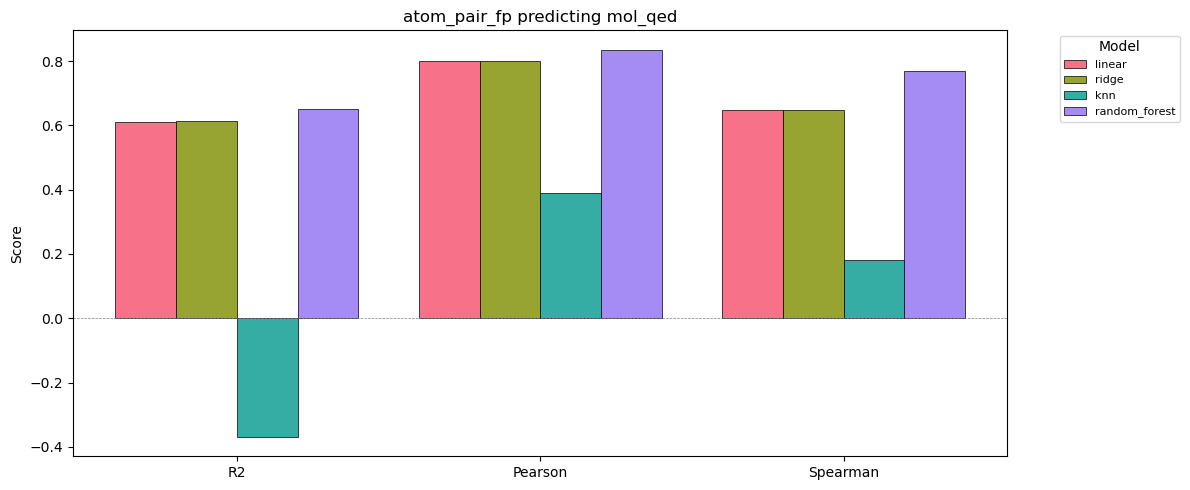

In [69]:
# A positive R2 is not automatically signal. The panel is 40 compounds and a 0.25
# split leaves a single-digit test set, so anything near zero is noise. Tier the
# verdict rather than reporting "beats the mean"; the thresholds are a judgement
# call, written here so they can be argued with.
SIGNAL, NOISE = 0.30, 0.10

BENCH_VERDICT = "the benchmark did not run"
if not best_r2.empty:
    scores = best_r2.drop(columns=["kind"])
    per_target = pd.DataFrame({
        "best_r2": scores.max(),
        "best_model": scores.idxmax(),
        "worst_r2": scores.min(),
        "below_zero": (scores < 0).sum(),
        "n_scored": scores.notna().sum(),
    })
    display(per_target.round(3))

    print("mean best-R2 by model family\n")
    display(scores.groupby(best_r2["kind"]).mean().round(3))

    for target, role in BENCH_TARGETS:
        if target not in scores.columns:
            continue
        r2, model = per_target.loc[target, "best_r2"], per_target.loc[target, "best_model"]
        if r2 >= SIGNAL:
            tier = f"real signal (R2={r2:.3f}, {model})"
        elif r2 >= NOISE:
            tier = f"at the noise floor (R2={r2:.3f}, {model}) -- not a usable predictor"
        else:
            tier = f"nothing usable (best R2={r2:.3f}, {model})"
        print(f"  {target:<20} [{role}] {tier}")

    # The comparison the section exists for: how much of the circular target's score
    # does the measured target recover? Anything close to parity would be surprising.
    circular = [t for t, r in BENCH_TARGETS if r == "circular" and t in scores.columns]
    measured = [t for t, r in BENCH_TARGETS if r == "measured" and t in scores.columns]
    if circular and measured:
        c, m = scores[circular[0]].max(), scores[measured[0]].max()
        BENCH_VERDICT = (
            f"best R2 {c:.3f} on {circular[0]} (a function of the input SMILES) "
            f"against {m:.3f} on {measured[0]} (measured potency): the spaces "
            f"reproduce their own input {'far ' if c - m > 0.4 else ''}better than "
            f"they predict the assay"
        )
        print(f"\n{BENCH_VERDICT}")
    else:
        BENCH_VERDICT = (
            "only one side of the circular / measured contrast was scoreable, so the "
            "gap this section is about could not be measured"
        )
        print(f"\n{BENCH_VERDICT}")

# Full per-probe detail for the single best (target, model) pair. The four rows are
# the point: a random forest beating linear by a wide margin says the relationship
# is non-linear, not that the embedding is good.
if benchmarks and not best_r2.empty:
    _scores = best_r2.drop(columns=["kind"])
    top_target = _scores.max().idxmax()
    top_model = _scores[top_target].idxmax()
    n = rows_used[(top_target, top_model)]
    print(f"all four probes for {top_model} predicting {top_target} "
          f"({n} compounds, {int(round(0.25 * n))} held out):")
    display(benchmarks[(top_target, top_model)].round(3))
    pl.plot_benchmark(benchmarks[(top_target, top_model)],
                      title=f"{top_model} predicting {top_target}")

**Read the baseline first, then the winner.** `benchmark_embeddings` trains a
plain linear probe alongside the rest. If a space's best result is no better than
a linear read of its own vectors, the extra machinery bought nothing for this
task.

**Treat these numbers as a demonstration, not a benchmark result.** Forty
compounds, a 25% split and a single random seed leave a test set you can count on
one hand, so the ordering between two close models is not information. Only the
gap between a model above the signal threshold and one below zero is. For a real
decision use `mode="rigorous"` -- 5-fold cross-validation with a randomised
hyper-parameter search -- and hold out whole **scaffold** groups rather than
random rows, because the two congeneric families in this panel make random
splitting far too easy: a held-out statin has seven near-twins in the training
set.

Three caveats, all of which bound how far this can be pushed:

* **`drug_best_pchembl` is a curation artefact as much as a measurement.** It is
  the best pChEMBL over whatever assays happen to be in ChEMBL for that compound.
  A heavily studied kinase inhibitor has thousands of measurements and a high
  maximum; an old NSAID has a handful. Some of any score here is "how much has
  this compound been assayed", which correlates with family membership and so
  with structure.
* **The circular target is not a straw man.** Reproducing a physicochemical
  property from a fingerprint is genuinely useful when the property is expensive
  to compute or measure. It stops being useful the moment you present it as
  evidence about biology, which is the mistake this section is built to make
  visible.
* **The probes see raw bits.** Nothing here standardises or reduces the 2048-d
  binary spaces, so ridge and k-NN are working in a very sparse geometry.
  `reduce_dim` applies PCA first and would change these numbers; it is left off so
  the input is the same matrix every other section measured.

`tl` also carries `phenotypic_activity` and the perturbation-screen readouts
(`delta_l2`, `deg_overlap`, `phenocopy_score`). Those need a screen -- a control
column, and a measured response per compound -- which a panel of 40 identifiers
does not have, so they live in [cells](cells.ipynb).

## Molecule-only: a fingerprint bit is not a feature

This is the one thing a molecular fingerprint has that no other embedding in
embpy does: **every dimension has a name you can draw.** Bit 314 of a Morgan
fingerprint is not an abstract coordinate; it is a hash bucket, and RDKit will
tell you which atom environments landed in it.

That makes a specific kind of debugging possible. When a purity number in the
[interpretation section](#does-the-geometry-track-biology) says a space separates
the statins, you can ask *on what* -- and get an answer that is a substructure
rather than a plausible story.

The cell below re-derives the Morgan matrix with `AdditionalOutput` attached,
because `RDKitWrapper._compute_fingerprint` calls
`GetMorganGenerator(radius=2, fpSize=2048).GetFingerprintAsNumPy(mol)` and throws
the bit-info map away. Re-deriving means the numbers could disagree with the
matrix every other section measured, so the cell checks that they do not instead
of assuming it. Two things could break the agreement: a different generator
configuration, and `embed()` having canonicalised the SMILES differently from
what is sitting in `.obs["smiles"]`.

Bits are then ranked by how sharply they separate one panel family from the rest
-- prevalence inside the family minus prevalence outside it. That is a deliberate
choice over ranking by variance: a high-variance bit is common, and a common
substructure is not an explanation.

In [70]:
from rdkit import Chem, RDLogger
from rdkit.Chem import rdFingerprintGenerator

RDLogger.DisableLog("rdApp.*")

MORGAN_RADIUS, MORGAN_BITS = 2, 2048      # exactly RDKitWrapper's defaults

# Shared by the three molecule-only sections below: the full 40-compound panel,
# because celecoxib and rofecoxib must both be present for the scaffold test and
# the dense intersection might have dropped one of them.
PANEL_SPACES = {key: f"X_{key}" for key in SWEEP if f"X_{key}" in mol_space.obsm}
COMPOUND_ROW = {str(name): i for i, name in enumerate(mol_space.obs["compound"])}

panel_smiles = [str(s) for s in mol_space.obs["smiles"]]
panel_family = mol_space.obs["family"].astype(str).to_numpy()

_gen = rdFingerprintGenerator.GetMorganGenerator(
    radius=MORGAN_RADIUS, fpSize=MORGAN_BITS)
morgan_bits = np.zeros((len(panel_smiles), MORGAN_BITS), dtype=np.float32)
bit_atoms: list[dict] = []
parsed = 0
for i, smiles in enumerate(panel_smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        bit_atoms.append({})
        continue
    extra = rdFingerprintGenerator.AdditionalOutput()
    extra.AllocateBitInfoMap()
    morgan_bits[i] = _gen.GetFingerprintAsNumPy(mol, additionalOutput=extra)
    bit_atoms.append(dict(extra.GetBitInfoMap()))
    parsed += 1

print(f"re-derived Morgan bits for {parsed}/{len(panel_smiles)} panel SMILES")
if "X_morgan_fp" in mol_space.obsm:
    swept = np.asarray(mol_space.obsm["X_morgan_fp"], dtype=float)
    finite = np.isfinite(swept).all(axis=1)
    agree = bool(np.array_equal(swept[finite], morgan_bits[finite]))
    print(f"identical to the swept X_morgan_fp on its {int(finite.sum())} finite rows: "
          f"{agree}")
    if not agree:
        n_diff = int((swept[finite] != morgan_bits[finite]).any(axis=1).sum())
        print(f"  {n_diff} row(s) differ -- read the bit table below as descriptive of "
              "this re-derivation, not of the swept matrix")
else:
    print("X_morgan_fp is not in .obsm, so there is nothing to check the "
          "re-derivation against")

re-derived Morgan bits for 40/40 panel SMILES


identical to the swept X_morgan_fp on its 40 finite rows: True


In [71]:
# Rank bits by family specificity: prevalence inside one family minus prevalence
# outside it. Bits on in almost every compound or almost none are excluded first --
# a substructure shared by 39 of 40 compounds explains no separation.
on_counts = morgan_bits.sum(axis=0)
candidates = np.where((on_counts >= 2) & (on_counts <= len(panel_smiles) - 2))[0]
families = sorted(set(panel_family))

scored = []
for bit in candidates:
    column = morgan_bits[:, bit]
    for family in families:
        inside = panel_family == family
        delta = float(column[inside].mean() - column[~inside].mean())
        scored.append((delta, int(bit), family))
scored.sort(reverse=True)


def bit_substructure(smiles: str, atom_idx: int, radius: int) -> str:
    # Radius 0 is a single atom, and FindAtomEnvironmentOfRadiusN returns an empty
    # bond path for it, so PathToSubmol would hand back an empty molecule. Name the
    # atom directly in that case rather than printing a blank cell.
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return "unparseable"
    if radius == 0:
        atom = mol.GetAtomWithIdx(atom_idx)
        aromatic = " aromatic" if atom.GetIsAromatic() else ""
        return f"single{aromatic} {atom.GetSymbol()}, degree {atom.GetDegree()}"
    env = Chem.FindAtomEnvironmentOfRadiusN(mol, radius, atom_idx)
    submol = Chem.PathToSubmol(mol, env)
    if submol.GetNumAtoms() == 0:
        return "-"
    try:
        return Chem.MolToSmarts(submol)
    except Exception:
        return "unrenderable"


rows, seen_bits = [], set()
for delta, bit, family in scored:
    if bit in seen_bits:
        continue
    seen_bits.add(bit)
    # Any compound carrying the bit will do to decode it; the first one in the
    # marked family keeps the substructure and the label in the same molecule.
    owner = next((i for i in range(len(panel_smiles))
                  if morgan_bits[i, bit] and panel_family[i] == family
                  and bit in bit_atoms[i]), None)
    if owner is None:
        continue
    atom_idx, radius = list(bit_atoms[owner][bit])[0]
    inside = panel_family == family
    rows.append({
        "bit": bit, "marks": family,
        "in_family": float(morgan_bits[inside, bit].mean()),
        "elsewhere": float(morgan_bits[~inside, bit].mean()),
        "delta": delta, "radius": int(radius),
        "decoded_from": str(mol_space.obs["compound"].iloc[owner]),
        "substructure": bit_substructure(panel_smiles[owner], atom_idx, radius),
    })
    if len(rows) == 8:
        break

bit_table = pd.DataFrame(rows).set_index("bit")
print(f"{len(candidates)} of {MORGAN_BITS} bits are on in 2 to "
      f"{len(panel_smiles) - 2} compounds; the eight most family-specific:")
display(bit_table.round(3))

297 of 2048 bits are on in 2 to 38 compounds; the eight most family-specific:


,marks,in_family,elsewhere,delta,radius,decoded_from,substructure
bit,,,,,,,
680,statin,1.000,0.000,1.000,1,atorvastatin,[#6](-[#6@@H])-[#6@@H]
606,beta_blocker,1.000,0.000,1.000,1,propranolol,[#7]-[#6]-[#6]
724,benzodiazepine,0.875,0.000,0.875,1,diazepam,[#7]=[#6](-[#6])-[#6]
430,beta_blocker,0.875,0.000,0.875,2,propranolol,[#7]-[#6]-[#6](-[#8])-[#6]-[#8]
165,benzodiazepine,0.875,0.000,0.875,2,diazepam,[#6]:[#6]:[#6](-[#17]):[#6]:[#6]
118,beta_blocker,0.875,0.000,0.875,1,propranolol,[#6]-[#6]-[#8]
816,benzodiazepine,0.875,0.031,0.844,2,diazepam,[#6]:[#6](-[#17]):[#6]:[#6]:[#6]
227,beta_blocker,1.000,0.156,0.844,1,propranolol,[#6]-[#8]


In [72]:
# The contrast. Score the learned spaces' dimensions by exactly the same family
# criterion, then ask the same question of the winner -- which substructure is it?
learned_keys = [k for k in PANEL_SPACES if space_kind(k) == "learned"]
if not learned_keys:
    print("no learned space survived the sweep, so there is nothing to contrast "
          "the decoded bits against")
else:
    learned_key = learned_keys[0]
    matrix = np.asarray(mol_space.obsm[PANEL_SPACES[learned_key]], dtype=float)
    finite = np.isfinite(matrix).all(axis=1)
    matrix, fam = matrix[finite], panel_family[finite]

    # Standardised difference of means, so dimensions on different scales compare.
    best = (0.0, None, None)
    for family in sorted(set(fam)):
        inside = fam == family
        if inside.sum() < 2 or (~inside).sum() < 2:
            continue
        spread = matrix.std(axis=0)
        effect = np.abs(matrix[inside].mean(axis=0) - matrix[~inside].mean(axis=0))
        effect = effect / np.where(spread > 0, spread, np.inf)
        dim = int(np.argmax(effect))
        if effect[dim] > best[0]:
            best = (float(effect[dim]), dim, family)

    effect, dim, family = best
    column = matrix[:, dim]
    wrapper = embedder.get_model(learned_key, load=False)
    print(f"{learned_key}: dimension {dim} separates '{family}' most sharply "
          f"(standardised difference {effect:.2f})")
    print(f"  values run {column.min():.3f} to {column.max():.3f}; "
          f"{int((column != 0).sum())}/{len(column)} compounds are non-zero")
    print(f"  has_attention = {wrapper.has_attention}, declared on "
          f"{type(wrapper).__name__} itself: "
          f"{'has_attention' in type(wrapper).__dict__}")
    print("  bit-info equivalent on the wrapper: "
          f"{[a for a in dir(wrapper) if 'bit' in a.lower()] or 'none'}")

chemberta2MTR: dimension 120 separates 'benzodiazepine' most sharply (standardised difference 2.10)
  values run -0.648 to 1.263; 40/40 compounds are non-zero
  has_attention = True, declared on ChembertaWrapper itself: False
  bit-info equivalent on the wrapper: none


Read the two cells against each other rather than separately.

The bit table names substructures. A row saying bit *b* is on in every statin and
no benzodiazepine, decoded as a SMARTS you can look at, is a *mechanical*
explanation of a purity score: the space separates those compounds because they
share that fragment. Nothing about it is a claim, and nothing about it needed a
narrative.

The learned dimension has the same statistics and no such reading. Every compound
has a value, the value is signed and continuous, and the wrapper exposes no map
from dimension to structure -- because there is not one. Dimension 137 of
ChemBERTa is a direction in a space shaped by a masked-language objective over
millions of SMILES strings; asking which fragment it encodes presumes an
alignment between dimensions and chemistry that training never imposed.

> **`has_attention` here is inherited, not declared.** It defaults to `True` on
> `BaseModelWrapper` and the transformer molecule wrappers do not override it,
> which is why the check above prints `False` for the fact that the class declares
> it. `RDKitWrapper` *does* declare `has_attention = False`, and it is the one
> wrapper in this notebook whose dimensions are interpretable. Do not read the
> flag as a promise about interpretability in either direction; this notebook runs
> no attention extraction, and [06_attention_weights](06_attention_weights.ipynb)
> covers the extract-then-summarise pattern properly.

The practical consequence is a division of labour, not a ranking. When you need
to defend a hit to a chemist, a fingerprint gives you a fragment to point at. When
you need a representation that can put two unrelated scaffolds near each other,
that same literalness is the problem -- which is exactly what the next section
tests.

## Molecule-only: scaffold hopping

Here is the single cleanest structure-versus-mechanism test available in this
panel. Celecoxib and rofecoxib are both selective COX-2 inhibitors -- same
enzyme, same selectivity story, same withdrawal-era literature -- built on
completely different cores: a pyrazole bearing a sulfonamide against a furanone.
A screen that found one and missed the other found half the mechanism.

So: does any space in the roster put them next to each other?

The prediction from [part 1](#a-panel-where-structure-and-mechanism-disagree) is
that the fingerprints will not, because there is very little shared substructure
to hash, and that a learned representation *might*, because it was trained on
SMILES strings in a context where those two molecules keep appearing in the same
company. Two controls keep that honest:

* **imatinib and nilotinib** share the phenylaminopyrimidine core outright.
  Nilotinib was designed as an imatinib analogue. Any method that cannot call
  these two neighbours is broken, so this row calibrates the scale rather than
  testing anything.
* **aspirin and naproxen** are a second hop inside the NSAID family: a salicylate
  ester against a propionic acid, shared mechanism, almost no shared skeleton.

The scaffolds are asserted above and measured below -- Murcko scaffolds and the
Morgan Tanimoto for each pair, so "different scaffold" is a number in the output
rather than a claim in the prose.

In [73]:
from rdkit.Chem.Scaffolds import MurckoScaffold

HOP_PAIRS = [
    ("celecoxib", "rofecoxib", "same target, different scaffold"),
    ("aspirin", "naproxen", "same mechanism, different scaffold"),
    ("imatinib", "nilotinib", "shared core -- the control"),
]


def murcko(smiles: str) -> str:
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return "unparseable"
    return Chem.MolToSmiles(MurckoScaffold.GetScaffoldForMol(mol))


scaffold_rows = []
for a, b, note in HOP_PAIRS:
    if a not in COMPOUND_ROW or b not in COMPOUND_ROW:
        print(f"{a}/{b}: one of the pair is not in the panel -- skipped")
        continue
    ia, ib = COMPOUND_ROW[a], COMPOUND_ROW[b]
    va, vb = morgan_bits[ia] > 0, morgan_bits[ib] > 0
    union = int((va | vb).sum())
    scaffold_rows.append({
        "pair": f"{a} / {b}", "note": note,
        "same_family": panel_family[ia] == panel_family[ib],
        "morgan_tanimoto": (int((va & vb).sum()) / union) if union else np.nan,
        "same_murcko": murcko(panel_smiles[ia]) == murcko(panel_smiles[ib]),
        "scaffold_a": murcko(panel_smiles[ia]),
        "scaffold_b": murcko(panel_smiles[ib]),
    })

display(pd.DataFrame(scaffold_rows).set_index("pair").round(3))

,note,same_family,morgan_tanimoto,same_murcko,scaffold_a,scaffold_b
pair,,,,,,
celecoxib / rofecoxib,"same target, different scaffold",True,0.180,False,c1ccc(-c2ccnn2-c2ccccc2)cc1,O=C1OCC(c2ccccc2)=C1c1ccccc1
aspirin / naproxen,"same mechanism, different scaffold",True,0.205,False,c1ccccc1,c1ccc2ccccc2c1
imatinib / nilotinib,shared core -- the control,True,0.517,False,O=C(Nc1cccc(Nc2nccc(-c3cccnc3)n2)c1)c1ccc(CN2C...,O=C(Nc1cccc(-n2ccnc2)c1)c1cccc(Nc2nccc(-c3cccn...


In [74]:
def cosine_similarities(matrix: np.ndarray, row: int) -> np.ndarray:
    # Normalise once and take a dot product. A zero-norm row would otherwise divide
    # by zero, and an all-zero fingerprint is possible for a very small molecule.
    norms = np.linalg.norm(matrix, axis=1, keepdims=True)
    unit = matrix / np.where(norms > 0, norms, 1.0)
    return unit @ unit[row]


hop_rows = []
for key, obsm_key in PANEL_SPACES.items():
    matrix = np.asarray(mol_space.obsm[obsm_key], dtype=float)
    finite = np.isfinite(matrix).all(axis=1)
    sub = matrix[finite]
    # Row indices shift once NaN rows are dropped, so carry the compound names along.
    names = [str(n) for n in mol_space.obs["compound"][finite]]
    local = {name: i for i, name in enumerate(names)}
    for a, b, _note in HOP_PAIRS:
        if a not in local or b not in local:
            continue
        sims = cosine_similarities(sub, local[a])
        order = [names[i] for i in np.argsort(-sims) if names[i] != a]
        hop_rows.append({
            "space": key, "kind": space_kind(key), "pair": f"{a} / {b}",
            "cosine": float(sims[local[b]]),
            "rank": order.index(b) + 1, "of": len(order),
            "nearest": order[0],
        })

hop = pd.DataFrame(hop_rows)
if hop.empty:
    print("no space carried both members of any pair -- nothing to report")
else:
    print("rank of the second compound in the first one's neighbour list "
          "(1 = nearest; lower is better)\n")
    ranks = hop.pivot(index="space", columns="pair", values="rank")
    ranks.insert(0, "kind", [space_kind(k) for k in ranks.index])
    display(ranks)

    print("\nand what each space actually calls the nearest neighbour:")
    display(hop.pivot(index="space", columns="pair", values="nearest"))

rank of the second compound in the first one's neighbour list (1 = nearest; lower is better)



pair,kind,aspirin / naproxen,celecoxib / rofecoxib,imatinib / nilotinib
space,,,,
atom_pair_fp,fingerprint,1,1,2
chemberta2MLM,learned,3,29,14
chemberta2MTR,learned,4,17,7
maccs_fp,fingerprint,1,5,1
morgan_count_fp,fingerprint,15,1,1
morgan_fp,fingerprint,2,1,1
rdkit_fp,fingerprint,7,19,1
torsion_fp,fingerprint,19,4,1



and what each space actually calls the nearest neighbour:


pair,aspirin / naproxen,celecoxib / rofecoxib,imatinib / nilotinib
space,,,
atom_pair_fp,naproxen,rofecoxib,dasatinib
chemberta2MLM,ibuprofen,imatinib,celecoxib
chemberta2MTR,indomethacin,imatinib,metoprolol
maccs_fp,naproxen,rosuvastatin,nilotinib
morgan_count_fp,atorvastatin,rofecoxib,nilotinib
morgan_fp,propranolol,rofecoxib,nilotinib
rdkit_fp,labetalol,atorvastatin,nilotinib
torsion_fp,propranolol,indomethacin,nilotinib


Three readings, and the third is the one worth carrying out of this notebook.

**The control row is the sanity check.** Imatinib and nilotinib should be at or
near rank 1 in every space. Where they are not, that space is not measuring
structure in any recognisable sense and its other two columns cannot be
interpreted.

**The hop rows are the result.** A rank near 1 means the space put two molecules
with almost no shared substructure next to each other; a rank in the twenties or
thirties means it did not. Compare the fingerprint rows against the learned rows
directly -- the `kind` column is there for exactly that -- and note that the
learned models are not guaranteed to win. A masked-language model trained on
SMILES is still reading strings, and two different scaffolds are two different
strings.

**A rank is not a mechanism.** Even a space that scores well here has not
discovered that both compounds inhibit COX-2. At best it has learned that
molecules of this kind co-occur in its training corpus, which is a fact about the
literature. The honest way to get mechanism into the geometry is to put it there:
annotate the compounds, as the [clinical record](#the-clinical-record) section
does, and use the annotation as the label rather than hoping the structure
implies it.

## Molecule-only: ChEMBL analogs vs embedding neighbours

`ChEMBLAnnotator.get_analogs` runs a Tanimoto similarity search over the whole of
ChEMBL -- roughly two million distinct compounds -- and returns the closest
matches above a similarity floor. The embedding neighbour lists in the
[local-neighbourhoods section](#2-local-neighbourhoods) rank the 39 other members
of this panel. Both produce a list of similar molecules and they answer completely
different questions:

| | `get_analogs` | embedding neighbours |
| --- | --- | --- |
| Search space | all of ChEMBL | the 40 compounds you chose |
| Similarity | Morgan Tanimoto, computed server-side | cosine in whichever space you ask |
| Answers | *what else in the world looks like this* | *what in my screen looks like this* |
| Fails when | your compound is not in ChEMBL | your panel has no relative of the query |

The comparison below is not a benchmark -- neither list can be wrong relative to
the other. It is here because the two get conflated in practice: a hit list from
a screen gets treated as a claim about chemical space, when it is a claim about
the plate.

The call is a structure search rather than a keyed lookup, which is why
`annotate` excludes `analogs` from `sources="all"`. Three probes, chosen to span
the panel's difficulty: imatinib (a designed series with known relatives),
celecoxib (the scaffold-hop case) and atorvastatin (a tight congeneric family).
Each is wrapped separately so one network failure costs one probe.

In [75]:
from embpy.resources.molecule.chembl import ChEMBLAnnotator

# A fresh instance under its own name so the annotation section's client and cache
# are left alone.
chembl_probe = ChEMBLAnnotator()

ANALOG_PROBES = ["imatinib", "celecoxib", "atorvastatin"]
ANALOG_SIMILARITY, ANALOG_LIMIT, TOP_N = 70, 25, 5

analog_gaps: dict[str, str] = {}
analog_summary = []

# The panel-internal side is read from the Morgan space, so both sides of the
# comparison use the same notion of similarity and only the search space differs.
morgan_matrix = (np.asarray(mol_space.obsm["X_morgan_fp"], dtype=float)
                 if "X_morgan_fp" in mol_space.obsm else None)
panel_names = [str(n) for n in mol_space.obs["compound"]]
panel_lower = {n.lower() for n in panel_names}

for probe in ANALOG_PROBES:
    try:
        analogs = chembl_probe.get_analogs(
            probe, similarity=ANALOG_SIMILARITY, limit=ANALOG_LIMIT)
    except Exception as exc:
        analog_gaps[probe] = f"{type(exc).__name__}: {str(exc)[:70]}"
        print(f"{probe}: analog search failed -- {analog_gaps[probe]}")
        continue
    if not analogs:
        analog_gaps[probe] = "no analog above the similarity floor"
        print(f"{probe}: ChEMBL returned no analog at >= {ANALOG_SIMILARITY}% "
              "similarity")
        continue

    if morgan_matrix is None or probe not in COMPOUND_ROW:
        neighbours = []
    else:
        sims = cosine_similarities(morgan_matrix, COMPOUND_ROW[probe])
        neighbours = [(panel_names[i], float(sims[i]))
                      for i in np.argsort(-sims) if panel_names[i] != probe][:TOP_N]

    side_by_side = pd.DataFrame({
        "chembl_analog": [(a["pref_name"] or a["molecule_chembl_id"] or "?").lower()
                          for a in analogs[:TOP_N]],
        "chembl_tanimoto_pct": [a["similarity"] for a in analogs[:TOP_N]],
        "chembl_phase": [a["development_phase"] or "-" for a in analogs[:TOP_N]],
        "panel_neighbour": [n for n, _ in neighbours] + ["-"] * (TOP_N - len(neighbours)),
        "panel_cosine": [c for _, c in neighbours] + [np.nan] * (TOP_N - len(neighbours)),
    }, index=pd.RangeIndex(1, TOP_N + 1, name="rank"))
    print(f"\n{probe}: {len(analogs)} ChEMBL analog(s) at >= {ANALOG_SIMILARITY}% "
          f"similarity, against {len(neighbours)} panel neighbour(s)")
    display(side_by_side.round(3))

    in_panel = [a for a in analogs
                if (a["pref_name"] or "").lower() in panel_lower]
    approved = sum(1 for a in analogs if (a["max_phase"] or 0) >= 4)
    analog_summary.append({
        "probe": probe, "n_analogs": len(analogs),
        "approved_analogs": approved,
        "also_in_panel": len(in_panel),
        "panel_members": ", ".join(sorted(
            (a["pref_name"] or "").lower() for a in in_panel)) or "-",
        "top_tanimoto_pct": analogs[0]["similarity"],
    })

if analog_summary:
    print("\nhow much of ChEMBL's answer is already on your plate:")
    display(pd.DataFrame(analog_summary).set_index("probe").round(3))
if analog_gaps:
    print(f"\nprobes with no analog list: {analog_gaps}")


imatinib: 24 ChEMBL analog(s) at >= 70% similarity, against 5 panel neighbour(s)


,chembl_analog,chembl_tanimoto_pct,chembl_phase,panel_neighbour,panel_cosine
rank,,,,,
1,imatinib mesylate,100.000,approved,nilotinib,0.682
2,chembl2386595,100.000,preclinical,dasatinib,0.431
3,chembl3098615,88.571,preclinical,sorafenib,0.330
4,chembl3098613,87.324,preclinical,meloxicam,0.329
5,chembl3098616,87.324,preclinical,atorvastatin,0.312



celecoxib: 24 ChEMBL analog(s) at >= 70% similarity, against 5 panel neighbour(s)


,chembl_analog,chembl_tanimoto_pct,chembl_phase,panel_neighbour,panel_cosine
rank,,,,,
1,chembl395268,100.000,preclinical,rofecoxib,0.307
2,chembl1801594,100.000,preclinical,nilotinib,0.302
3,chembl3661097,97.561,preclinical,sorafenib,0.244
4,chembl3665655,84.444,preclinical,diazepam,0.231
5,chembl241970,79.545,preclinical,rosuvastatin,0.230



atorvastatin: 24 ChEMBL analog(s) at >= 70% similarity, against 5 panel neighbour(s)


,chembl_analog,chembl_tanimoto_pct,chembl_phase,panel_neighbour,panel_cosine
rank,,,,,
1,chembl3392029,100.000,preclinical,fluvastatin,0.575
2,chembl3349878,100.000,preclinical,pitavastatin,0.518
3,atorvastatin calcium,100.000,approved,rosuvastatin,0.474
4,bms241423,91.935,preclinical,pravastatin,0.383
5,bemfivastatin,89.062,phase 2,propranolol,0.336



how much of ChEMBL's answer is already on your plate:


,n_analogs,approved_analogs,also_in_panel,panel_members,top_tanimoto_pct
probe,,,,,
imatinib,24,1,0,-,100.0
celecoxib,24,0,0,-,100.0
atorvastatin,24,1,0,-,100.0


## Molecule-only: the same drug, two SMILES

One compound, several registered structures. Imatinib is sold as the mesylate
salt; ChEMBL registers the free base and the salt as separate molecules with
separate identifiers, and a screening plate might be labelled with either. A
representation that put the mesylate somewhere different from the free base would
mean two files describing the same experiment produce two different answers.

`get_molecule_forms` returns the parent and its registered forms, so the question
is answerable rather than hypothetical. The cell below fetches every form of
imatinib, pulls each one's canonical SMILES, and then measures the same pair
twice: once through the raw fingerprint, and once through `embed()`.

That distinction is the whole section, and the two results do not agree.

In [76]:
FORM_PROBE = "imatinib"

form_smiles: dict[str, str] = {}
form_is_parent: dict[str, bool] = {}
try:
    forms = chembl_probe.get_molecule_forms(FORM_PROBE)
    for form in forms:
        cid = form["molecule_chembl_id"]
        record = chembl_probe.get_molecule_record(cid) or {}
        smiles = (record.get("molecule_structures") or {}).get("canonical_smiles")
        if smiles:
            form_smiles[cid] = smiles
            form_is_parent[cid] = bool(form["is_parent"])
    print(f"{FORM_PROBE}: {len(forms)} registered form(s), "
          f"{len(form_smiles)} with a structure")
except Exception as exc:
    print(f"form lookup failed -- {type(exc).__name__}: {str(exc)[:110]}")

if len(form_smiles) < 2:
    print("fewer than two forms with structures -- the comparison below has "
          "nothing to compare and is skipped")
else:
    # Raw fingerprints, straight off the wrapper. get_model returns the same loaded
    # RDKitWrapper the sweep used, and its embed() takes the SMILES string as given
    # -- no canonicalisation, no salt handling.
    fp_wrapper = embedder.get_model("morgan_fp")
    parent_id = next(cid for cid, flag in form_is_parent.items() if flag)
    parent_vec = fp_wrapper.embed(form_smiles[parent_id]) > 0

    form_rows = []
    for cid, smiles in form_smiles.items():
        vec = fp_wrapper.embed(smiles) > 0
        union = int((vec | parent_vec).sum())
        mol = Chem.MolFromSmiles(smiles)
        form_rows.append({
            "chembl_id": cid, "is_parent": form_is_parent[cid],
            "heavy_atoms": mol.GetNumHeavyAtoms() if mol else np.nan,
            "fragments": smiles.count(".") + 1,
            "bits_on": int(vec.sum()),
            "tanimoto_to_parent": (int((vec & parent_vec).sum()) / union)
                                  if union else np.nan,
            "smiles_head": smiles[:38] + ("..." if len(smiles) > 38 else ""),
        })
    display(pd.DataFrame(form_rows).set_index("chembl_id").round(3))

imatinib: 3 registered form(s), 3 with a structure


,is_parent,heavy_atoms,fragments,bits_on,tanimoto_to_parent,smiles_head
chembl_id,,,,,,
CHEMBL941,True,37,1,65,1.000,Cc1ccc(NC(=O)c2ccc(CN3CCN(C)CC3)cc2)cc...
CHEMBL1642,False,42,2,69,0.942,CS(=O)(=O)O.Cc1ccc(NC(=O)c2ccc(CN3CCN(...
CHEMBL2386595,False,37,1,68,0.900,[2H]C([2H])([2H])N1CCN(Cc2ccc(C(=O)Nc3...


In [77]:
if len(form_smiles) >= 2:
    from embpy.resources.molecule.resolver import DrugResolver

    # What embpy's molecule id scheme does with the same strings. canonicalize_smiles
    # is the single canonicaliser behind entity_type="molecule": it strips isotope
    # labels, removes known salts and solvents, keeps the largest fragment and
    # neutralises charges. Every one of those steps erases a difference between
    # registered forms.
    canon = DrugResolver()
    canonical = {cid: canon.canonicalize_smiles(smiles)
                 for cid, smiles in form_smiles.items()}
    distinct = sorted(set(canonical.values()))
    print(f"{len(form_smiles)} registered structures collapse to "
          f"{len(distinct)} canonical id(s)")
    for cid, value in canonical.items():
        print(f"  {cid:<16} -> {str(value)[:52]}...")

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        forms_out = embedder.embed(
            list(form_smiles.values()), entity_type="molecule", id_type="smiles",
            model="morgan_fp", output="anndata", key="X_form_probe",
        )
    print(f"\nembed() on {len(form_smiles)} SMILES returned {forms_out.n_obs} row(s)")
    print(f"surviving id: {list(forms_out.obs_names)[0][:60]}...")
    lost = len(form_smiles) - forms_out.n_obs
    print(f"rows silently dropped as duplicate canonical ids: {lost}")
    if lost:
        print("The only signal was a logging warning from embpy.io._canon "
              "(\"Dropped N rows that collapsed to a duplicate canonical id\"). "
              "No exception, no column recording which rows went.")

3 registered structures collapse to 1 canonical id(s)
  CHEMBL941        -> Cc1ccc(NC(=O)c2ccc(CN3CCN(C)CC3)cc2)cc1Nc1nccc(-c2cc...
  CHEMBL1642       -> Cc1ccc(NC(=O)c2ccc(CN3CCN(C)CC3)cc2)cc1Nc1nccc(-c2cc...
  CHEMBL2386595    -> Cc1ccc(NC(=O)c2ccc(CN3CCN(C)CC3)cc2)cc1Nc1nccc(-c2cc...

embed() on 3 SMILES returned 1 row(s)
surviving id: Cc1ccc(NC(=O)c2ccc(CN3CCN(C)CC3)cc2)cc1Nc1nccc(-c2cccnc2)n1...
rows silently dropped as duplicate canonical ids: 2
The only signal was a logging warning from embpy.io._canon ("Dropped N rows that collapsed to a duplicate canonical id"). No exception, no column recording which rows went.


> **The canonicaliser protects you, and it does it quietly.** The raw
> fingerprints differ -- the mesylate carries the counterion's bits and a higher
> heavy-atom count, so its Tanimoto to the free base is below 1. Fed those
> strings directly, a screen would place the two forms in different positions.
> `embed()` never asks: `DrugResolver.canonicalize_smiles` reduces every
> registered form to the same string, and `embpy.io._canon.drop_and_dedup` then
> **deletes** the duplicates. You get the right answer and fewer rows than you
> passed in.

Three consequences, in decreasing order of how likely they are to bite:

* **Row counts change without an error.** If your plate has one well for the free
  base and one for the mesylate, `embed()` returns one row. Any `.obs` you were
  planning to join back on position rather than on the returned identifier is now
  misaligned. Compare `n_obs` before and after, every time.
* **Deuterated compounds collapse too.** `IsotopeParentInPlace` runs before
  everything else, so a deuterated analogue -- a real drug class, with its own
  approvals and its own pharmacokinetics -- becomes indistinguishable from its
  parent. If deuteration is the variable you are studying, this canonicaliser is
  the wrong tool and you must embed the strings through the wrapper directly, as
  the previous cell does.
* **Charge state is erased.** `Uncharger` neutralises, so a quaternary ammonium
  and its neutral relative can converge. That is usually what you want for a
  structural comparison and never what you want for a solubility or permeability
  model.

None of this is a bug. Salt stripping is the correct default for structural
comparison, and it is *why* the panel's resolution step in
[part 2](#resolve-the-compounds-and-measure-them-before-trusting-anything)
produced clean one-per-compound rows without anyone having to think about
formulations. The failure mode is trusting it without measuring it.

## Save the artifact

The full `mol_space` goes to disk -- all 40 compounds, gaps included, rather than
`dense_space`. The gaps are information: they record which model failed on which
compound, and dropping them would force whoever reloads this file to re-derive
coverage. What is deliberately not preserved is the derived coordinates the plots
produced; a 2-d UMAP of a model is not the model, and it is one line to recompute.

Two things resist `write_h5ad` and both are handled rather than hoped about. The
annotation records in `.uns` are nested dictionaries of lists of dictionaries,
which the h5ad writer cannot type; and any `.obs` column mixing `None` with
numbers is object-dtype, which it also cannot type. ChEMBL produces both
routinely -- `drug_max_phase` is `None` for a preclinical compound and a float
otherwise.

An artifact you cannot read back is not an artifact, so the cell reloads the file
and checks that the `.obsm` keys and the row count survived.

In [78]:
import anndata as ad

OUTPUT_DIR.mkdir(exist_ok=True)
to_write = mol_space.copy()

# Coerce object columns into something h5ad can type. Numbers first, because a
# None/float mix is the common ChEMBL shape and losing it to strings would make the
# column unusable on reload; otherwise strings, with None spelled as empty.
for col in list(to_write.obs.columns):
    if to_write.obs[col].dtype != object:
        continue
    numeric = pd.to_numeric(to_write.obs[col], errors="coerce")
    if numeric.notna().any() and numeric.notna().sum() >= to_write.obs[col].notna().sum():
        to_write.obs[col] = numeric.astype(float)
    else:
        to_write.obs[col] = to_write.obs[col].map(
            lambda v: "" if v is None else str(v)).astype(str)

path = OUTPUT_DIR / "molecule_embeddings.h5ad"
written = False
try:
    to_write.write_h5ad(path)
    written = True
except (TypeError, ValueError) as exc:
    print(f"first write failed ({type(exc).__name__}), serialising .uns: "
          f"{str(exc)[:110]}")
    try:
        to_write.uns = {key: json.dumps(value, default=str)
                        for key, value in to_write.uns.items()}
        to_write.write_h5ad(path)
        written = True
    except Exception as exc2:
        print(f"still not writable -- {type(exc2).__name__}: {str(exc2)[:160]}")

if written:
    print(f"\nwrote {path} ({path.stat().st_size / 1e6:.1f} MB), "
          f"{to_write.n_obs} compounds")
    print(f"  obsm ({len(to_write.obsm)}):")
    for key in to_write.obsm:
        matrix = np.asarray(to_write.obsm[key], dtype=float)
        gaps = int((~np.isfinite(matrix).all(axis=1)).sum())
        print(f"    {key:<28} {matrix.shape[1]:>5}d   "
              f"{'complete' if gaps == 0 else f'{gaps} compound(s) missing'}")
    annotation_cols = [c for c in to_write.obs.columns
                       if c.startswith(("mol_", "drug_"))]
    print(f"  obs: {len(to_write.obs.columns)} columns, "
          f"{len(annotation_cols)} of them annotation")

    reloaded = ad.read_h5ad(path)
    assert reloaded.n_obs == mol_space.n_obs
    assert set(reloaded.obsm) == set(to_write.obsm)
    print(f"  round-trip OK: {reloaded.n_obs} compounds, "
          f"{len(reloaded.obsm)} embedding spaces")

/Users/grpinto/Documents/embpy/.pixi/envs/default/lib/python3.13/site-packages/anndata/_io/utils.py:272: FutureWarning: Forward slashes will be disallowed in h5 stores in the next minor release
  return func(*args, **kwargs)


first write failed (TypeError), serialising .uns: Can't implicitly convert non-string objects to strings

wrote outputs/molecule_embeddings.h5ad (6.3 MB), 40 compounds
  obsm (8):
    X_maccs_fp                     167d   complete
    X_morgan_fp                   2048d   complete
    X_morgan_count_fp             2048d   complete
    X_rdkit_fp                    2048d   complete
    X_atom_pair_fp                2048d   complete
    X_torsion_fp                  2048d   complete
    X_chemberta2MTR                384d   complete
    X_chemberta2MLM                768d   complete
  obs: 55 columns, 51 of them annotation


  round-trip OK: 40 compounds, 8 embedding spaces


## What we found

**The prediction.** The notebook opened with a panel built so that structural
similarity and mechanism similarity would disagree: two tight congeneric series
that any fingerprint should recover almost perfectly, two families that share a
mechanism across unrelated scaffolds, and a kinase-inhibitor set that shares a
target family while spanning cores. The claim was that fingerprints would win on
the congeneric series and lose on the mechanism-defined ones, and that a learned
representation might narrow the gap. The
[interpretation section](#does-the-geometry-track-biology) scored that with k-NN
label purity and wrote its conclusion into `PREDICTION_VERDICT`; the benchmark at
the top of this section scored the same split a second way, against a number no
model was trained on.

The cell below re-prints those verdicts rather than paraphrasing them. A summary
that restated the figures would stop being true the first time the panel, the
roster or ChEMBL changed underneath it.

In [79]:
scored_verdict = globals().get("PREDICTION_VERDICT")
if scored_verdict is None:
    print("the interpretation section produced no verdict in this run -- re-run it; "
          "everything below still applies.")
else:
    print(scored_verdict)

print(f"\nfrom the benchmark: {BENCH_VERDICT}")

purity = globals().get("PURITY")
if purity is not None and hasattr(purity, "empty") and not purity.empty:
    print("\nk-NN label purity against the hand-built family labels, best first:")
    display(purity.round(3))

if not hop.empty:
    hops = hop[hop["pair"] != "imatinib / nilotinib"]
    best_hop = hops.loc[hops["rank"].idxmin()] if not hops.empty else None
    if best_hop is not None:
        print(f"\nbest scaffold hop anywhere in the roster: "
              f"{best_hop['space']} put {best_hop['pair']} at rank "
              f"{int(best_hop['rank'])} of {int(best_hop['of'])}")

annotated = globals().get("ANNOTATED")
if annotated is not None:
    print(f"\nannotation stage completed: {annotated}")

PARTLY CONFIRMED: half one holds -- the fingerprints gain 0.337 purity on the tight series over their own score on the scaffold-diverse families. Half two does not: the learned spaces reach 0.356 on the diverse families against the fingerprints' 0.475, so they inherit the same blind spot rather than fixing it. That is a coherent result, not a contradiction: ChemBERTa and MoLFormer read SMILES strings, and a SMILES string is a serialisation of the same molecular graph the fingerprints enumerate. Neither was ever shown a mechanism.

from the benchmark: best R2 0.651 on mol_qed (a function of the input SMILES) against 0.316 on drug_best_pchembl (measured potency): the spaces reproduce their own input better than they predict the assay

k-NN label purity against the hand-built family labels, best first:


,kind,dim,within,between,separation,p_value,purity,baseline
model,,,,,,,,
atom_pair_fp,fingerprint,2048,0.547,0.371,0.176,0.0,0.805,0.2
morgan_fp,fingerprint,2048,0.381,0.203,0.178,0.0,0.720,0.2
torsion_fp,fingerprint,2048,0.393,0.198,0.194,0.0,0.675,0.2
maccs_fp,fingerprint,167,0.672,0.491,0.180,0.0,0.655,0.2
morgan_count_fp,fingerprint,2048,0.670,0.545,0.125,0.0,0.575,0.2
chemberta2MLM,learned,768,0.724,0.552,0.172,0.0,0.570,0.2
rdkit_fp,fingerprint,2048,0.549,0.399,0.151,0.0,0.560,0.2
chemberta2MTR,learned,384,0.874,0.767,0.107,0.0,0.530,0.2



best scaffold hop anywhere in the roster: maccs_fp put aspirin / naproxen at rank 1 of 39

annotation stage completed: 40/40 compounds matched in ChEMBL


What does not depend on how those numbers fell: the fingerprints and the learned
models are not interchangeable, they fail on different things, and which one you
want is settled by what your labels mean rather than by a leaderboard. If your
label is a scaffold series, a Morgan fingerprint is very hard to beat and it will
also tell you *which bit* did the work. If your label is a mechanism, a target
class or an ATC code, structure alone is the wrong input and the honest fix is to
annotate the compounds and use the annotation.

**Practical points, each of which cost something to learn here.**

1. **Resolve to SMILES once, embed many.** The canonical molecule id *is* the
   canonical SMILES, so passing compound names to `embed()` re-runs a live
   PubChem and ChEMBL resolution for every model in the roster. Resolve in one
   pass, audit the result, and hand `embed()` structures from then on.
2. **`embed()` strips salts, isotopes and charges, then deletes the duplicates.**
   `DrugResolver.canonicalize_smiles` is the single canonicaliser behind
   `entity_type="molecule"`, and every registered form of imatinib collapses to
   one string. The only signal is a log warning, so compare `n_obs` before and
   after and never join `.obs` back by position.
3. **ChEMBL keys drug-level annotation on the parent molecule.** Filtering
   `mechanism` on `molecule_chembl_id` returns nothing for any drug curated
   against a salt; `parent_molecule_chembl_id` returns the real rows. The
   [mechanism section](#mechanism-and-the-parent-molecule-trap) shows the count
   both ways.
4. **A ChEMBL "target" can be a cell line.** Sort a compound's activities by raw
   potency and a K562 cytotoxicity reading can outrank every protein target it
   has. Filter `target_type` before "most potent" is allowed to mean "primary
   target"; `summarize_selectivity` does that filtering, a hand-rolled `max()`
   does not.
5. **Benchmark against something you did not compute from the input.** `mol_qed`
   and `mol_molecular_weight` are functions of the same SMILES the fingerprints
   are functions of, so a probe recovering them has measured RDKit's
   determinism. Score against assay data, and read the circular target only as a
   calibration.
6. **The catalogue overstates the choice.** `list_available_models("molecule")`
   lists `mole`, which cannot be reached through `BioEmbedder` at all; `minimol`
   and `mhg_gnn` need extras that will not build here. Within what does run,
   `maccs_fp` is 167-wide and ignores `n_bits`, and `RDKitWrapper`'s only pooling
   strategy is `"flat"` and the value is ignored. Probe a key on one compound
   before you build a sweep on it.

**Where to go next.**

* [Comparing embeddings](03_compare_embeddings.ipynb) -- what each metric used in
  the [geometry sections](#1-global-geometry) actually measures, and when they are
  allowed to disagree.
* [Benchmarking models](04_benchmark_models.ipynb) -- `mode="rigorous"`, grouped
  splits, and the machinery this notebook only sampled.
* [Proteins](proteins.ipynb) -- the same programme where the sequence *is* the
  functional unit, so the structure-versus-function tension resolves differently.
* [Genes](genes.ipynb) -- the opposite extreme: a gene has no single canonical
  string, and the notebook spends its first section deciding what to embed.
* [Cells](cells.ipynb) -- where these compounds become perturbations with
  measured responses, and `phenotypic_activity` has something to score.